## RQ1

In [1]:
# =============================================================================
# CONFIGURATION & RESET UTILITIES — ITERATION 4
# =============================================================================
# Cross-platform path resolution (consistent with Iteration 0).
# Uses find_project_root_with_datasets() to locate project root automatically.

import os
import json
import glob
import shutil
from pathlib import Path

def find_project_root_with_datasets(start_path: Path, max_levels: int = 10) -> Path:
    """Search upward from start_path for directory containing 'Datasets' folder."""
    cur = start_path.resolve()
    for _ in range(max_levels):
        if (cur / 'Datasets').exists():
            return cur
        cur = cur.parent
    raise FileNotFoundError(
        f"Could not find project root with 'Datasets' folder within {max_levels} levels. "
        f"Set THESIS_BASE_DIR environment variable or ensure Datasets folder exists."
    )

env_base = os.environ.get('THESIS_BASE_DIR')
if env_base:
    BASE_DIR = Path(env_base)
    print(f"Using THESIS_BASE_DIR from environment: {BASE_DIR}")
else:
    BASE_DIR = find_project_root_with_datasets(Path.cwd())
    print(f"Found project root: {BASE_DIR}")

PATHS = {
    'master_dataset': BASE_DIR / "Master Dataset 34k",
    'embeddings':     BASE_DIR / "Embeddings" / "_iteration_4",
    'results':        BASE_DIR / "Results" / "_iteration_4"
}

for k, p in list(PATHS.items()):
    PATHS[k] = Path(p).resolve()
    PATHS[k].mkdir(parents=True, exist_ok=True)

DATA_DIR = str(PATHS['master_dataset'])
EMBEDDINGS_BASE_DIR = str(PATHS['embeddings'])
RESULTS_DIR = str(PATHS['results'])
CHECKPOINT_FILE = str(PATHS['results'] / "checkpoint_iteration_4.json")  # or "checkpoint.json" for consistency

print(f"BASE_DIR:            {BASE_DIR}")
print(f"DATA_DIR:            {DATA_DIR}")
print(f"EMBEDDINGS_BASE_DIR: {EMBEDDINGS_BASE_DIR}")
print(f"RESULTS_DIR:         {RESULTS_DIR}")
print(f"CHECKPOINT_FILE:     {CHECKPOINT_FILE}")

# Language code mapping (consistent with Iteration 0)
LANGUAGE_CODE_MAP = {
    'English': 'EN', 'German': 'DE', 'Swedish': 'SV',
    'Dutch':   'NL', 'Hungarian': 'HU', 'Unknown': 'UN',
}


def reset_checkpoint():
    """Delete checkpoint to restart from beginning"""
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
        print(" Checkpoint cleared - will restart from beginning")
    else:
        print(" No checkpoint found - already clean")

def view_progress():
    """View current progress"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
            print(f"\n{'='*60}")
            print(f"ITERATION 4 PROGRESS: {len(processed)} combinations processed")
            print(f"{'='*60}")
            print("\nCompleted:")
            for item in processed:
                if isinstance(item, (list, tuple)) and len(item) >= 2:
                    model, dataset = item[0], item[1]
                    print(f"   {model:45s} → {dataset}")
                else:
                    print(f"   {item}")
    else:
        print(" No checkpoint found - no progress yet")

def reset_embeddings():
    """Delete all generated embeddings for iteration 4"""
    if os.path.exists(EMBEDDINGS_BASE_DIR):
        response = input(f" Delete ALL embeddings in {EMBEDDINGS_BASE_DIR}? (yes/no): ")
        if response.lower() == 'yes':
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print(" All iteration 4 embeddings deleted")
        else:
            print(" Cancelled")
    else:
        print(" Embeddings directory doesn't exist")

def reset_results():
    """Delete all results for iteration 4"""
    if os.path.exists(RESULTS_DIR):
        response = input(f" Delete ALL results in {RESULTS_DIR}? (yes/no): ")
        if response.lower() == 'yes':
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                os.remove(file)
            print(" All iteration 4 results deleted")
        else:
            print(" Cancelled")
    else:
        print(" Results directory doesn't exist")

def full_reset():
    """Complete reset - checkpoint, embeddings, and results"""
    print("\n" + "="*60)
    print(" FULL RESET WARNING - ITERATION 4")
    print("="*60)
    response = input("This will delete EVERYTHING (checkpoint, embeddings, results). Continue? (yes/no): ")
    if response.lower() == 'yes':
        reset_checkpoint()
        if os.path.exists(EMBEDDINGS_BASE_DIR):
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print(" Embeddings deleted")
        if os.path.exists(RESULTS_DIR):
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                os.remove(file)
            print(" Results deleted")
        print("\n Full reset complete - Ready for fresh start")
    else:
        print(" Cancelled")

def remove_specific_model(model_key):
    """Remove specific model from checkpoint to reprocess it"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
        original_count = len(processed)
        processed = [item for item in processed if item[0] != model_key]
        removed_count = original_count - len(processed)
        with open(CHECKPOINT_FILE, 'w') as f:
            json.dump({'processed': processed}, f)
        print(f" Removed {removed_count} combinations for model: {model_key}")
        print(f"Remaining: {len(processed)} combinations")
    else:
        print(" No checkpoint found")

def remove_specific_dataset(dataset_name):
    """Remove specific dataset from checkpoint to reprocess it"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
        original_count = len(processed)
        processed = [item for item in processed if item[1] != dataset_name]
        removed_count = original_count - len(processed)
        with open(CHECKPOINT_FILE, 'w') as f:
            json.dump({'processed': processed}, f)
        print(f" Removed {removed_count} combinations for dataset: {dataset_name}")
        print(f"Remaining: {len(processed)} combinations")
    else:
        print(" No checkpoint found")

def complete_rerun():
    """Simple one-command complete restart for iteration 4"""
    print("\n" + "="*60)
    print(" COMPLETE RERUN - ITERATION 4")
    print("="*60)
    print("This will:")
    print("  1. Clear checkpoint file")
    print("  2. Delete all embeddings")
    print("  3. Delete all results")
    print("  4. Start fresh from beginning")
    print("="*60)
    response = input("\nProceed with complete rerun? (yes/no): ")
    if response.lower() == 'yes':
        if os.path.exists(CHECKPOINT_FILE):
            os.remove(CHECKPOINT_FILE)
            print(" Checkpoint cleared")
        if os.path.exists(EMBEDDINGS_BASE_DIR):
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print(" Embeddings cleared")
        if os.path.exists(RESULTS_DIR):
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                os.remove(file)
            print(" Results cleared")
        print("\n Ready for complete rerun!")
        print("Run the main processing cell to start fresh.")
    else:
        print(" Cancelled")

# =============================================================================
# QUICK START GUIDE
# =============================================================================
print("""
============================================================
ITERATION 4 - RESET UTILITIES
============================================================
Available functions:
  view_progress()           - See what's been processed
  reset_checkpoint()        - Clear checkpoint to restart
  reset_embeddings()        - Delete all embeddings
  reset_results()           - Delete all results
  full_reset()              - Complete reset (all of above)
  complete_rerun()          - One-command complete restart
  remove_specific_model('model_name')   - Remove specific model
  remove_specific_dataset('dataset')    - Remove specific dataset

Run the next cell to start processing.
============================================================
""")

Found project root: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026
BASE_DIR:            /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026
DATA_DIR:            /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Master Dataset 34k
EMBEDDINGS_BASE_DIR: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_4
RESULTS_DIR:         /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4
CHECKPOINT_FILE:     /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/checkpoint_iteration_4.json

ITERATION 4 - RESET UTILITIES
Available functions:
  view_progress()           - See what's been processed
  reset_checkpoint()        - Clear checkpoint to restart
  reset_embeddings()        - Delete all embeddings
  reset_results()           - Delete all results
  full_reset()              - Complete reset (all of above)
  complete_rerun()          - One-command complete restart
  remove_specific_mode

In [ ]:
# complete_rerun()


 COMPLETE RERUN - ITERATION 4
This will:
  1. Clear checkpoint file
  2. Delete all embeddings
  3. Delete all results
  4. Start fresh from beginning
 Embeddings cleared
 Results cleared

 Ready for complete rerun!
Run the main processing cell to start fresh.


In [ ]:
import pandas as pd
import numpy as np
import os
import re
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, 
    f1_score, precision_recall_fscore_support,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm
import pickle
import glob
import gc
import json
import time
import warnings
warnings.filterwarnings('ignore')

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    print("XGBoost not available. Install with: pip install xgboost")
    XGBOOST_AVAILABLE = False

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except ImportError:
    print("LightGBM not available. Install with: pip install lightgbm")
    LIGHTGBM_AVAILABLE = False

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.pipeline import Pipeline as ImbPipeline
    IMBLEARN_AVAILABLE = True
except ImportError:
    print("imbalanced-learn not available. Install with: pip install imbalanced-learn")
    IMBLEARN_AVAILABLE = False

# ============================================================
# ITERATION 4 - ENHANCED CONFIGURATION
# ============================================================

print("\n" + "#"*80)
print("ITERATION 4: ENHANCED MULTI-MODEL PIPELINE")
print("Advanced Techniques: SMOTE, Mean Pooling, Ensemble Methods, Hyperparameter Tuning")
print("#"*80)

# All paths are defined in Cell 2 via find_project_root_with_datasets().
# DATA_DIR, EMBEDDINGS_BASE_DIR, RESULTS_DIR, CHECKPOINT_FILE, LANGUAGE_CODE_MAP
# are set there — no hardcoded paths needed here.
print(f"\nUsing paths from Cell 2 (standardized):")
print(f"   DATA_DIR:            {DATA_DIR}")
print(f"   EMBEDDINGS_BASE_DIR: {EMBEDDINGS_BASE_DIR}")
print(f"   RESULTS_DIR:         {RESULTS_DIR}")
print(f"   CHECKPOINT_FILE:     {CHECKPOINT_FILE}")

# Create directories
os.makedirs(EMBEDDINGS_BASE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(os.path.dirname(CHECKPOINT_FILE), exist_ok=True)

# Enhanced configuration
CONFIG = {
    'pooling_strategy': 'mean',  # 'cls', 'mean', or 'max'
    'use_smote': True,
    'smote_strategy': 0.7,  # Oversample minority to 70% of majority. Can anything else be done to automate the class imbalance issue. 
    'use_feature_scaling': True,
    'hyperparameter_tuning': True,
    'use_ensemble': True,
    'classifiers': ['svm', 'xgboost', 'lightgbm', 'random_forest', 'ensemble'],
    'cv_folds': 5,
    'text_preprocessing': True,
}

# Model configurations - Best performing models with FIXED paths
MODELS = {
    'bert-base-multilingual-uncased': 'google-bert/bert-base-multilingual-uncased',
    'xlm-roberta-base': 'xlm-roberta-base', 
    'paraphrase-multilingual-mpnet-base-v2': 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2',
    'paraphrase-multilingual-MiniLM-L12-v2': 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2',
    'snowflake-arctic-embed-l-v2.0': 'snowflake/snowflake-arctic-embed-l-v2.0',
    'labse-gguf': 'ChristianAzinn/labse-gguf',
    'upskyy/bge-m3-korean': 'upskyy/bge-m3-korean',
    'Alibaba-NLP/gte-multilingual-base': 'Alibaba-NLP/gte-multilingual-base',
    'intfloat/multilingual-e5-large-instruct': 'intfloat/multilingual-e5-large-instruct',
    'efederici/e5-base-multilingual-4096': 'efederici/e5-base-multilingual-4096',
}


# Datasets to skip
SKIP_DATASETS = [
    'RW_ACTUALS_Hungary.csv',
    'RW_ACTUALS_International.csv',
    'RW_ACTUALS_Russia.csv',
    'RW_ACTUALS_UAE.csv'
]

# Processing settings
BATCH_SIZE = 12
MAX_SAMPLES_SVM = 6000

print(f"\n Configuration:")
print(f"   Pooling Strategy: {CONFIG['pooling_strategy']}")
print(f"   Use SMOTE: {CONFIG['use_smote']}")
print(f"   Hyperparameter Tuning: {CONFIG['hyperparameter_tuning']}")
print(f"   Ensemble Methods: {CONFIG['use_ensemble']}")
print(f"   Models: {list(MODELS.keys())}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Max SVM Training Samples: {MAX_SAMPLES_SVM}")

# ============================================================
# TEXT PREPROCESSING FUNCTIONS
# ============================================================

def advanced_text_preprocessing(text):
    """Enhanced text preprocessing"""
    if pd.isna(text):
        return ""
    
    # Convert to lowercase
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove special characters but keep sentence structure
    text = re.sub(r'[^a-zA-Z0-9\s\.]', ' ', text)
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

# ============================================================
# CHECKPOINT FUNCTIONS
# ============================================================

def save_checkpoint(processed_items):
    """Save checkpoint with processed model-dataset combinations"""
    with open(CHECKPOINT_FILE, 'w') as f:
        json.dump({'processed': list(processed_items)}, f)
    print(f"Checkpoint saved: {len(processed_items)} combinations processed")

def load_checkpoint():
    """Load checkpoint"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            return set(tuple(item) for item in json.load(f)['processed'])
    return set()

def reset_checkpoint():
    """Delete checkpoint to restart"""
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
        print("Checkpoint cleared")
    else:
        print("No checkpoint found")

# ============================================================
# ENHANCED EMBEDDING GENERATION
# ============================================================

def get_enhanced_embeddings(texts, tokenizer, model, pooling='mean', max_length=512, batch_size=12):
    """
    Generate embeddings with advanced pooling strategies
    
    Args:
        pooling: 'cls' (first token), 'mean' (mean pooling), or 'max' (max pooling)
    """
    embeddings = []
    device = 'mps' if torch.backends.mps.is_available() else 'cpu'
    model = model.to(device)
    model.eval()
    
    print(f"Using device: {device}")
    print(f"Pooling strategy: {pooling}")
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
        batch_texts = texts[i:i + batch_size]
        
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
            
            if pooling == 'cls':
                # [CLS] token (first token)
                batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
                
            elif pooling == 'mean':
                # Mean pooling with attention mask
                attention_mask = inputs['attention_mask']
                token_embeddings = outputs.last_hidden_state
                input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
                sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
                sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
                batch_embeddings = (sum_embeddings / sum_mask).cpu().numpy()
                
            elif pooling == 'max':
                # Max pooling
                token_embeddings = outputs.last_hidden_state
                batch_embeddings = torch.max(token_embeddings, dim=1)[0].cpu().numpy()
                
            else:
                raise ValueError(f"Unknown pooling strategy: {pooling}")
            
            embeddings.extend(batch_embeddings)
        
        # Clear GPU memory after each batch
        if device == 'cuda':
            torch.cuda.empty_cache()
        
        # Clear CPU memory periodically
        if i % 50 == 0 and i > 0:
            gc.collect()
    
    return np.array(embeddings)

# ============================================================
# DATASET PROCESSING WITH ENHANCEMENTS
# ============================================================

def process_dataset_enhanced(json_file, model_key, model_name, tokenizer, model, dataset_name=None):
    """Process dataset with enhanced preprocessing and embeddings"""
    
    # dataset_name comes from the json_files dict key (e.g. 'english_lingua')
    if dataset_name is None:
        dataset_name = os.path.basename(json_file).replace('master_df_', '').replace('.json', '').lower()
    
    print(f"\n{'='*80}")
    print(f"Processing: {dataset_name.upper()}")
    print(f"Model: {model_key}")
    print(f"{'='*80}")
    
    # Load dataset from Iteration 0 pre-processed JSON (no re-preprocessing needed)
    df = pd.read_json(json_file)
    if 'LANGUAGE' in df.columns:
        df['LANGUAGE_CODE'] = df['LANGUAGE'].map(LANGUAGE_CODE_MAP).fillna('UN')
    print(f"Dataset shape: {df.shape}")
    
    # Create binary labels
    df['binary_label'] = df['CASE_TYPE'].apply(lambda x: 1 if x == 'Process Safety' else 0)
    
    print(f"\nCase type distribution:")
    print(df['CASE_TYPE'].value_counts())
    print(f"\nClass balance:")
    print(df['binary_label'].value_counts(normalize=True))
    
    # Enhanced text preprocessing
    if CONFIG['text_preprocessing']:
        print(f"\nApplying advanced text preprocessing...")
        df['text_features'] = df.apply(
            lambda x: advanced_text_preprocessing(str(x['TITLE']) + '. ' + str(x['CASE_DESCRIPTION'])),
            axis=1
        )
    else:
        df['text_features'] = df['TITLE'] + '. ' + df['CASE_DESCRIPTION']
    
    # Generate embeddings with selected pooling strategy
    print(f"\nGenerating {model_name} embeddings...")
    X = get_enhanced_embeddings(
        df['text_features'].tolist(),
        tokenizer,
        model,
        pooling=CONFIG['pooling_strategy'],
        batch_size=BATCH_SIZE
    )
    y = df['binary_label'].values
    
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"\nTraining set: {X_train.shape}")
    print(f"Test set: {X_test.shape}")
    
    # Apply SMOTE if enabled
    if CONFIG['use_smote'] and IMBLEARN_AVAILABLE:
        print(f"\n Applying SMOTE for class balancing...")
        print(f"   Strategy: Oversample minority to {CONFIG['smote_strategy']*100}% of majority")
        
        try:
            smote = SMOTE(
                sampling_strategy=CONFIG['smote_strategy'],
                random_state=42,
                k_neighbors=min(5, sum(y_train == 1) - 1)
            )
            X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
            
            print(f"   Original training size: {X_train.shape[0]}")
            print(f"   Balanced training size: {X_train_balanced.shape[0]}")
            print(f"   Original class distribution: {np.bincount(y_train)}")
            print(f"   Balanced class distribution: {np.bincount(y_train_balanced)}")
            
            X_train_final = X_train_balanced
            y_train_final = y_train_balanced
            used_smote = True
            
        except Exception as e:
            print(f"   SMOTE failed: {e}")
            print(f"   Using original training data")
            X_train_final = X_train
            y_train_final = y_train
            used_smote = False
    else:
        X_train_final = X_train
        y_train_final = y_train
        used_smote = False
    
    # Subsample if still too large for SVM
    if X_train_final.shape[0] > MAX_SAMPLES_SVM:
        print(f"\n Training set too large ({X_train_final.shape[0]} samples)")
        print(f"   Subsampling to {MAX_SAMPLES_SVM} for SVM efficiency...")
        from sklearn.utils import resample
        X_train_subset, y_train_subset = resample(
            X_train_final, y_train_final,
            n_samples=MAX_SAMPLES_SVM,
            stratify=y_train_final,
            random_state=42
        )
        print(f"   Subsampled training set: {X_train_subset.shape}")
        subsampled = True
    else:
        X_train_subset = X_train_final
        y_train_subset = y_train_final
        subsampled = False
    
    # Feature scaling
    if CONFIG['use_feature_scaling']:
        print(f"\n Applying feature scaling...")
        scaler = StandardScaler()
        X_train_subset_scaled = scaler.fit_transform(X_train_subset)
        X_test_scaled = scaler.transform(X_test)
    else:
        X_train_subset_scaled = X_train_subset
        X_test_scaled = X_test
        scaler = None
    
    # Create model-specific directory
    model_dir = os.path.join(EMBEDDINGS_BASE_DIR, model_key.replace('/', '_'))
    os.makedirs(model_dir, exist_ok=True)
    
    # Save embeddings and preprocessing artifacts
    embeddings_data = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'X_train_balanced': X_train_final,
        'y_train_balanced': y_train_final,
        'X_train_subset': X_train_subset_scaled,
        'y_train_subset': y_train_subset,
        'X_test_scaled': X_test_scaled,
        'scaler': scaler,
        'feature_names': df['text_features'].tolist(),
        'metadata': {
            'model': model_name,
            'model_key': model_key,
            'dataset': dataset_name,
            'embedding_dim': X_train.shape[1],
            'train_size_original': X_train.shape[0],
            'train_size_balanced': X_train_final.shape[0],
            'train_size_final': X_train_subset.shape[0],
            'test_size': X_test.shape[0],
            'random_state': 42,
            'pooling_strategy': CONFIG['pooling_strategy'],
            'used_smote': used_smote,
            'smote_strategy': CONFIG['smote_strategy'] if used_smote else None,
            'subsampled': subsampled,
            'feature_scaling': CONFIG['use_feature_scaling'],
            'text_preprocessing': CONFIG['text_preprocessing'],
        }
    }
    
    pkl_file = os.path.join(model_dir, f'{dataset_name}_{model_key.replace("/", "_")}_embeddings.pkl')
    
    with open(pkl_file, 'wb') as f:
        pickle.dump(embeddings_data, f)
    
    print(f"\n{'='*60}")
    print(f"Embeddings saved!")
    print(f"Location: {pkl_file}")
    print(f"Size: {os.path.getsize(pkl_file) / 1024**2:.2f} MB")
    print(f"{'='*60}\n")
    
    # Clear memory
    del df, X, y, X_train, X_test, y_train, y_test
    if used_smote:
        del X_train_balanced, y_train_balanced
    del X_train_final, y_train_final, X_train_subset, y_train_subset
    del X_train_subset_scaled, X_test_scaled, embeddings_data
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    return pkl_file

# ============================================================
# ENHANCED CLASSIFIER TRAINING
# ============================================================

def train_multiple_classifiers(X_train, y_train, X_test, y_test, dataset_name, model_key):
    """Train and evaluate multiple classifiers"""
    
    results = {}
    
    print(f"\n{'='*80}")
    print(f"Training Multiple Classifiers: {dataset_name.upper()}")
    print(f"{'='*80}")
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Test samples: {X_test.shape[0]}")
    print(f"Features: {X_train.shape[1]}")
    
    # Define classifiers
    classifiers = {}
    
    # SVM with hyperparameter tuning
    if 'svm' in CONFIG['classifiers']:
        if CONFIG['hyperparameter_tuning']:
            print(f"\n Training SVM with hyperparameter tuning...")
            param_grid_svm = {
                'C': [0.1, 1, 10, 100],
                'class_weight': ['balanced', {0: 1, 1: 2}, {0: 1, 1: 3}],
                'max_iter': [10000],
            }
            svm_base = LinearSVC(dual=False, random_state=42)
            svm_model = GridSearchCV(
                svm_base, param_grid_svm, cv=3, scoring='f1_weighted',
                n_jobs=-1, verbose=0
            )
        else:
            svm_model = LinearSVC(class_weight='balanced', max_iter=10000, dual=False, random_state=42)
        
        classifiers['SVM'] = svm_model
    
    # Random Forest
    if 'random_forest' in CONFIG['classifiers']:
        print(f"\n Training Random Forest...")
        classifiers['Random_Forest'] = RandomForestClassifier(
            n_estimators=200,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1,
            max_depth=20
        )
    
    # XGBoost
    if 'xgboost' in CONFIG['classifiers'] and XGBOOST_AVAILABLE:
        print(f"\n Training XGBoost...")
        pos_weight = sum(y_train == 0) / sum(y_train == 1)
        classifiers['XGBoost'] = XGBClassifier(
            n_estimators=200,
            scale_pos_weight=pos_weight,
            random_state=42,
            n_jobs=-1,
            max_depth=6,
            learning_rate=0.1
        )
    
    # LightGBM
    if 'lightgbm' in CONFIG['classifiers'] and LIGHTGBM_AVAILABLE:
        print(f"\n Training LightGBM...")
        classifiers['LightGBM'] = LGBMClassifier(
            n_estimators=200,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1,
            max_depth=6,
            learning_rate=0.1,
            verbose=-1
        )
    
    # Train each classifier
    for name, clf in classifiers.items():
        print(f"\n{'─'*60}")
        print(f" {name}")
        print(f"{'─'*60}")
        
        start_time = time.time()
        clf.fit(X_train, y_train)
        training_time = time.time() - start_time
        
        y_pred = clf.predict(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        f1_weighted = f1_score(y_test, y_pred, average='weighted')
        f1_macro = f1_score(y_test, y_pred, average='macro')
        
        precision, recall, f1, support = precision_recall_fscore_support(
            y_test, y_pred, average=None, labels=[0, 1]
        )
        
        # Try to get probability predictions for AUC
        try:
            if hasattr(clf, 'predict_proba'):
                y_proba = clf.predict_proba(X_test)[:, 1]
            elif hasattr(clf, 'decision_function'):
                y_proba = clf.decision_function(X_test)
            else:
                y_proba = None
                
            if y_proba is not None:
                roc_auc = roc_auc_score(y_test, y_proba)
                avg_precision = average_precision_score(y_test, y_proba)
            else:
                roc_auc = None
                avg_precision = None
        except:
            y_proba = None
            roc_auc = None
            avg_precision = None
        
        # Store results
        results[name] = {
            'model': clf,
            'y_pred': y_pred,
            'y_proba': y_proba,
            'accuracy': accuracy,
            'f1_weighted': f1_weighted,
            'f1_macro': f1_macro,
            'precision_non_ps': precision[0],
            'recall_non_ps': recall[0],
            'f1_non_ps': f1[0],
            'support_non_ps': support[0],
            'precision_ps': precision[1],
            'recall_ps': recall[1],
            'f1_ps': f1[1],
            'support_ps': support[1],
            'training_time': training_time,
            'roc_auc': roc_auc,
            'avg_precision': avg_precision,
        }
        
        # Print best parameters if GridSearchCV was used
        if hasattr(clf, 'best_params_'):
            print(f"   Best parameters: {clf.best_params_}")
            print(f"   Best CV score: {clf.best_score_:.4f}")
        
        print(f"   Accuracy: {accuracy:.4f}")
        print(f"   F1 (weighted): {f1_weighted:.4f}")
        print(f"   F1 (Process Safety): {f1[1]:.4f}")
        if roc_auc:
            print(f"   ROC AUC: {roc_auc:.4f}")
        print(f"   Training time: {training_time:.2f}s")
    
    # Create ensemble if enabled
    if CONFIG['use_ensemble'] and len(classifiers) >= 2:
        print(f"\n{'─'*60}")
        print(f" Creating Voting Ensemble")
        print(f"{'─'*60}")
        
        try:
            # Select top 3 classifiers for ensemble
            ensemble_classifiers = []
            for name, clf in list(classifiers.items())[:3]:
                ensemble_classifiers.append((name, clf))
            
            voting_clf = VotingClassifier(
                estimators=ensemble_classifiers,
                voting='hard'
            )
            
            start_time = time.time()
            voting_clf.fit(X_train, y_train)
            training_time = time.time() - start_time
            
            y_pred = voting_clf.predict(X_test)
            
            accuracy = accuracy_score(y_test, y_pred)
            f1_weighted = f1_score(y_test, y_pred, average='weighted')
            f1_macro = f1_score(y_test, y_pred, average='macro')
            
            precision, recall, f1, support = precision_recall_fscore_support(
                y_test, y_pred, average=None, labels=[0, 1]
            )
            
            results['Voting_Ensemble'] = {
                'model': voting_clf,
                'y_pred': y_pred,
                'y_proba': None,
                'accuracy': accuracy,
                'f1_weighted': f1_weighted,
                'f1_macro': f1_macro,
                'precision_non_ps': precision[0],
                'recall_non_ps': recall[0],
                'f1_non_ps': f1[0],
                'support_non_ps': support[0],
                'precision_ps': precision[1],
                'recall_ps': recall[1],
                'f1_ps': f1[1],
                'support_ps': support[1],
                'training_time': training_time,
                'roc_auc': None,
                'avg_precision': None,
            }
            
            print(f"   Accuracy: {accuracy:.4f}")
            print(f"   F1 (weighted): {f1_weighted:.4f}")
            print(f"   F1 (Process Safety): {f1[1]:.4f}")
            print(f"   Training time: {training_time:.2f}s")
            
        except Exception as e:
            print(f"   Ensemble creation failed: {e}")
    
    # Find best classifier
    best_classifier_name = max(results, key=lambda x: results[x]['f1_ps'])
    print(f"\n{'='*80}")
    print(f"Best Classifier: {best_classifier_name}")
    print(f"   Process Safety F1: {results[best_classifier_name]['f1_ps']:.4f}")
    print(f"{'='*80}")
    
    return results, best_classifier_name

# ============================================================
# COMPREHENSIVE EVALUATION
# ============================================================

def comprehensive_evaluation(results, X_test, y_test, dataset_name, model_key):
    """Comprehensive evaluation with visualizations"""
    
    all_results = []
    
    for clf_name, result in results.items():
        y_pred = result['y_pred']
        y_proba = result['y_proba']
        
        print(f"\n{'='*80}")
        print(f"Detailed Report: {dataset_name.upper()} | {model_key} | {clf_name}")
        print(f"{'='*80}")
        
        # Classification report
        print("\nClassification Report:")
        print(classification_report(
            y_test, y_pred,
            target_names=['Non-Process Safety', 'Process Safety'],
            digits=4
        ))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        
        # Create comprehensive visualization
        if y_proba is not None:
            fig, axes = plt.subplots(2, 2, figsize=(15, 12))
            
            # Confusion Matrix
            sns.heatmap(
                cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-PS', 'PS'],
                yticklabels=['Non-PS', 'PS'],
                ax=axes[0, 0]
            )
            axes[0, 0].set_title(f'Confusion Matrix\n{clf_name}', fontweight='bold')
            axes[0, 0].set_ylabel('True Label')
            axes[0, 0].set_xlabel('Predicted Label')
            
            # ROC Curve
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            axes[0, 1].plot(fpr, tpr, label=f'AUC = {result["roc_auc"]:.3f}', linewidth=2)
            axes[0, 1].plot([0, 1], [0, 1], 'k--', linewidth=1)
            axes[0, 1].set_xlabel('False Positive Rate')
            axes[0, 1].set_ylabel('True Positive Rate')
            axes[0, 1].set_title('ROC Curve', fontweight='bold')
            axes[0, 1].legend()
            axes[0, 1].grid(alpha=0.3)
            
            # Precision-Recall Curve
            precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
            axes[1, 0].plot(recall_curve, precision_curve, 
                          label=f'AP = {result["avg_precision"]:.3f}', linewidth=2)
            axes[1, 0].set_xlabel('Recall')
            axes[1, 0].set_ylabel('Precision')
            axes[1, 0].set_title('Precision-Recall Curve', fontweight='bold')
            axes[1, 0].legend()
            axes[1, 0].grid(alpha=0.3)
            
            # Metrics Bar Chart
            metrics_data = {
                'Accuracy': result['accuracy'],
                'F1 (weighted)': result['f1_weighted'],
                'F1 (PS)': result['f1_ps'],
                'Precision (PS)': result['precision_ps'],
                'Recall (PS)': result['recall_ps'],
            }
            axes[1, 1].barh(list(metrics_data.keys()), list(metrics_data.values()), 
                          color='steelblue', alpha=0.8)
            axes[1, 1].set_xlim([0, 1])
            axes[1, 1].set_title('Performance Metrics', fontweight='bold')
            axes[1, 1].grid(axis='x', alpha=0.3)
            for i, (k, v) in enumerate(metrics_data.items()):
                axes[1, 1].text(v + 0.02, i, f'{v:.3f}', va='center')
            
        else:
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            
            # Confusion Matrix
            sns.heatmap(
                cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-PS', 'PS'],
                yticklabels=['Non-PS', 'PS'],
                ax=axes[0]
            )
            axes[0].set_title(f'Confusion Matrix\n{clf_name}', fontweight='bold')
            axes[0].set_ylabel('True Label')
            axes[0].set_xlabel('Predicted Label')
            
            # Metrics Bar Chart
            metrics_data = {
                'Accuracy': result['accuracy'],
                'F1 (weighted)': result['f1_weighted'],
                'F1 (PS)': result['f1_ps'],
                'Precision (PS)': result['precision_ps'],
                'Recall (PS)': result['recall_ps'],
            }
            axes[1].barh(list(metrics_data.keys()), list(metrics_data.values()), 
                        color='steelblue', alpha=0.8)
            axes[1].set_xlim([0, 1])
            axes[1].set_title('Performance Metrics', fontweight='bold')
            axes[1].grid(axis='x', alpha=0.3)
            for i, (k, v) in enumerate(metrics_data.items()):
                axes[1].text(v + 0.02, i, f'{v:.3f}', va='center')
        
        plt.suptitle(f'{dataset_name.upper()} | {model_key} | {clf_name}', 
                    fontsize=16, fontweight='bold', y=0.995)
        plt.tight_layout()
        
        # Save plot
        plot_filename = f'eval_{dataset_name}_{model_key.replace("/", "_")}_{clf_name}.png'
        plot_path = os.path.join(RESULTS_DIR, plot_filename)
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        print(f"\n Visualization saved to: {plot_path}")
        plt.show()
        plt.close()
        
        # Compile results
        result_dict = {
            'dataset': dataset_name,
            'model': model_key,
            'classifier': clf_name,
            'accuracy': result['accuracy'],
            'f1_weighted': result['f1_weighted'],
            'f1_macro': result['f1_macro'],
            'precision_non_ps': result['precision_non_ps'],
            'recall_non_ps': result['recall_non_ps'],
            'f1_non_ps': result['f1_non_ps'],
            'support_non_ps': result['support_non_ps'],
            'precision_ps': result['precision_ps'],
            'recall_ps': result['recall_ps'],
            'f1_ps': result['f1_ps'],
            'support_ps': result['support_ps'],
            'training_time': result['training_time'],
            'roc_auc': result['roc_auc'],
            'avg_precision': result['avg_precision'],
            'confusion_matrix': cm.tolist(),
        }
        
        all_results.append(result_dict)
    
    return all_results

# ============================================================
# MAIN TRAINING PIPELINE
# ============================================================

def train_and_evaluate_embeddings(embeddings_file):
    """Load embeddings and train multiple classifiers"""
    
    # Load embeddings
    with open(embeddings_file, 'rb') as f:
        embeddings_data = pickle.load(f)
    
    X_train = embeddings_data['X_train_subset']
    y_train = embeddings_data['y_train_subset']
    X_test = embeddings_data['X_test_scaled']
    y_test = embeddings_data['y_test']
    metadata = embeddings_data['metadata']
    
    dataset_name = metadata['dataset']
    model_key = metadata['model_key']
    
    print(f"\n{'#'*80}")
    print(f" Training Pipeline: {dataset_name.upper()}")
    print(f"{'#'*80}")
    print(f"Model: {model_key}")
    print(f"Pooling: {metadata['pooling_strategy']}")
    print(f"SMOTE used: {metadata['used_smote']}")
    print(f"Feature scaling: {metadata['feature_scaling']}")
    
    # Train multiple classifiers
    results, best_classifier = train_multiple_classifiers(
        X_train, y_train, X_test, y_test, dataset_name, model_key
    )
    
    # Comprehensive evaluation
    all_results = comprehensive_evaluation(
        results, X_test, y_test, dataset_name, model_key
    )
    
    # Clear memory
    del embeddings_data, X_train, X_test, y_train, y_test
    gc.collect()
    
    return all_results

# ============================================================
# MAIN EXECUTION
# ============================================================

print("\n" + "#"*80)
print(" STARTING ITERATION 4 PIPELINE")
print("#"*80)

# =============================================================================
# Load datasets from Iteration 0 pre-processed outputs (no re-preprocessing)
# =============================================================================
from pathlib import Path as _Path
_MASTER_DS = _Path(DATA_DIR)

DATASET_FILES = {
    'english_manual':     str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_English_manual.json'),
    'german_manual':      str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_Germany_manual.json'),
    'swedish_manual':     str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_Sweden_manual.json'),
    'dutch_manual':       str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_Netherlands_manual.json'),
}

# Only include files that actually exist
json_files = {name: path for name, path in DATASET_FILES.items() if os.path.exists(path)}
missing = [name for name, path in DATASET_FILES.items() if not os.path.exists(path)]

print(f"\n Found {len(json_files)} datasets to process")
if missing:
    print(f" Skipping missing: {missing}")
print(f" Total combinations: {len(json_files) * len(MODELS)}")

# Load checkpoint
processed_items = load_checkpoint()
print(f"\n Already processed: {len(processed_items)} combinations")

# Track results
all_results = []
start_time = time.time()

# Process each model
for model_key, model_name in MODELS.items():
    print(f"\n{'#'*80}")
    print(f" MODEL: {model_key}")
    print(f"{'#'*80}")
    
    try:
        # Initialize model
        print(f"\n Initializing {model_key}...")
        tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
        model = AutoModel.from_pretrained(model_name, trust_remote_code=True)
        
        # Add padding token if missing
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
            if hasattr(model.config, 'eos_token_id'):
                model.config.pad_token_id = model.config.eos_token_id
        
        print(f" Model loaded successfully!")
        
        # Phase 1: Generate embeddings
        print(f"\n{'='*80}")
        print(f" PHASE 1: GENERATING EMBEDDINGS - {model_key}")
        print(f"{'='*80}")
        
        pkl_files = []
        
        for dataset_name, json_file in json_files.items():
            # dataset_name is already the dict key (e.g. 'english_lingua')
            item_key = (model_key, dataset_name)
            
            # Check if already processed
            if item_key in processed_items:
                print(f"\n Skipping already processed: {dataset_name} with {model_key}")
                pkl_file = os.path.join(
                    EMBEDDINGS_BASE_DIR,
                    model_key.replace('/', '_'),
                    f'{dataset_name}_{model_key.replace("/", "_")}_embeddings.pkl'
                )
                if os.path.exists(pkl_file):
                    pkl_files.append(pkl_file)
                continue
            
            try:
                pkl_file = process_dataset_enhanced(json_file, model_key, model_name, tokenizer, model, dataset_name=dataset_name)
                pkl_files.append(pkl_file)
                
                # Save checkpoint
                processed_items.add(item_key)
                save_checkpoint(processed_items)
                
                print(f" Progress: {len(processed_items)}/{len(csv_files) * len(MODELS)}")
               
            except Exception as e:
                print(f" ERROR processing {dataset_name} with {model_key}: {str(e)}\n")
                import traceback
                traceback.print_exc()
                continue
        
        # Phase 2: Train classifiers
        print(f"\n{'='*80}")
        print(f" PHASE 2: TRAINING CLASSIFIERS - {model_key}")
        print(f"{'='*80}")
        
        for pkl_file in pkl_files:
            try:
                results = train_and_evaluate_embeddings(pkl_file)
                all_results.extend(results)
                
            except Exception as e:
                dataset_name = os.path.basename(pkl_file).split('_')[0]
                print(f" ERROR training classifiers for {dataset_name} with {model_key}: {str(e)}\n")
                import traceback
                traceback.print_exc()
                continue
        
        # Clear model from memory
        del tokenizer, model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        print(f"\n Completed processing {model_key}")
        
    except Exception as e:
        print(f"\n ERROR loading model {model_key}: {str(e)}")
        import traceback
        traceback.print_exc()
        print(f" Skipping this model and continuing...\n")
        continue

# ============================================================
# FINAL COMPREHENSIVE SUMMARY
# ============================================================

print("\n" + "#"*80)
print(" FINAL COMPREHENSIVE SUMMARY - ITERATION 4")
print("#"*80 + "\n")

if all_results:
    results_df = pd.DataFrame(all_results)
    
    # Display results table
    print("="*100)
    print(" DETAILED RESULTS TABLE")
    print("="*100)
    
    detailed_cols = [
        'dataset', 'model', 'classifier', 'accuracy', 'f1_weighted', 'f1_macro',
        'precision_ps', 'recall_ps', 'f1_ps', 'support_ps',
        'roc_auc', 'avg_precision', 'training_time'
    ]
    
    display_cols = [col for col in detailed_cols if col in results_df.columns]
    display_df = results_df[display_cols].copy()
    
    # Round numeric columns
    numeric_cols = ['accuracy', 'f1_weighted', 'f1_macro', 
                    'precision_ps', 'recall_ps', 'f1_ps',
                    'roc_auc', 'avg_precision']
    
    for col in numeric_cols:
        if col in display_df.columns:
            display_df[col] = display_df[col].round(4)
    
    if 'training_time' in display_df.columns:
        display_df['training_time'] = display_df['training_time'].round(2)
    
    print(display_df.to_string(index=False))
    
    # Save results to CSV
    summary_file = os.path.join(RESULTS_DIR, 'iteration_4_comprehensive_results.csv')
    results_df.to_csv(summary_file, index=False)
    print(f"\n Results saved to: {summary_file}")
    
    # Aggregate statistics
    print(f"\n{'='*80}")
    print(" AGGREGATE STATISTICS")
    print(f"{'='*80}")
    print(f"Total model-dataset-classifier combinations: {len(results_df)}")
    print(f"Datasets processed: {results_df['dataset'].nunique()}")
    print(f"Models used: {results_df['model'].nunique()}")
    print(f"Classifiers tested: {results_df['classifier'].nunique()}")
    
    if results_df['accuracy'].notna().any():
        print(f"\n Overall Performance Statistics:")
        print(f"{'─'*60}")
        
        metrics_summary = {
            'Accuracy': results_df['accuracy'],
            'F1 (weighted)': results_df['f1_weighted'],
            'F1 (macro)': results_df['f1_macro'],
            'F1 (Process Safety)': results_df['f1_ps'],
            'Precision (PS)': results_df['precision_ps'],
            'Recall (PS)': results_df['recall_ps'],
        }
        
        for metric_name, metric_values in metrics_summary.items():
            print(f"\n{metric_name}:")
            print(f"  Min:  {metric_values.min():.4f}")
            print(f"  Max:  {metric_values.max():.4f}")
            print(f"  Mean: {metric_values.mean():.4f}")
            print(f"  Std:  {metric_values.std():.4f}")
        
        if 'roc_auc' in results_df.columns:
            roc_auc_valid = results_df['roc_auc'].dropna()
            if len(roc_auc_valid) > 0:
                print(f"\nROC AUC:")
                print(f"  Min:  {roc_auc_valid.min():.4f}")
                print(f"  Max:  {roc_auc_valid.max():.4f}")
                print(f"  Mean: {roc_auc_valid.mean():.4f}")
        
        if 'training_time' in results_df.columns:
            print(f"\n Training Time Statistics:")
            print(f"  Min:   {results_df['training_time'].min():.2f}s")
            print(f"  Max:   {results_df['training_time'].max():.2f}s")
            print(f"  Mean:  {results_df['training_time'].mean():.2f}s")
            print(f"  Total: {results_df['training_time'].sum():.2f}s")
        
        # Best performing combination
        best_idx = results_df['f1_ps'].idxmax()
        print(f"\n{'='*80}")
        print(" BEST PERFORMING COMBINATION (by Process Safety F1)")
        print(f"{'='*80}")
        print(f"Dataset:    {results_df.loc[best_idx, 'dataset']}")
        print(f"Model:      {results_df.loc[best_idx, 'model']}")
        print(f"Classifier: {results_df.loc[best_idx, 'classifier']}")
        print(f"\n Metrics:")
        print(f"  Accuracy:           {results_df.loc[best_idx, 'accuracy']:.4f}")
        print(f"  F1 (weighted):      {results_df.loc[best_idx, 'f1_weighted']:.4f}")
        print(f"  F1 (PS):            {results_df.loc[best_idx, 'f1_ps']:.4f}")
        print(f"  Precision (PS):     {results_df.loc[best_idx, 'precision_ps']:.4f}")
        print(f"  Recall (PS):        {results_df.loc[best_idx, 'recall_ps']:.4f}")
        if pd.notna(results_df.loc[best_idx, 'roc_auc']):
            print(f"  ROC AUC:            {results_df.loc[best_idx, 'roc_auc']:.4f}")
        
        # Average performance by model
        print(f"\n{'='*80}")
        print(" AVERAGE PERFORMANCE BY MODEL")
        print(f"{'='*80}")
        model_stats = results_df.groupby('model')[
            ['accuracy', 'f1_weighted', 'f1_ps', 'precision_ps', 'recall_ps']
        ].agg(['mean', 'std'])
        print(model_stats.to_string())
        
        # Average performance by classifier
        print(f"\n{'='*80}")
        print(" AVERAGE PERFORMANCE BY CLASSIFIER")
        print(f"{'='*80}")
        classifier_stats = results_df.groupby('classifier')[
            ['accuracy', 'f1_weighted', 'f1_ps', 'precision_ps', 'recall_ps']
        ].agg(['mean', 'std'])
        print(classifier_stats.to_string())
        
        # Create comparison visualization
        print(f"\n Creating performance comparison charts...")
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # F1 Process Safety by Classifier
        classifier_f1 = results_df.groupby('classifier')['f1_ps'].mean().sort_values(ascending=False)
        axes[0, 0].barh(classifier_f1.index, classifier_f1.values, color='steelblue', alpha=0.8)
        axes[0, 0].set_xlabel('F1 Score (Process Safety)')
        axes[0, 0].set_title('Average F1 Score by Classifier', fontweight='bold')
        axes[0, 0].grid(axis='x', alpha=0.3)
        for i, v in enumerate(classifier_f1.values):
            axes[0, 0].text(v + 0.01, i, f'{v:.3f}', va='center')
        
        # F1 Process Safety by Model
        model_f1 = results_df.groupby('model')['f1_ps'].mean().sort_values(ascending=False)
        axes[0, 1].barh(model_f1.index, model_f1.values, color='coral', alpha=0.8)
        axes[0, 1].set_xlabel('F1 Score (Process Safety)')
        axes[0, 1].set_title('Average F1 Score by Model', fontweight='bold')
        axes[0, 1].grid(axis='x', alpha=0.3)
        for i, v in enumerate(model_f1.values):
            axes[0, 1].text(v + 0.01, i, f'{v:.3f}', va='center')
        
        # Accuracy vs F1 PS scatter
        for classifier in results_df['classifier'].unique():
            subset = results_df[results_df['classifier'] == classifier]
            axes[1, 0].scatter(subset['accuracy'], subset['f1_ps'], 
                             label=classifier, alpha=0.6, s=100)
        axes[1, 0].set_xlabel('Accuracy')
        axes[1, 0].set_ylabel('F1 Score (Process Safety)')
        axes[1, 0].set_title('Accuracy vs F1 (PS) by Classifier', fontweight='bold')
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.3)
        
        # Precision vs Recall for PS
        for classifier in results_df['classifier'].unique():
            subset = results_df[results_df['classifier'] == classifier]
            axes[1, 1].scatter(subset['recall_ps'], subset['precision_ps'], 
                             label=classifier, alpha=0.6, s=100)
        axes[1, 1].set_xlabel('Recall (Process Safety)')
        axes[1, 1].set_ylabel('Precision (Process Safety)')
        axes[1, 1].set_title('Precision vs Recall (PS) by Classifier', fontweight='bold')
        axes[1, 1].legend()
        axes[1, 1].grid(alpha=0.3)
        
        plt.suptitle('Iteration 4: Performance Comparison', fontsize=16, fontweight='bold', y=0.995)
        plt.tight_layout()
        
        comparison_plot = os.path.join(RESULTS_DIR, 'iteration_4_performance_comparison.png')
        plt.savefig(comparison_plot, dpi=300, bbox_inches='tight')
        print(f" Comparison chart saved to: {comparison_plot}")
        plt.show()
        plt.close()

else:
    print(" No results to display.")

# Clear checkpoint if all completed
total_combinations = len(csv_files) * len(MODELS)
if len(processed_items) == total_combinations:
    print(f"\n{'='*80}")
    print(" ALL COMBINATIONS PROCESSED!")
    print(f"{'='*80}")
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
        print("  Checkpoint file cleared.")

total_time = (time.time() - start_time) / 60
print(f"\n Total execution time: {total_time:.2f} minutes")

print("\n" + "#"*80)
print(" ITERATION 4 PIPELINE COMPLETE")
print("#"*80)
print("\n Key Improvements Implemented:")
print("    Mean pooling for better embeddings")
print("    SMOTE for class balancing")
print("    Multiple classifier comparison")
print("    Hyperparameter tuning")
print("    Ensemble methods")
print("    Feature scaling")
print("    Enhanced text preprocessing")
print("    Comprehensive visualizations")
print("    ROC AUC and Precision-Recall curves")
print("\n" + "#"*80)

/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(



################################################################################
ITERATION 4: ENHANCED MULTI-MODEL PIPELINE
Advanced Techniques: SMOTE, Mean Pooling, Ensemble Methods, Hyperparameter Tuning
################################################################################

Using paths from Cell 2 (standardized):
   DATA_DIR:            /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Master Dataset 34k
   EMBEDDINGS_BASE_DIR: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_4
   RESULTS_DIR:         /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4
   CHECKPOINT_FILE:     /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/checkpoint_iteration_4.json

 Configuration:
   Pooling Strategy: mean
   Use SMOTE: True
   Hyperparameter Tuning: True
   Ensemble Methods: True
   Models: ['bert-base-multilingual-uncased', 'xlm-roberta-base', 'paraphrase-multilingual-mpnet-base-v2', 

Generating embeddings:   2%|▏         | 11/590 [00:03<03:29,  2.77it/s]


KeyboardInterrupt: 

Using paths from Cell 2:
  EMBEDDINGS_BASE_DIR: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_4
  RESULTS_DIR: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4

################################################################################
GENERATING RESULTS FROM SAVED EMBEDDINGS
################################################################################
Found 35 embedding files

################################################################################
Loading: netherlands_efederici_e5-base-multilingual-4096_embeddings.pkl
################################################################################
Dataset: NETHERLANDS
Model: efederici/e5-base-multilingual-4096
Training samples: 3005
Test samples: 638
Embedding dim: 768

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: NETHERLANDS | efederici/e5-base-multilingual-4096 | SVM

                      CONFUSION 

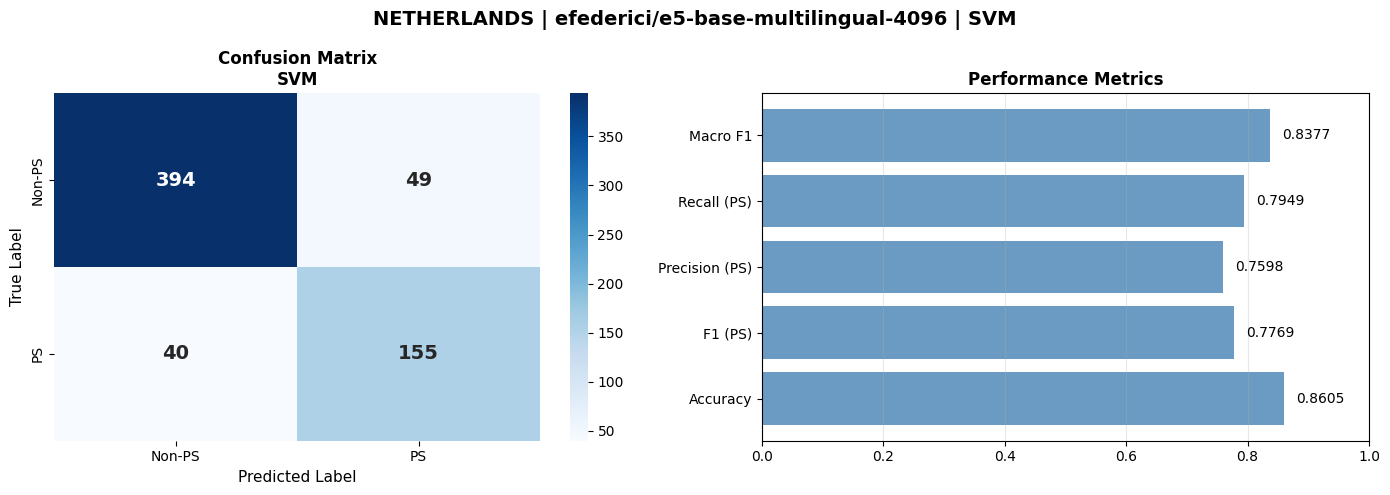


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: NETHERLANDS | efederici/e5-base-multilingual-4096 | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      410                 33
Actual: PS                           57                138
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.8779          0.8070       0.8425
Recall                     0.9255          0.7077       0.8166
F1-Score                   0.9011          0.7541       0.8276
---------------------------------------

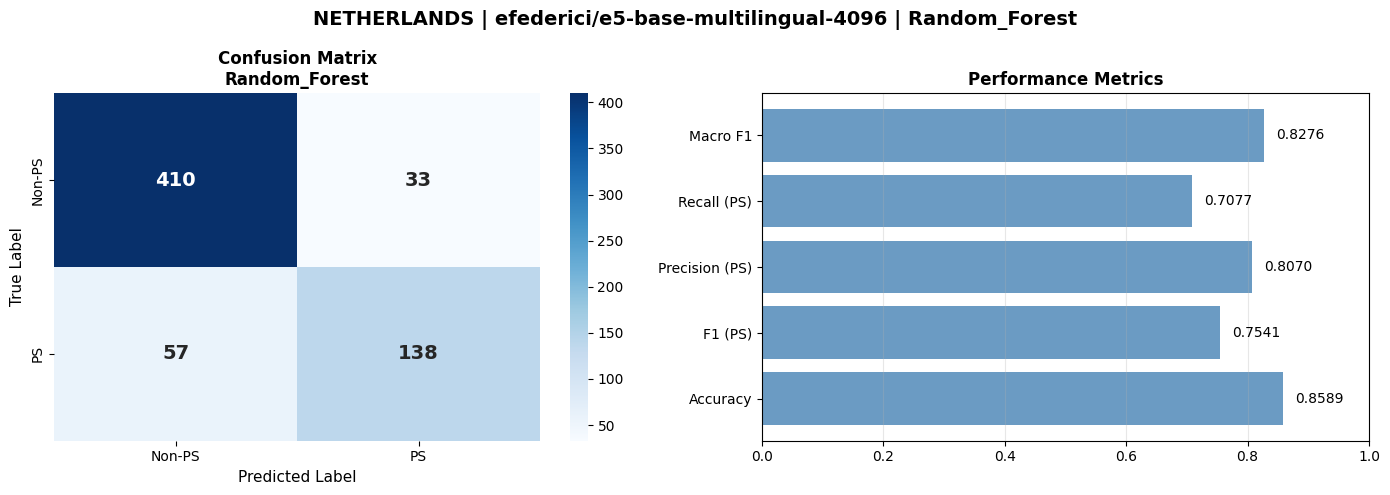


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: NETHERLANDS | efederici/e5-base-multilingual-4096 | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      393                 50
Actual: PS                           42                153
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9034          0.7537       0.8286
Recall                     0.8871          0.7846       0.8359
F1-Score                   0.8952          0.7688       0.8320
---------------------------------------------------

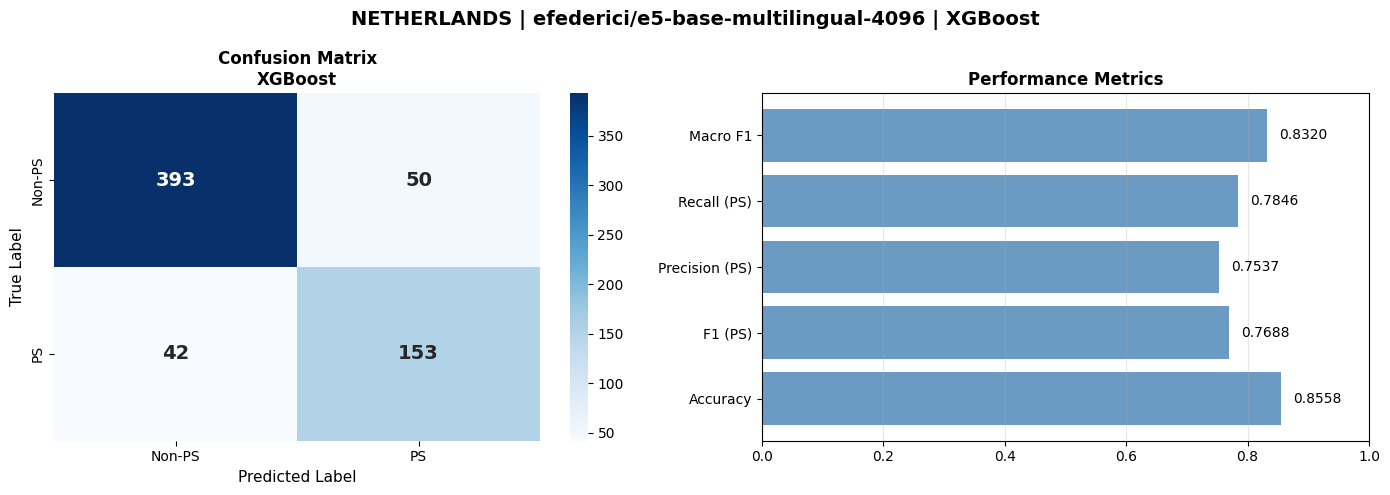


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: NETHERLANDS | efederici/e5-base-multilingual-4096 | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      401                 42
Actual: PS                           40                155
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9093          0.7868       0.8480
Recall                     0.9052          0.7949       0.8500
F1-Score                   0.9072          0.7908       0.8490
-------------------------------------------------

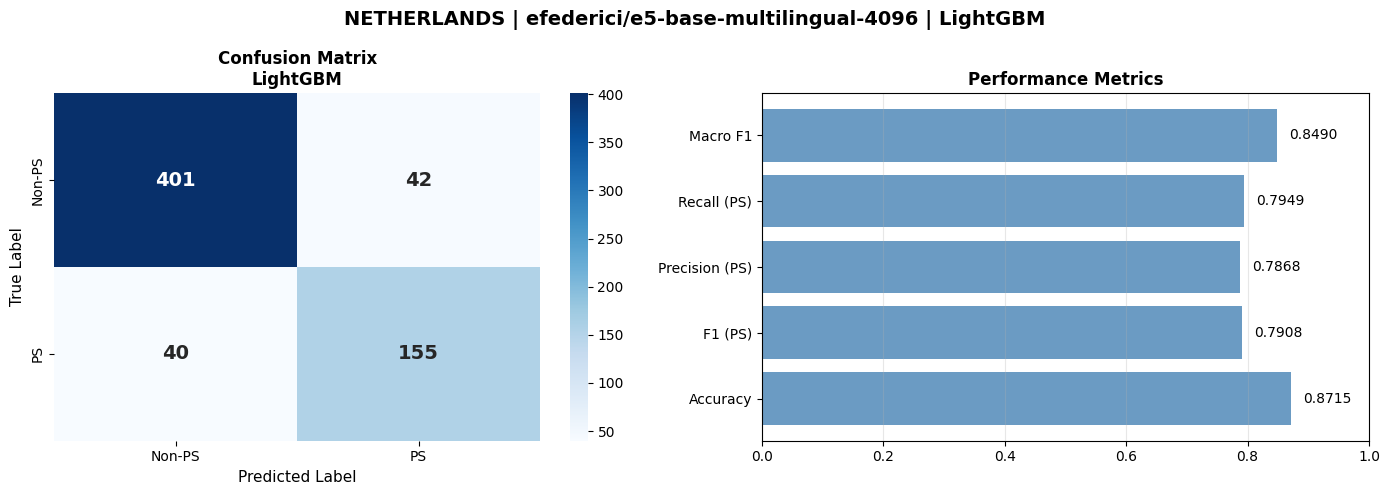


################################################################################
Loading: sweden_efederici_e5-base-multilingual-4096_embeddings.pkl
################################################################################
Dataset: SWEDEN
Model: efederici/e5-base-multilingual-4096
Training samples: 26161
Test samples: 4121
Embedding dim: 768

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: SWEDEN | efederici/e5-base-multilingual-4096 | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,224                623
Actual: PS                           72                202
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                    

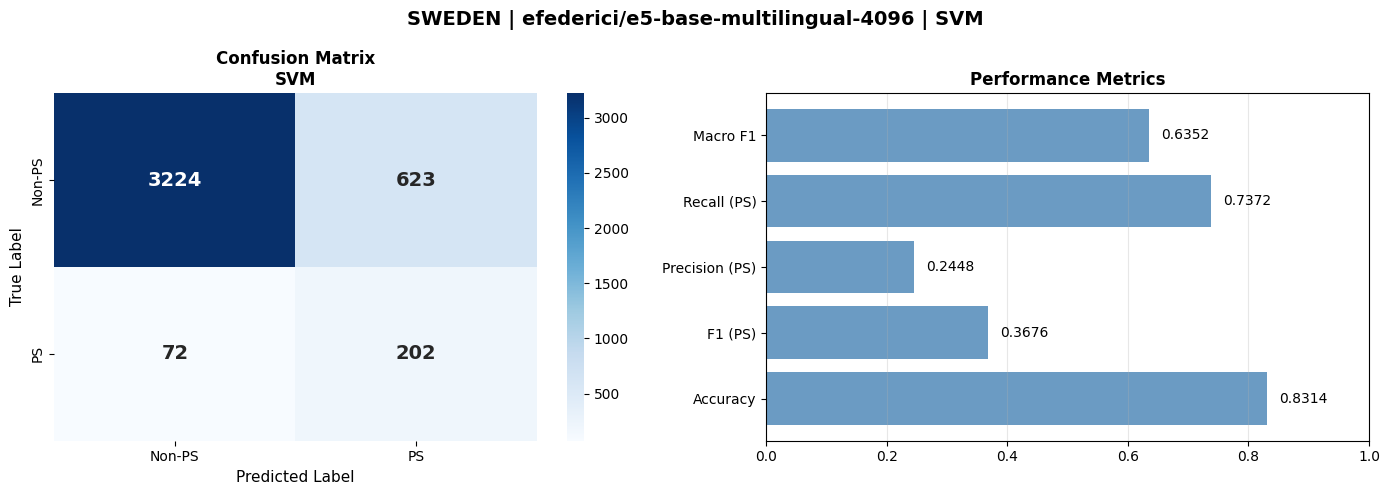


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: SWEDEN | efederici/e5-base-multilingual-4096 | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,766                 81
Actual: PS                           95                179
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9754          0.6885       0.8319
Recall                     0.9789          0.6533       0.8161
F1-Score                   0.9772          0.6704       0.8238
--------------------------------------------

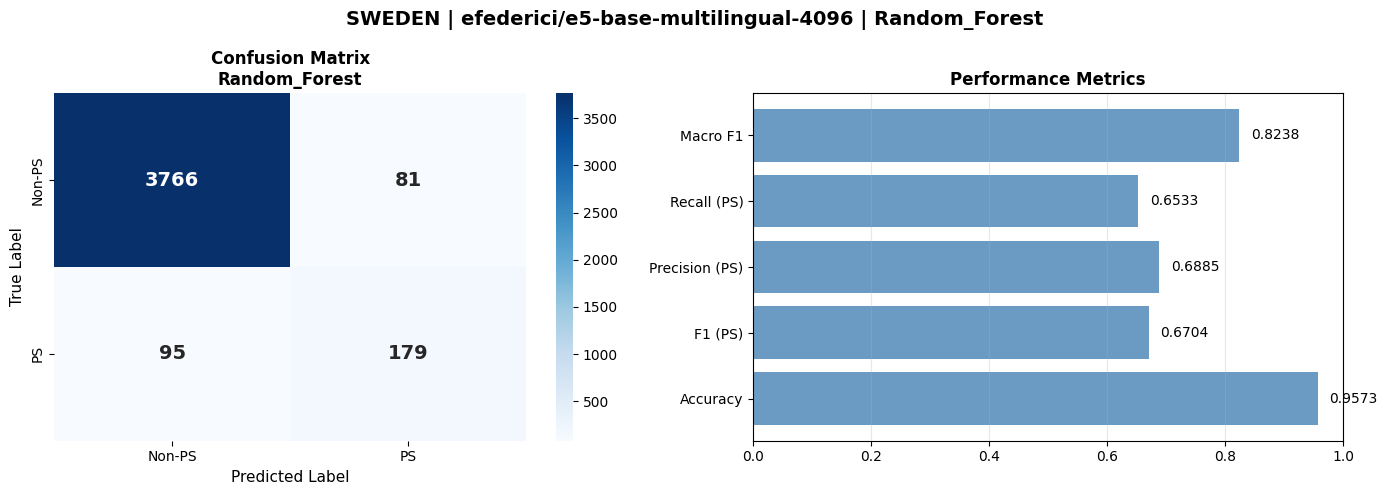


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: SWEDEN | efederici/e5-base-multilingual-4096 | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,764                 83
Actual: PS                           93                181
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9759          0.6856       0.8307
Recall                     0.9784          0.6606       0.8195
F1-Score                   0.9772          0.6729       0.8250
--------------------------------------------------------

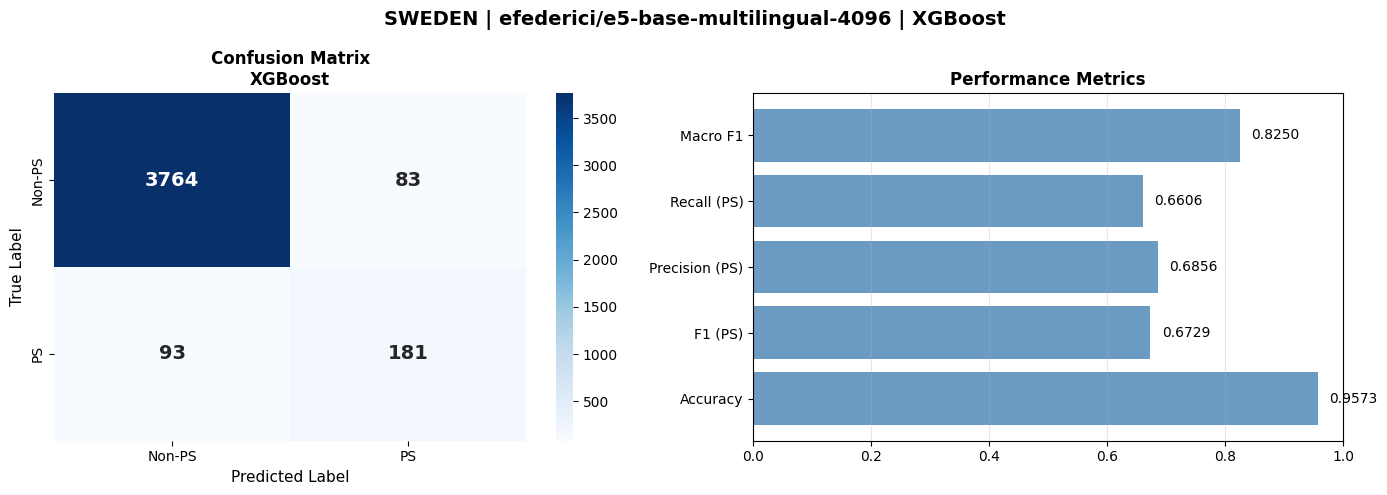


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: SWEDEN | efederici/e5-base-multilingual-4096 | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,777                 70
Actual: PS                           90                184
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9767          0.7244       0.8506
Recall                     0.9818          0.6715       0.8267
F1-Score                   0.9793          0.6970       0.8381
------------------------------------------------------

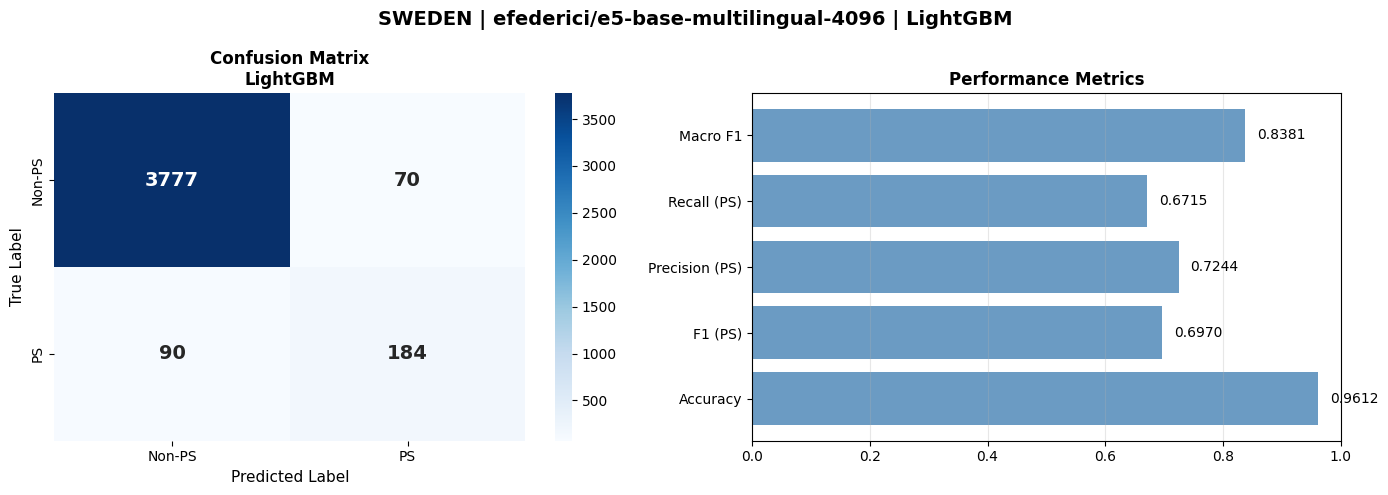


################################################################################
Loading: english_efederici_e5-base-multilingual-4096_embeddings.pkl
################################################################################
Dataset: ENGLISH
Model: efederici/e5-base-multilingual-4096
Training samples: 6621
Test samples: 1422
Embedding dim: 768

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: ENGLISH | efederici/e5-base-multilingual-4096 | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      816                159
Actual: PS                          102                345
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                  

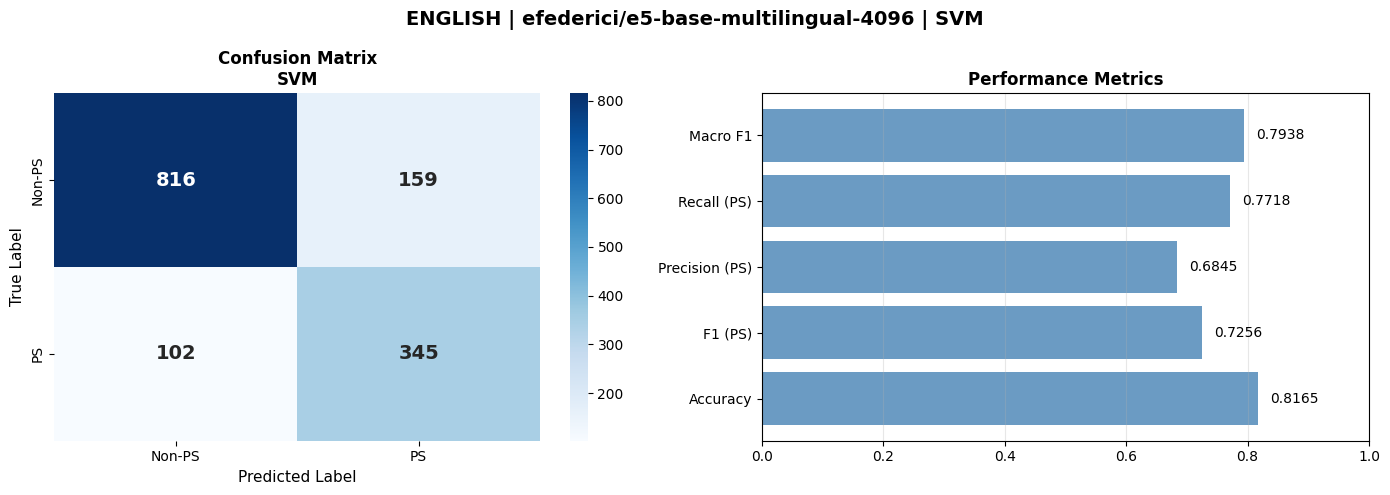


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: ENGLISH | efederici/e5-base-multilingual-4096 | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      929                 46
Actual: PS                          103                344
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9002          0.8821       0.8911
Recall                     0.9528          0.7696       0.8612
F1-Score                   0.9258          0.8220       0.8739
-------------------------------------------

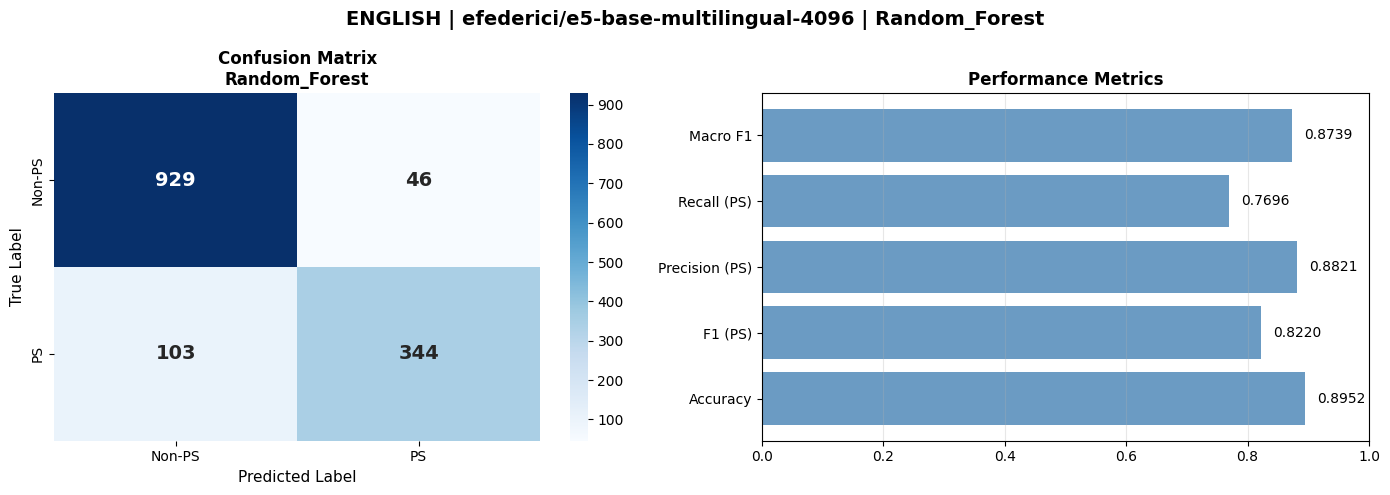


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: ENGLISH | efederici/e5-base-multilingual-4096 | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      919                 56
Actual: PS                           86                361
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9144          0.8657       0.8901
Recall                     0.9426          0.8076       0.8751
F1-Score                   0.9283          0.8356       0.8820
-------------------------------------------------------

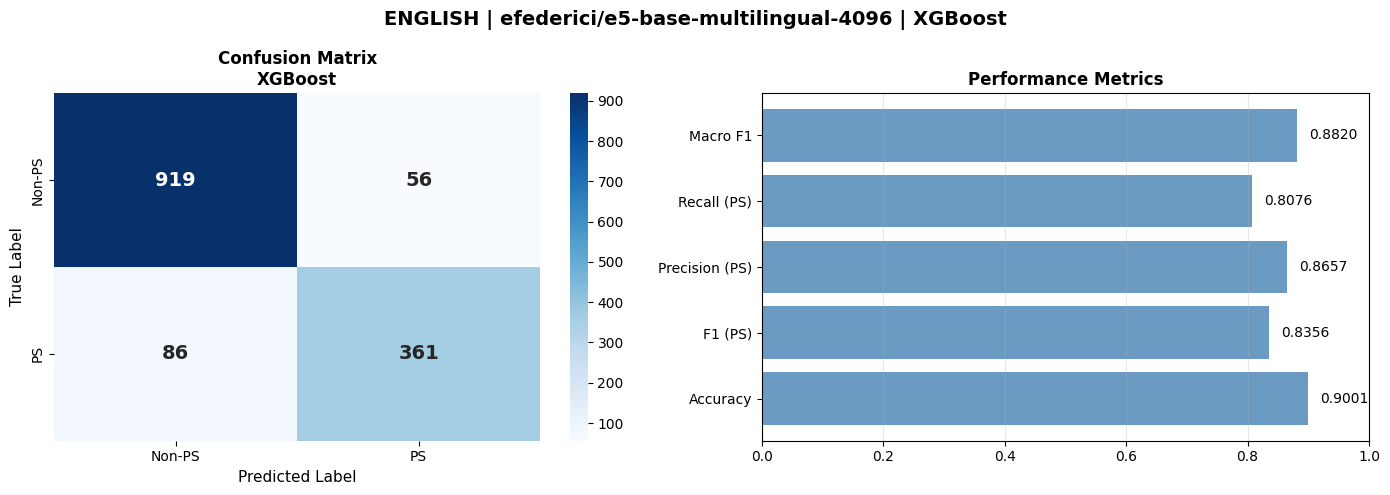


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: ENGLISH | efederici/e5-base-multilingual-4096 | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      920                 55
Actual: PS                           83                364
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9172          0.8687       0.8930
Recall                     0.9436          0.8143       0.8790
F1-Score                   0.9302          0.8406       0.8854
-----------------------------------------------------

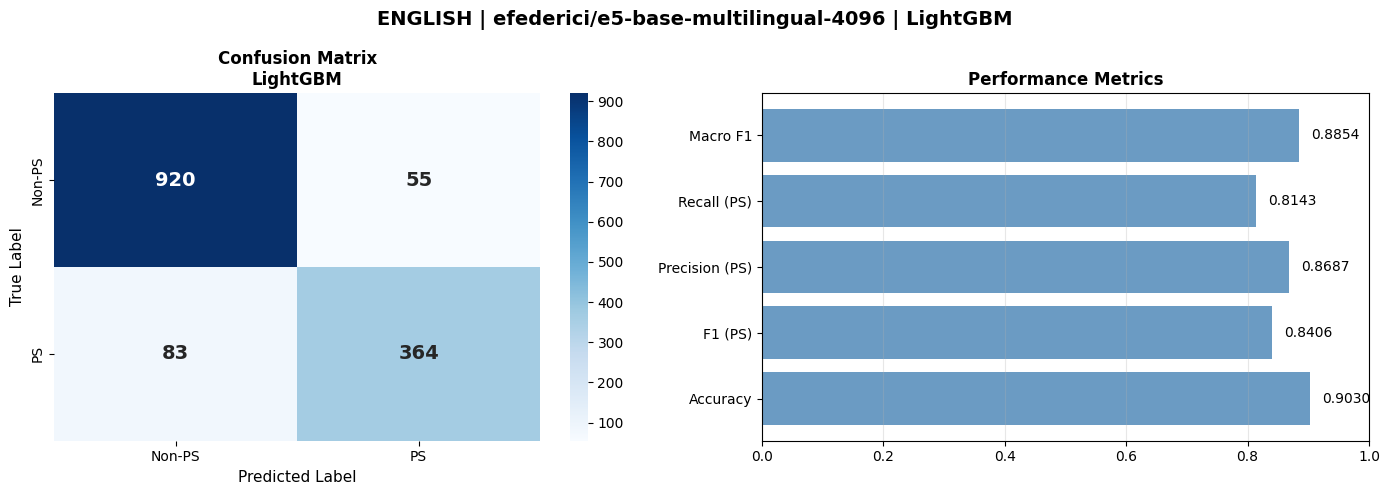


################################################################################
Loading: uk_efederici_e5-base-multilingual-4096_embeddings.pkl
################################################################################
Dataset: UK
Model: efederici/e5-base-multilingual-4096
Training samples: 6582
Test samples: 1407
Embedding dim: 768

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: UK | efederici/e5-base-multilingual-4096 | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      788                181
Actual: PS                           95                343
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Proc

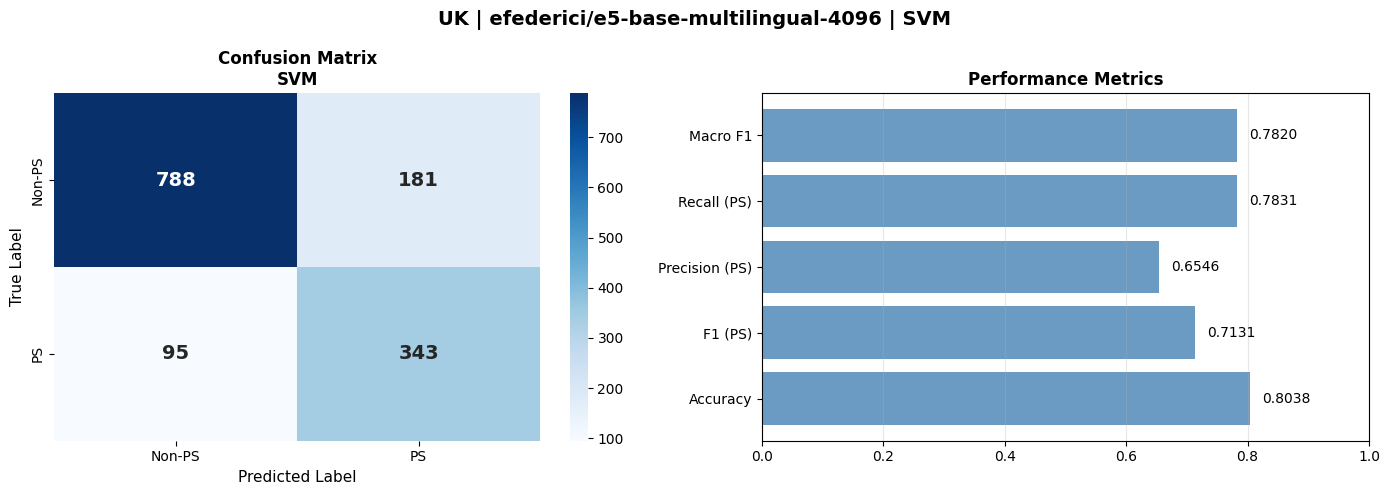


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: UK | efederici/e5-base-multilingual-4096 | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      904                 65
Actual: PS                           99                339
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9013          0.8391       0.8702
Recall                     0.9329          0.7740       0.8534
F1-Score                   0.9168          0.8052       0.8610
------------------------------------------------

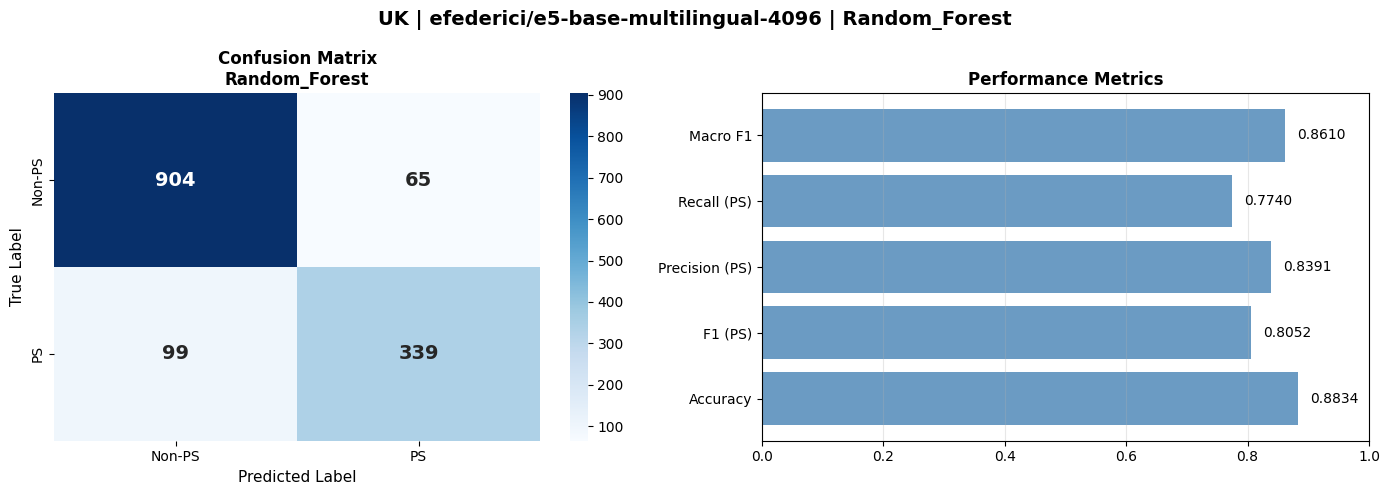


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: UK | efederici/e5-base-multilingual-4096 | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      898                 71
Actual: PS                           74                364
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9239          0.8368       0.8803
Recall                     0.9267          0.8311       0.8789
F1-Score                   0.9253          0.8339       0.8796
------------------------------------------------------------

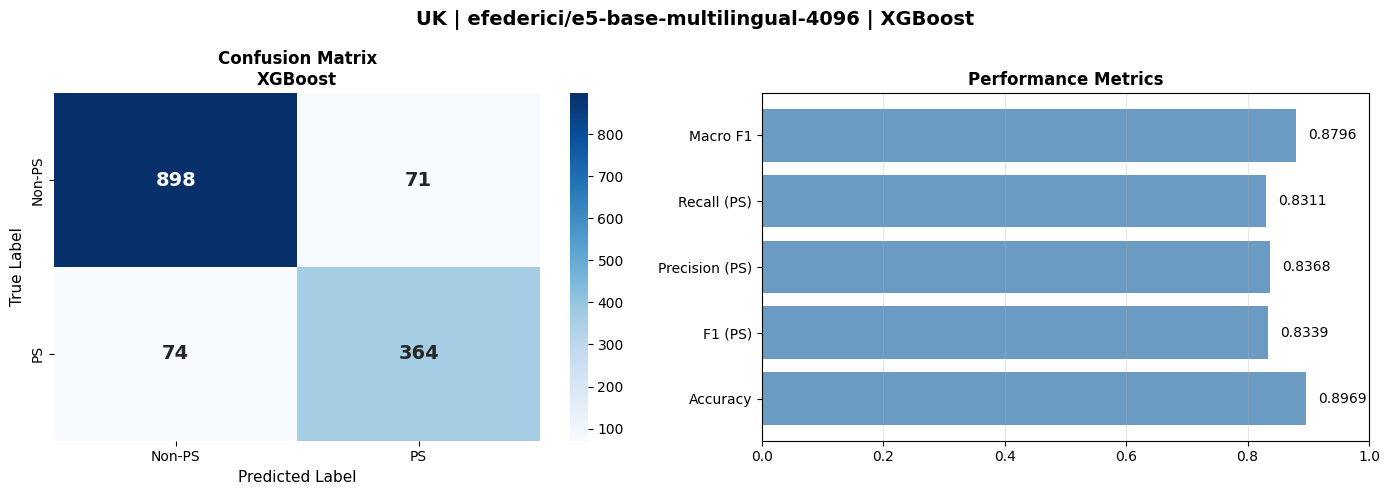


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: UK | efederici/e5-base-multilingual-4096 | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      896                 73
Actual: PS                           82                356
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9162          0.8298       0.8730
Recall                     0.9247          0.8128       0.8687
F1-Score                   0.9204          0.8212       0.8708
----------------------------------------------------------

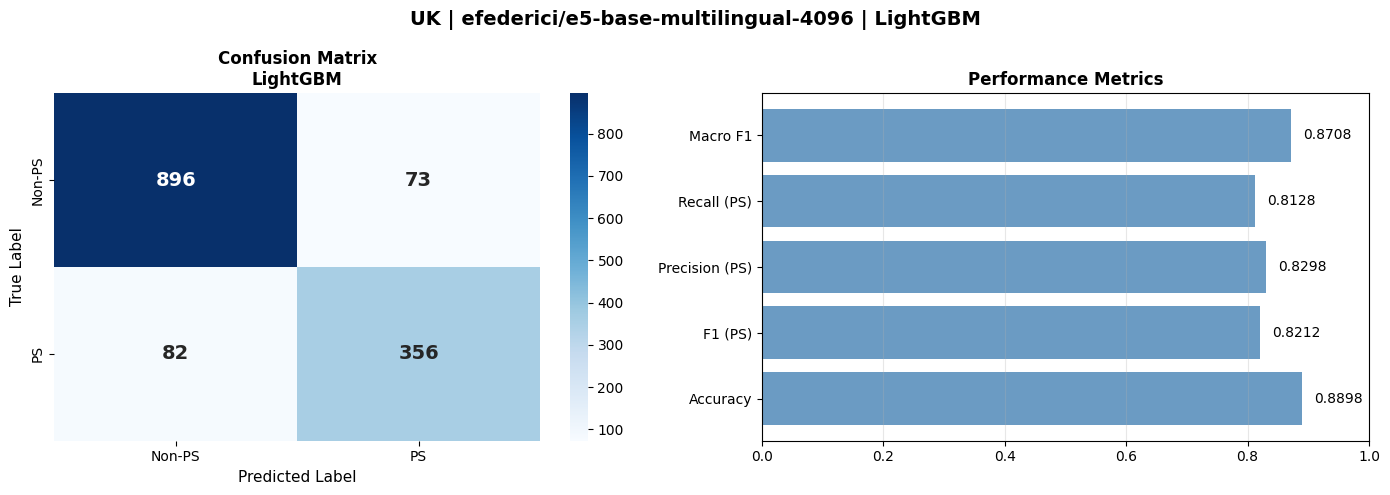


################################################################################
Loading: germany_efederici_e5-base-multilingual-4096_embeddings.pkl
################################################################################
Dataset: GERMANY
Model: efederici/e5-base-multilingual-4096
Training samples: 27356
Test samples: 4568
Embedding dim: 768

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: GERMANY | efederici/e5-base-multilingual-4096 | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,347                676
Actual: PS                          138                407
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                 

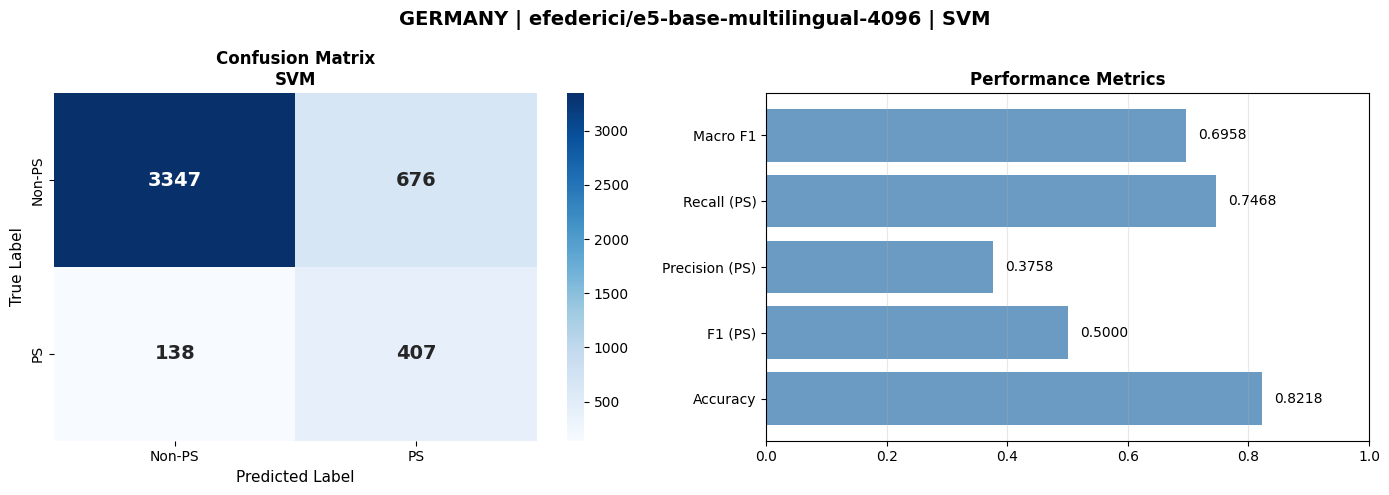


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: GERMANY | efederici/e5-base-multilingual-4096 | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,961                 62
Actual: PS                          131                414
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9680          0.8697       0.9189
Recall                     0.9846          0.7596       0.8721
F1-Score                   0.9762          0.8110       0.8936
-------------------------------------------

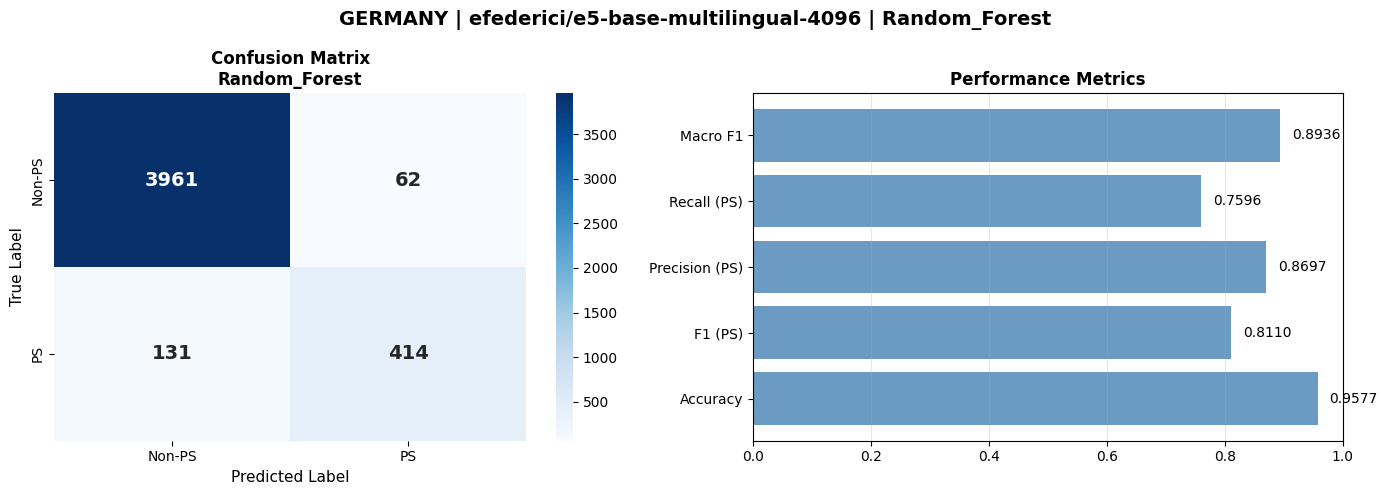


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: GERMANY | efederici/e5-base-multilingual-4096 | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,916                107
Actual: PS                          108                437
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9732          0.8033       0.8882
Recall                     0.9734          0.8018       0.8876
F1-Score                   0.9733          0.8026       0.8879
-------------------------------------------------------

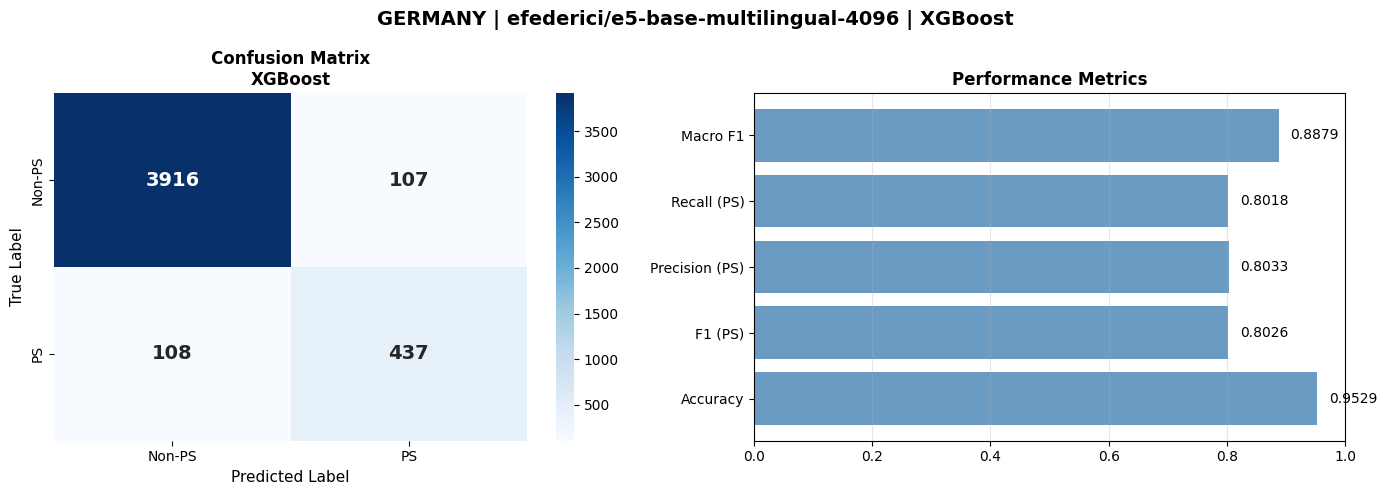


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: GERMANY | efederici/e5-base-multilingual-4096 | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,915                108
Actual: PS                          111                434
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9724          0.8007       0.8866
Recall                     0.9732          0.7963       0.8847
F1-Score                   0.9728          0.7985       0.8857
-----------------------------------------------------

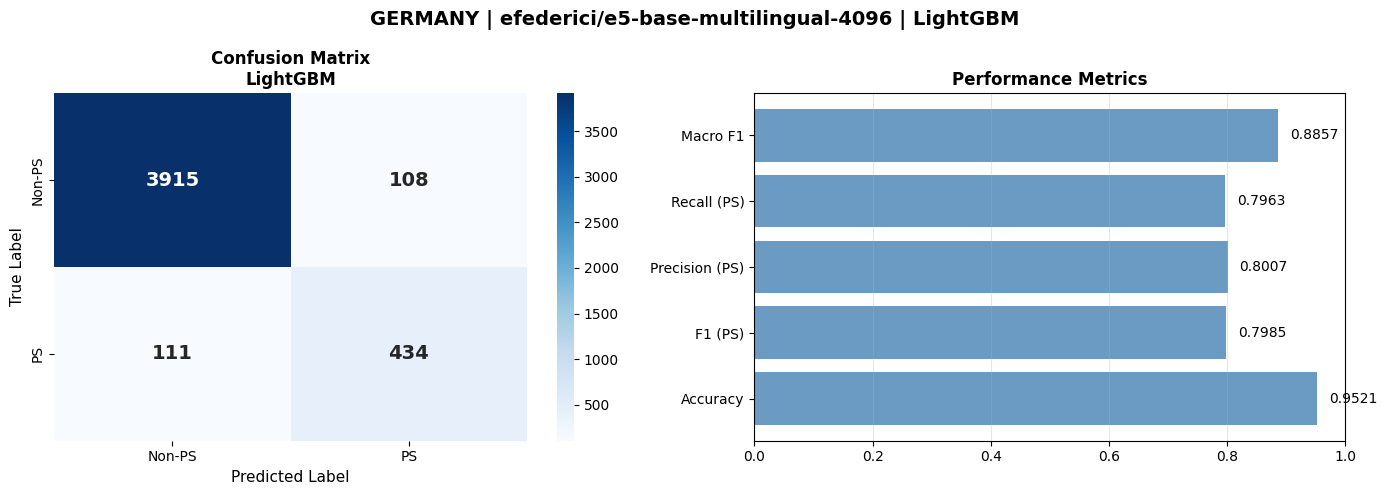


################################################################################
Loading: uk_snowflake-arctic-embed-l-v2.0_embeddings.pkl
################################################################################
Dataset: UK
Model: snowflake-arctic-embed-l-v2.0
Training samples: 6582
Test samples: 1407
Embedding dim: 1024

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: UK | snowflake-arctic-embed-l-v2.0 | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      800                169
Actual: PS                           92                346
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Mac

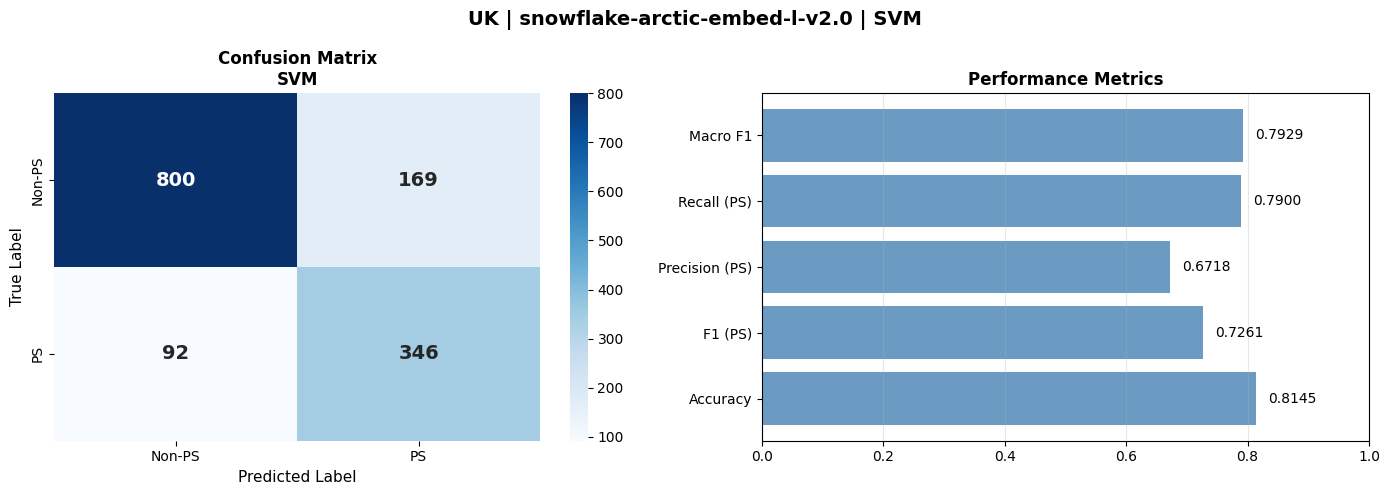


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: UK | snowflake-arctic-embed-l-v2.0 | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      922                 47
Actual: PS                           94                344
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9075          0.8798       0.8936
Recall                     0.9515          0.7854       0.8684
F1-Score                   0.9290          0.8299       0.8794
------------------------------------------------------

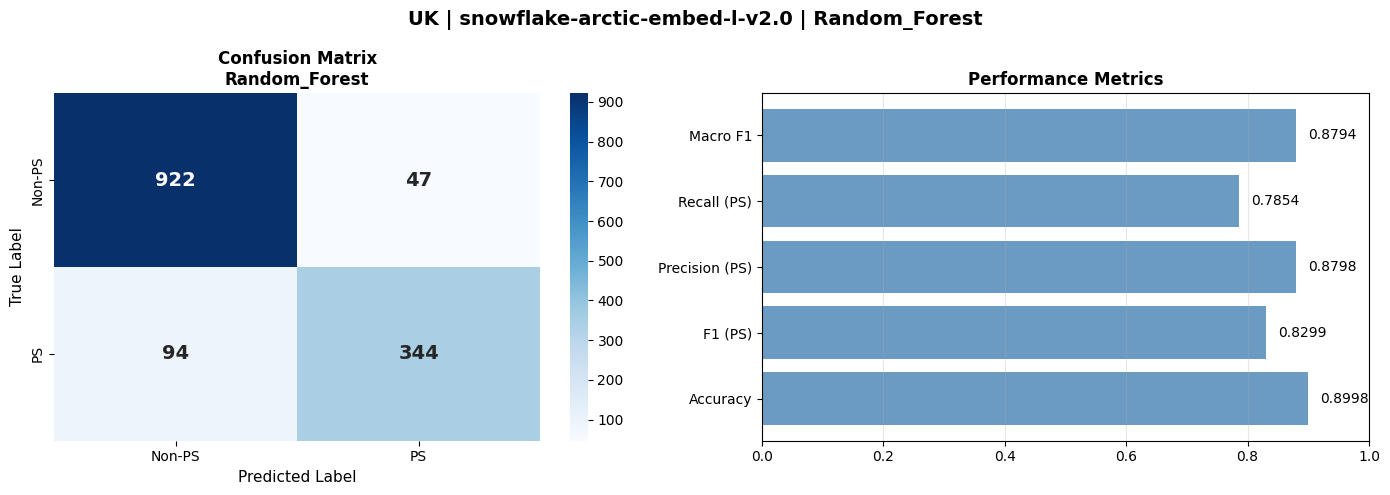


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: UK | snowflake-arctic-embed-l-v2.0 | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      911                 58
Actual: PS                           77                361
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9221          0.8616       0.8918
Recall                     0.9401          0.8242       0.8822
F1-Score                   0.9310          0.8425       0.8867
------------------------------------------------------------
Accur

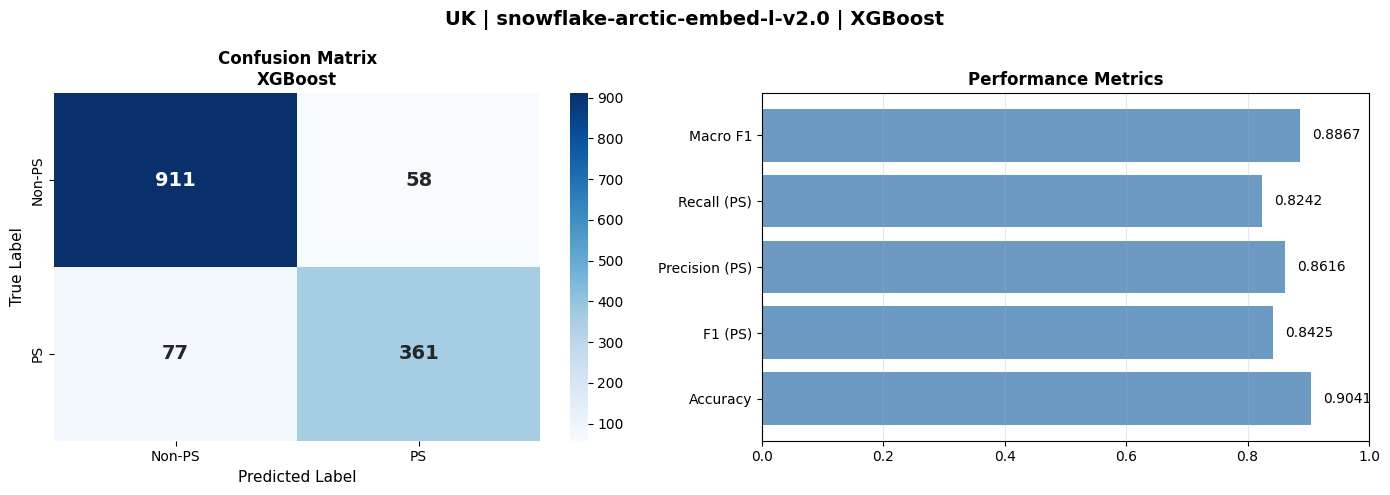


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: UK | snowflake-arctic-embed-l-v2.0 | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      908                 61
Actual: PS                           81                357
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9181          0.8541       0.8861
Recall                     0.9370          0.8151       0.8761
F1-Score                   0.9275          0.8341       0.8808
------------------------------------------------------------
Acc

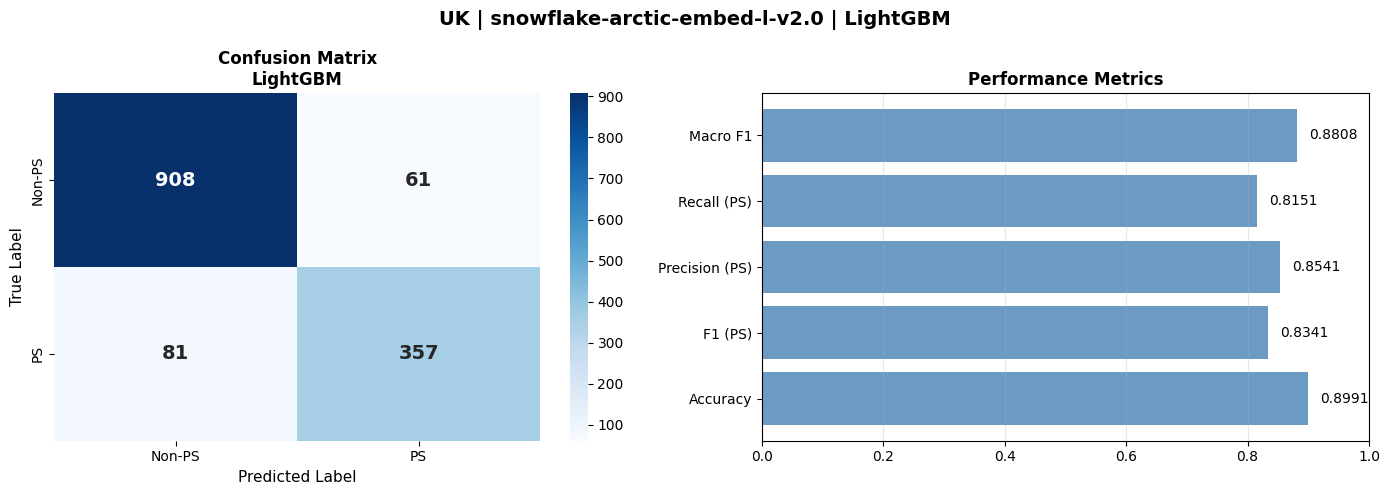


################################################################################
Loading: sweden_snowflake-arctic-embed-l-v2.0_embeddings.pkl
################################################################################
Dataset: SWEDEN
Model: snowflake-arctic-embed-l-v2.0
Training samples: 26161
Test samples: 4121
Embedding dim: 1024

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: SWEDEN | snowflake-arctic-embed-l-v2.0 | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,307                540
Actual: PS                           78                196
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process 

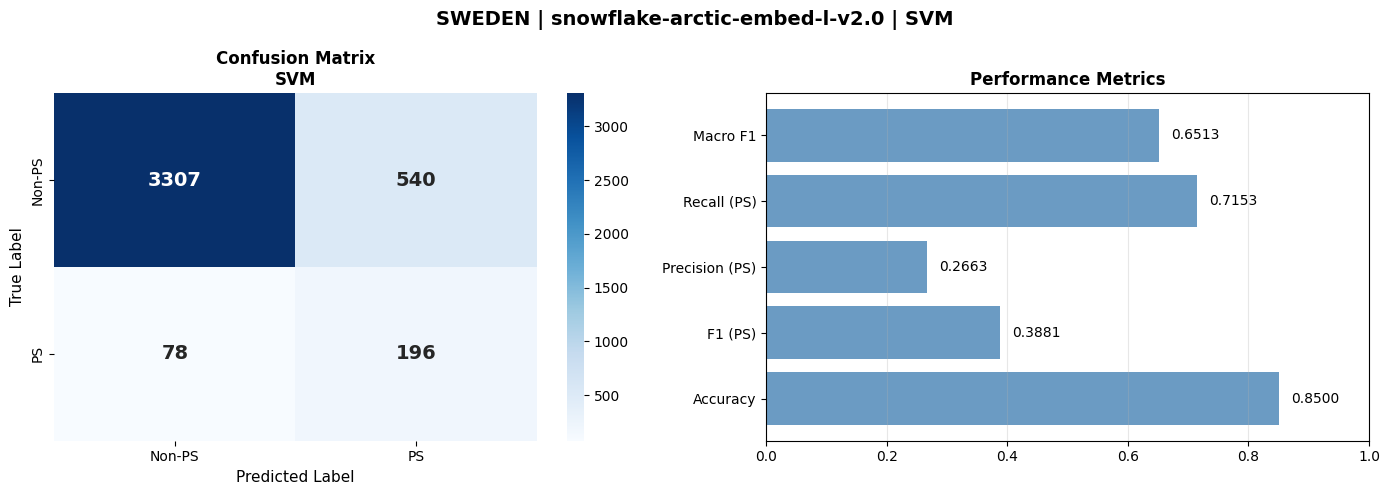


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: SWEDEN | snowflake-arctic-embed-l-v2.0 | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,746                101
Actual: PS                           85                189
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9778          0.6517       0.8148
Recall                     0.9737          0.6898       0.8318
F1-Score                   0.9758          0.6702       0.8230
--------------------------------------------------

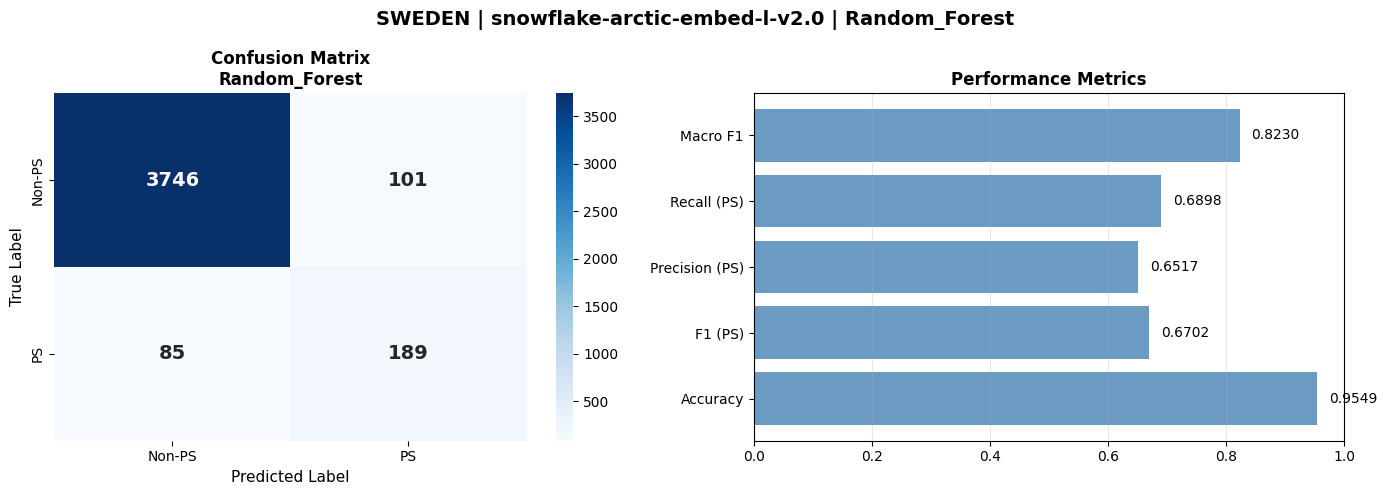


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: SWEDEN | snowflake-arctic-embed-l-v2.0 | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,763                 84
Actual: PS                           86                188
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9777          0.6912       0.8344
Recall                     0.9782          0.6861       0.8321
F1-Score                   0.9779          0.6886       0.8333
------------------------------------------------------------
A

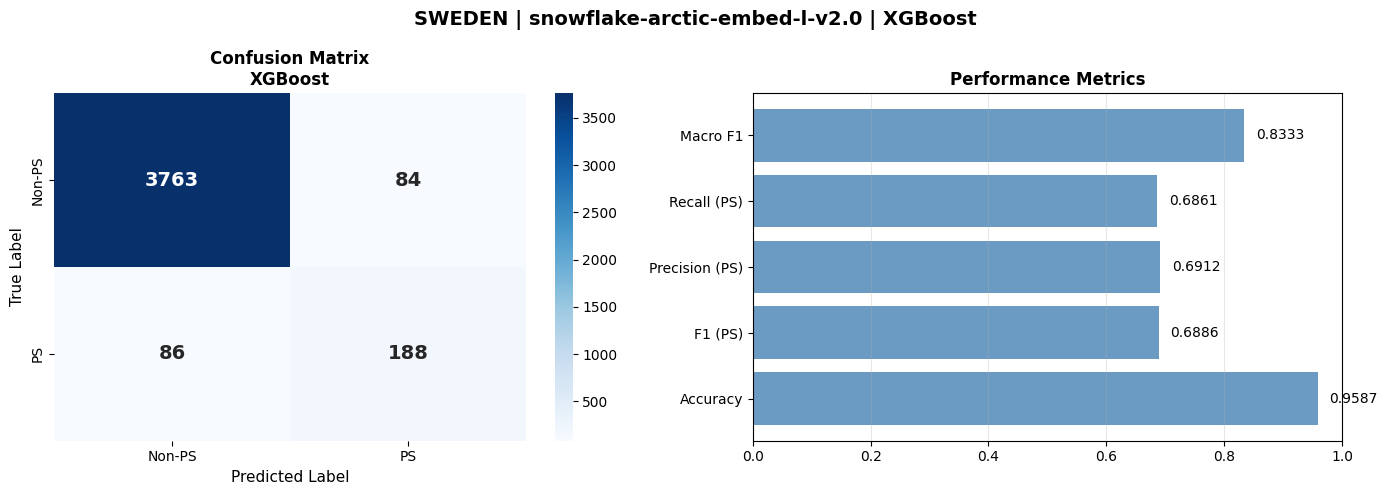


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: SWEDEN | snowflake-arctic-embed-l-v2.0 | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,767                 80
Actual: PS                           83                191
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9784          0.7048       0.8416
Recall                     0.9792          0.6971       0.8381
F1-Score                   0.9788          0.7009       0.8399
------------------------------------------------------------

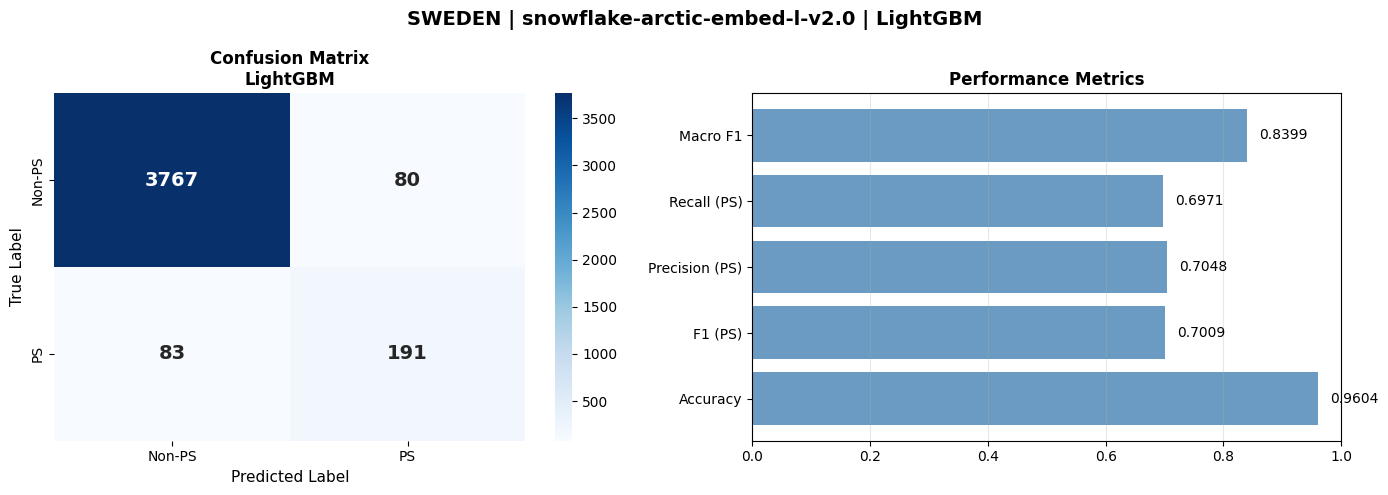


################################################################################
Loading: germany_snowflake-arctic-embed-l-v2.0_embeddings.pkl
################################################################################
Dataset: GERMANY
Model: snowflake-arctic-embed-l-v2.0
Training samples: 27356
Test samples: 4568
Embedding dim: 1024

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: GERMANY | snowflake-arctic-embed-l-v2.0 | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,452                571
Actual: PS                          155                390
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Proce

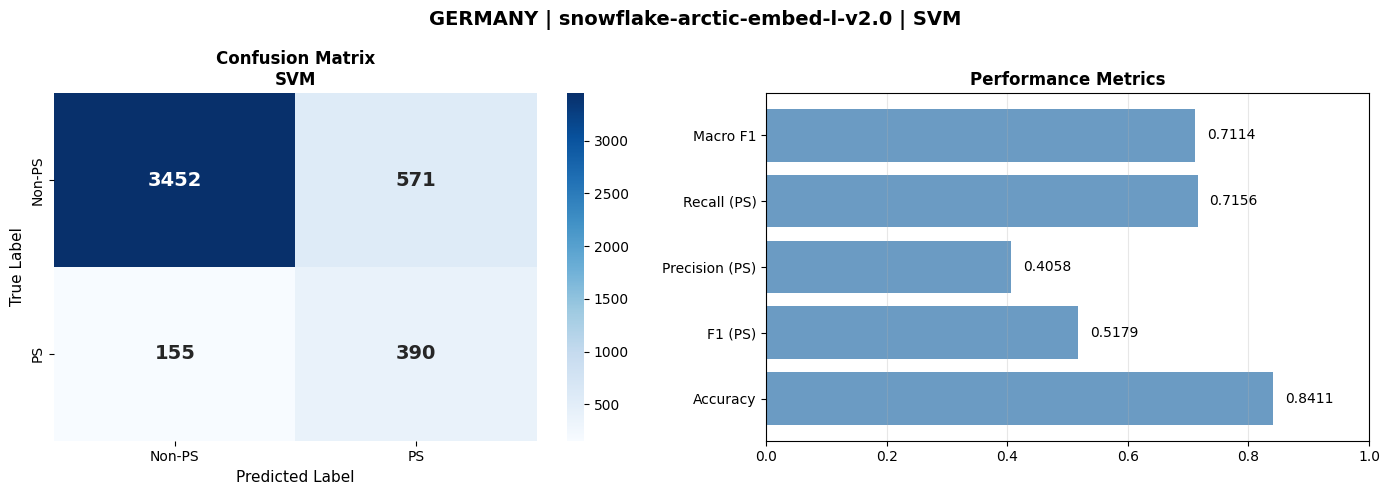


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: GERMANY | snowflake-arctic-embed-l-v2.0 | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,975                 48
Actual: PS                          139                406
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9662          0.8943       0.9302
Recall                     0.9881          0.7450       0.8665
F1-Score                   0.9770          0.8128       0.8949
-------------------------------------------------

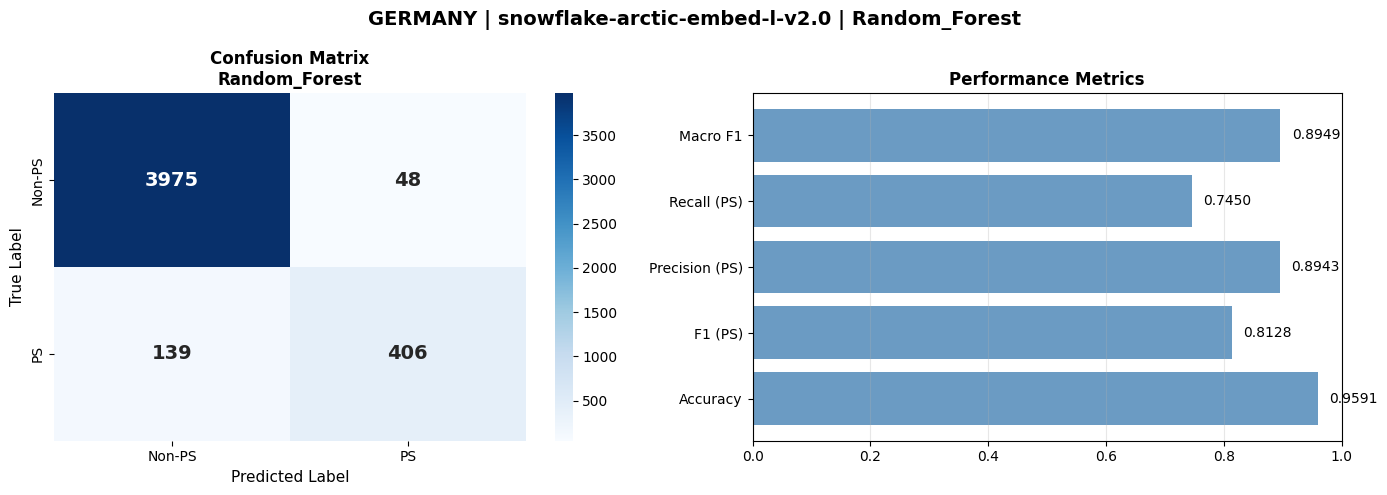


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: GERMANY | snowflake-arctic-embed-l-v2.0 | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,948                 75
Actual: PS                          111                434
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9727          0.8527       0.9127
Recall                     0.9814          0.7963       0.8888
F1-Score                   0.9770          0.8235       0.9003
------------------------------------------------------------


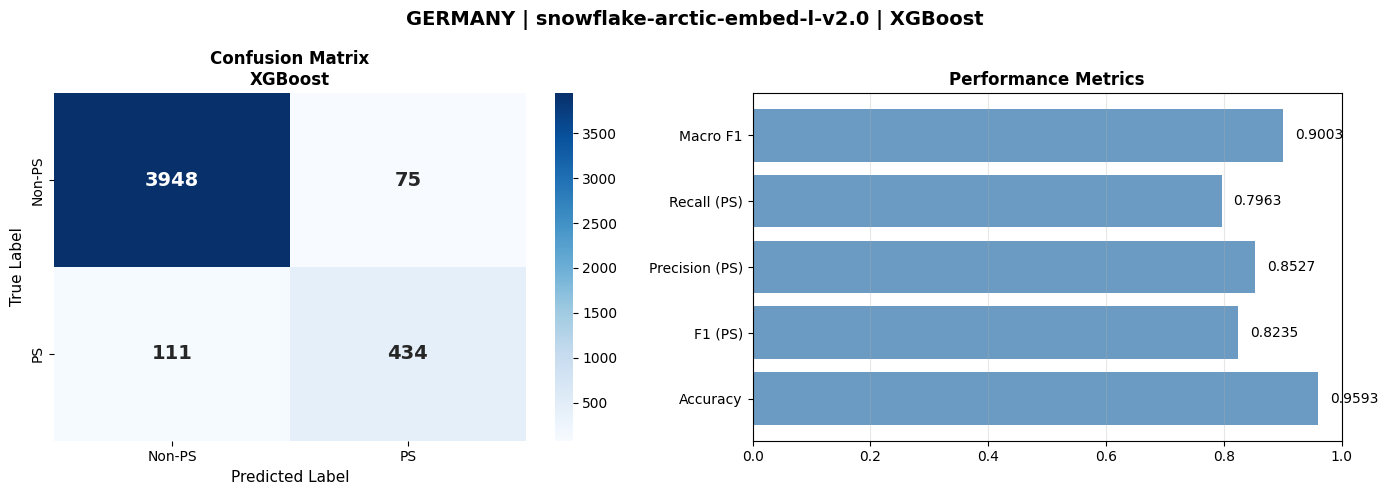


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: GERMANY | snowflake-arctic-embed-l-v2.0 | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,941                 82
Actual: PS                          109                436
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9731          0.8417       0.9074
Recall                     0.9796          0.8000       0.8898
F1-Score                   0.9763          0.8203       0.8983
-----------------------------------------------------------

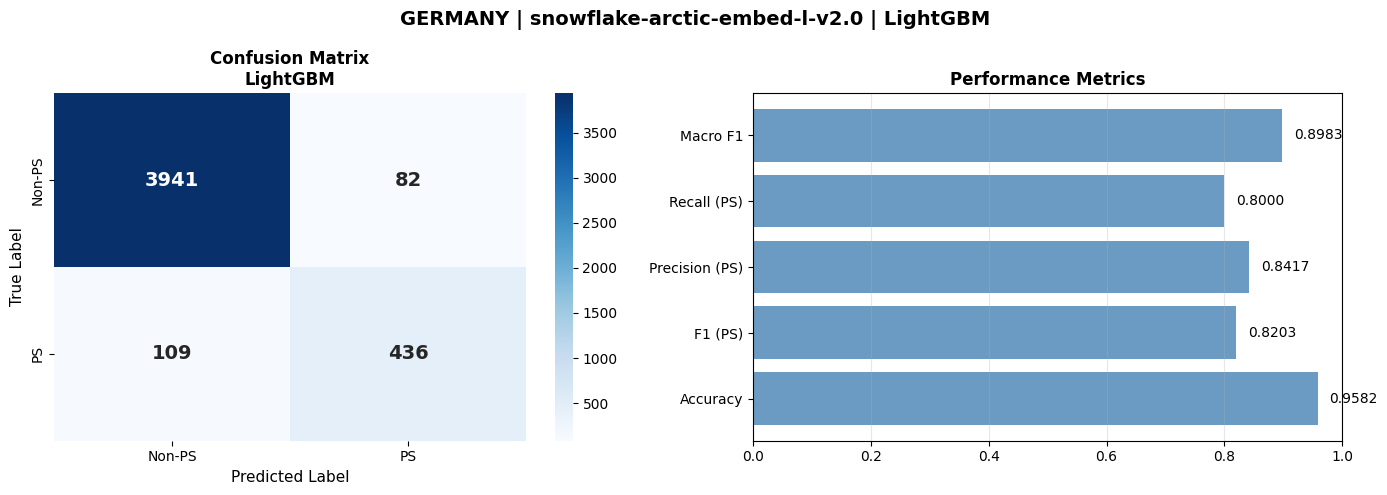


################################################################################
Loading: english_snowflake-arctic-embed-l-v2.0_embeddings.pkl
################################################################################
Dataset: ENGLISH
Model: snowflake-arctic-embed-l-v2.0
Training samples: 6621
Test samples: 1422
Embedding dim: 1024

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: ENGLISH | snowflake-arctic-embed-l-v2.0 | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      831                144
Actual: PS                           96                351
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Proces

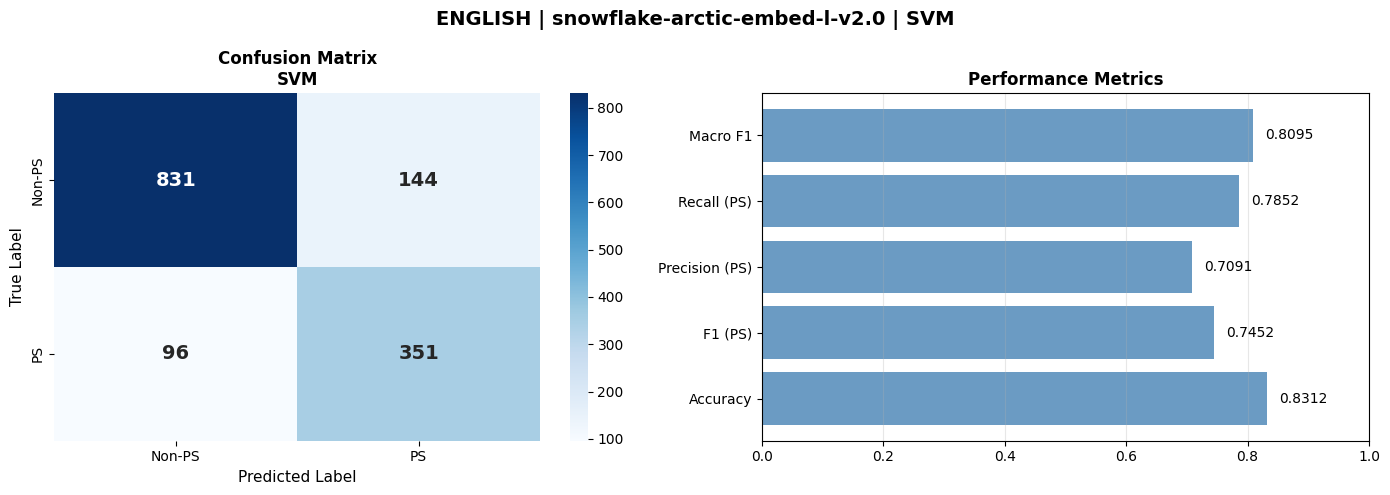


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: ENGLISH | snowflake-arctic-embed-l-v2.0 | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      940                 35
Actual: PS                          106                341
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.8987          0.9069       0.9028
Recall                     0.9641          0.7629       0.8635
F1-Score                   0.9302          0.8287       0.8795
-------------------------------------------------

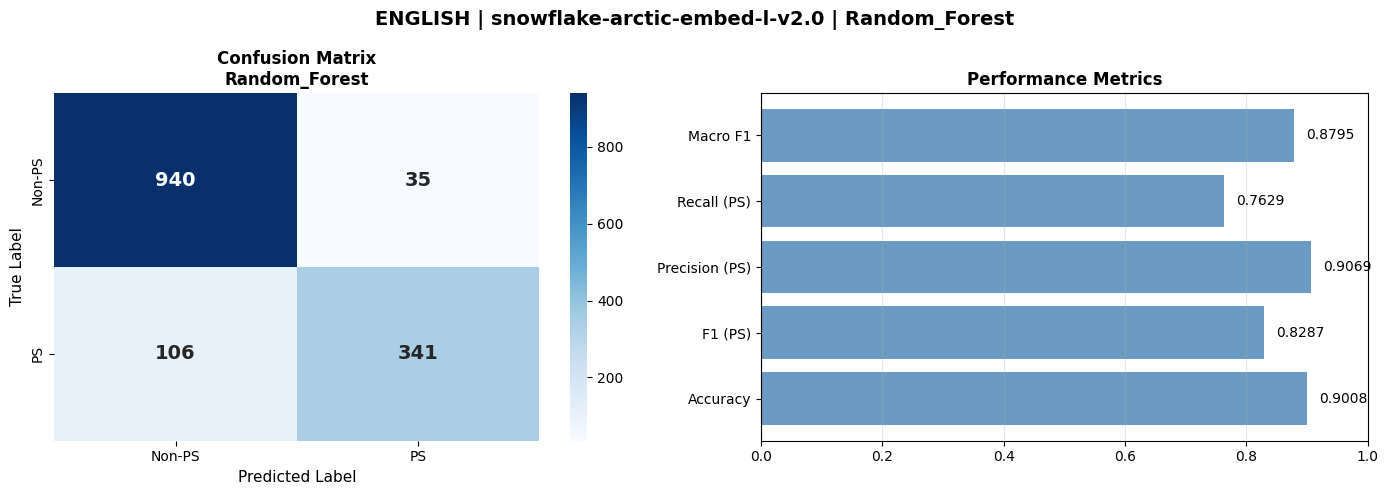


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: ENGLISH | snowflake-arctic-embed-l-v2.0 | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      925                 50
Actual: PS                           80                367
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9204          0.8801       0.9002
Recall                     0.9487          0.8210       0.8849
F1-Score                   0.9343          0.8495       0.8919
------------------------------------------------------------


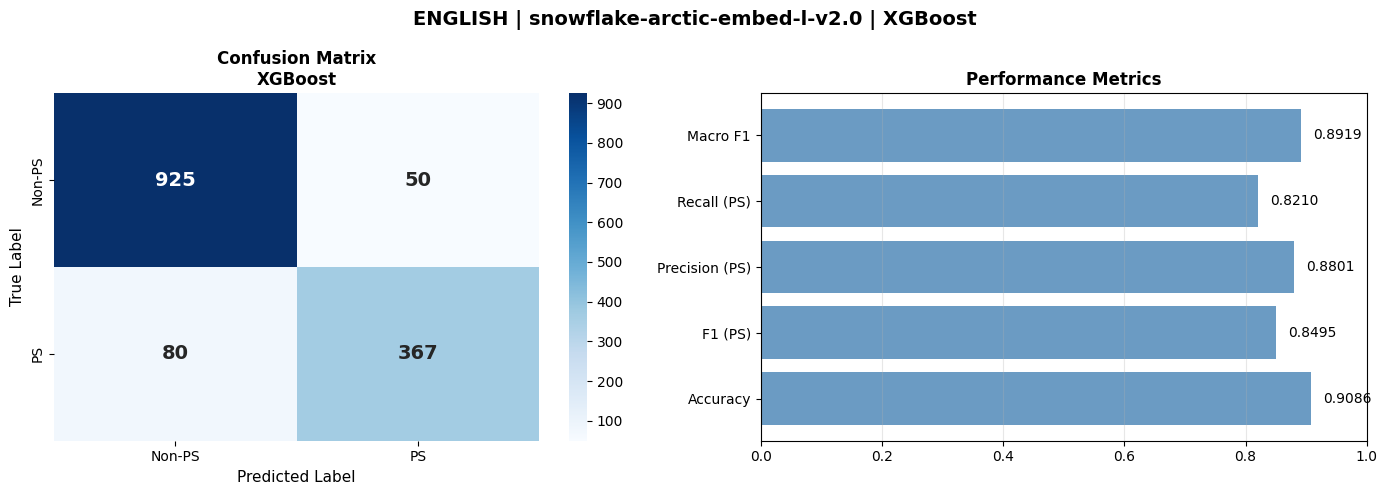


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: ENGLISH | snowflake-arctic-embed-l-v2.0 | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      924                 51
Actual: PS                           80                367
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9203          0.8780       0.8992
Recall                     0.9477          0.8210       0.8844
F1-Score                   0.9338          0.8486       0.8912
-----------------------------------------------------------

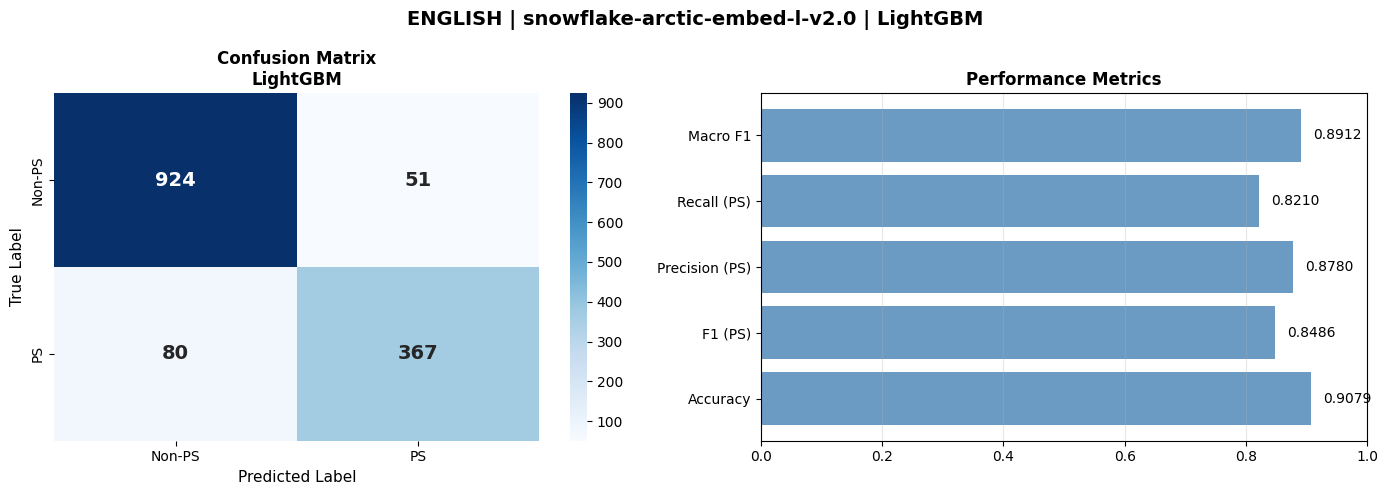


################################################################################
Loading: netherlands_snowflake-arctic-embed-l-v2.0_embeddings.pkl
################################################################################
Dataset: NETHERLANDS
Model: snowflake-arctic-embed-l-v2.0
Training samples: 3005
Test samples: 638
Embedding dim: 1024

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: NETHERLANDS | snowflake-arctic-embed-l-v2.0 | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      397                 46
Actual: PS                           38                157
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non

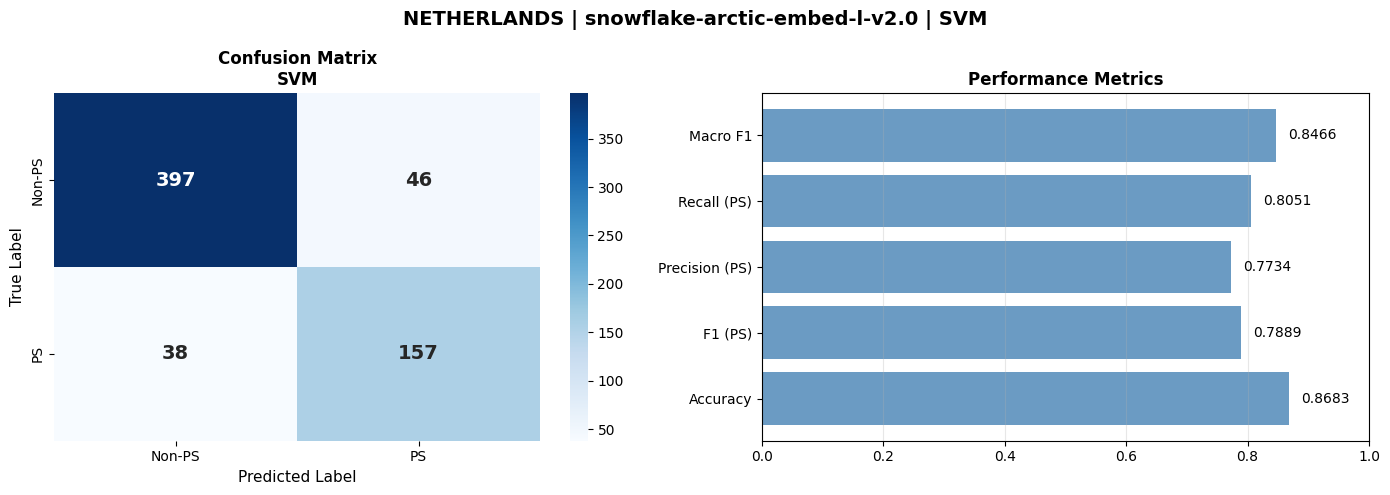


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: NETHERLANDS | snowflake-arctic-embed-l-v2.0 | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      417                 26
Actual: PS                           62                133
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.8706          0.8365       0.8535
Recall                     0.9413          0.6821       0.8117
F1-Score                   0.9046          0.7514       0.8280
---------------------------------------------

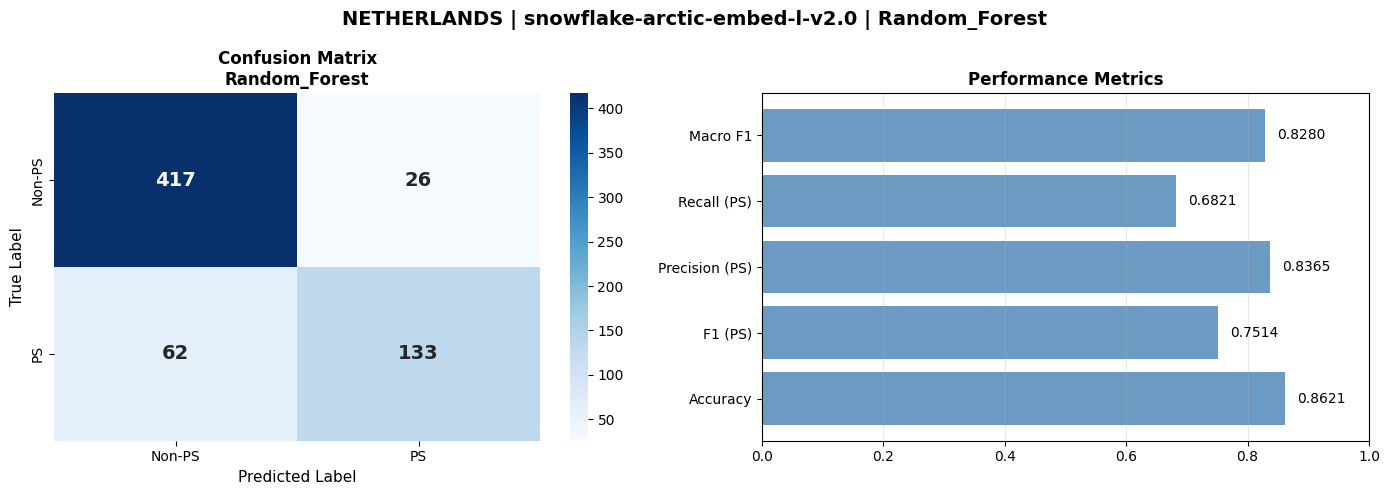


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: NETHERLANDS | snowflake-arctic-embed-l-v2.0 | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      397                 46
Actual: PS                           43                152
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9023          0.7677       0.8350
Recall                     0.8962          0.7795       0.8378
F1-Score                   0.8992          0.7735       0.8364
---------------------------------------------------------

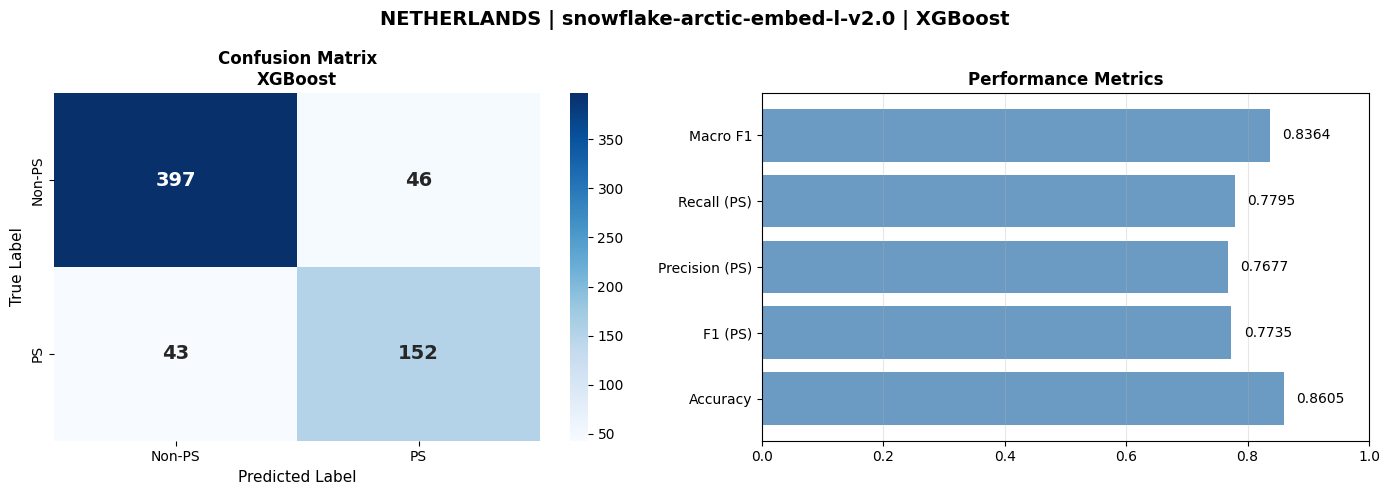


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: NETHERLANDS | snowflake-arctic-embed-l-v2.0 | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      403                 40
Actual: PS                           48                147
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.8936          0.7861       0.8398
Recall                     0.9097          0.7538       0.8318
F1-Score                   0.9016          0.7696       0.8356
-------------------------------------------------------

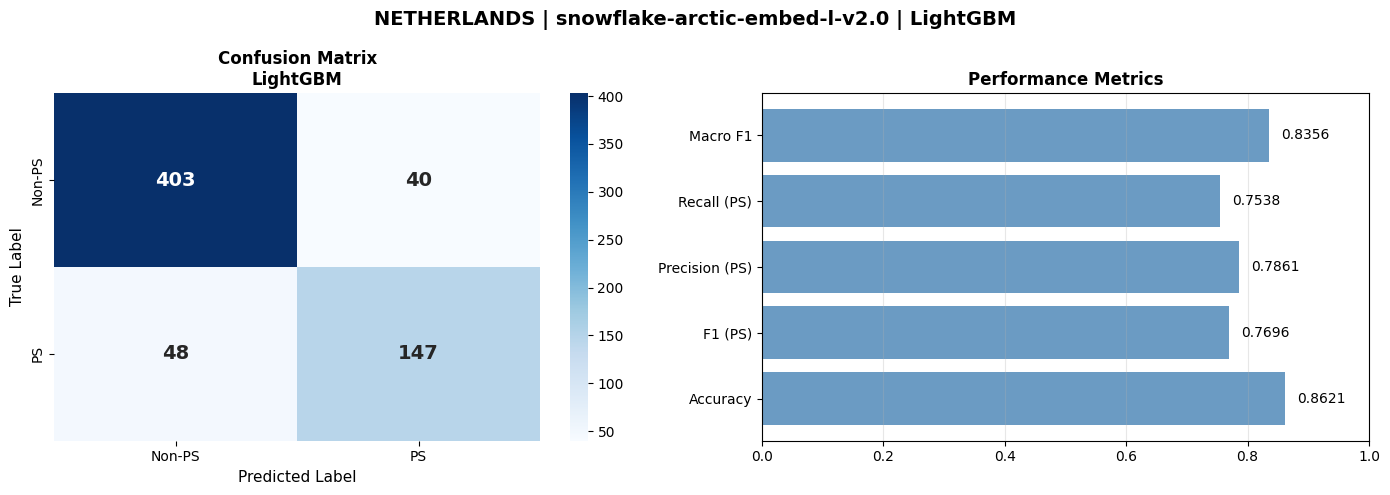


################################################################################
Loading: sweden_bert-base-multilingual-uncased_embeddings.pkl
################################################################################
Dataset: SWEDEN
Model: bert-base-multilingual-uncased
Training samples: 26161
Test samples: 4121
Embedding dim: 768

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: SWEDEN | bert-base-multilingual-uncased | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,213                634
Actual: PS                           79                195
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Proces

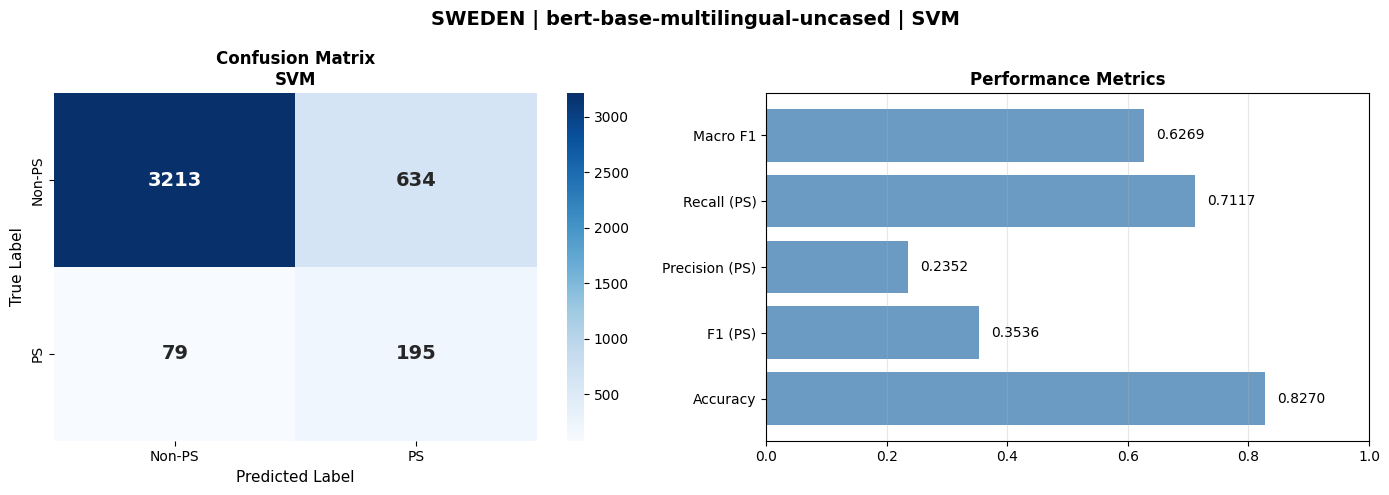


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: SWEDEN | bert-base-multilingual-uncased | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,772                 75
Actual: PS                          105                169
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9729          0.6926       0.8328
Recall                     0.9805          0.6168       0.7986
F1-Score                   0.9767          0.6525       0.8146
-------------------------------------------------

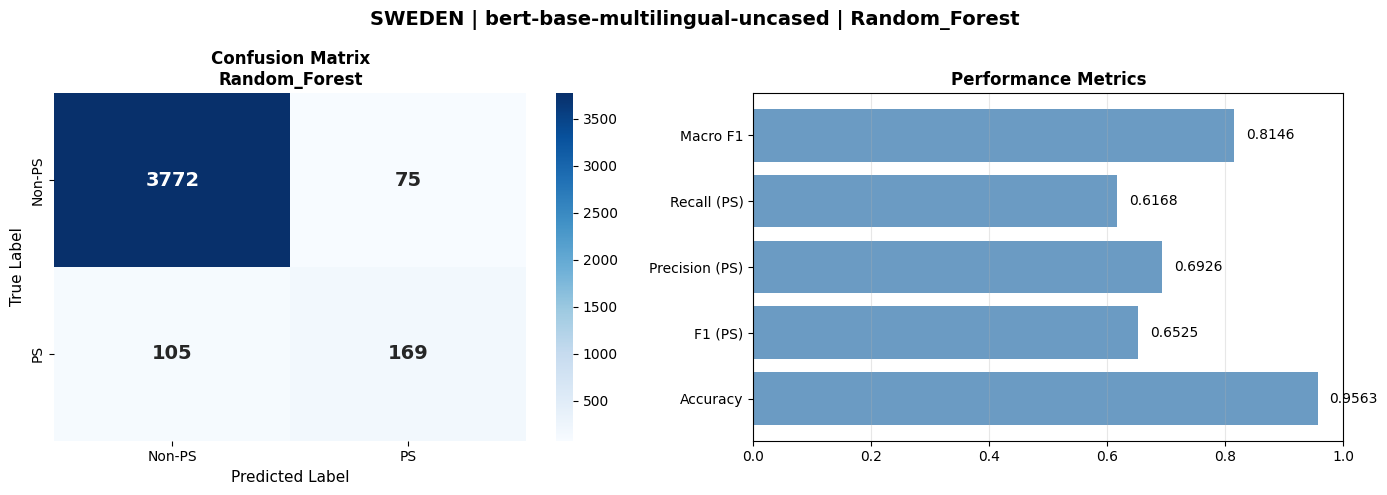


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: SWEDEN | bert-base-multilingual-uncased | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,781                 66
Actual: PS                           98                176
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9747          0.7273       0.8510
Recall                     0.9828          0.6423       0.8126
F1-Score                   0.9788          0.6822       0.8305
------------------------------------------------------------


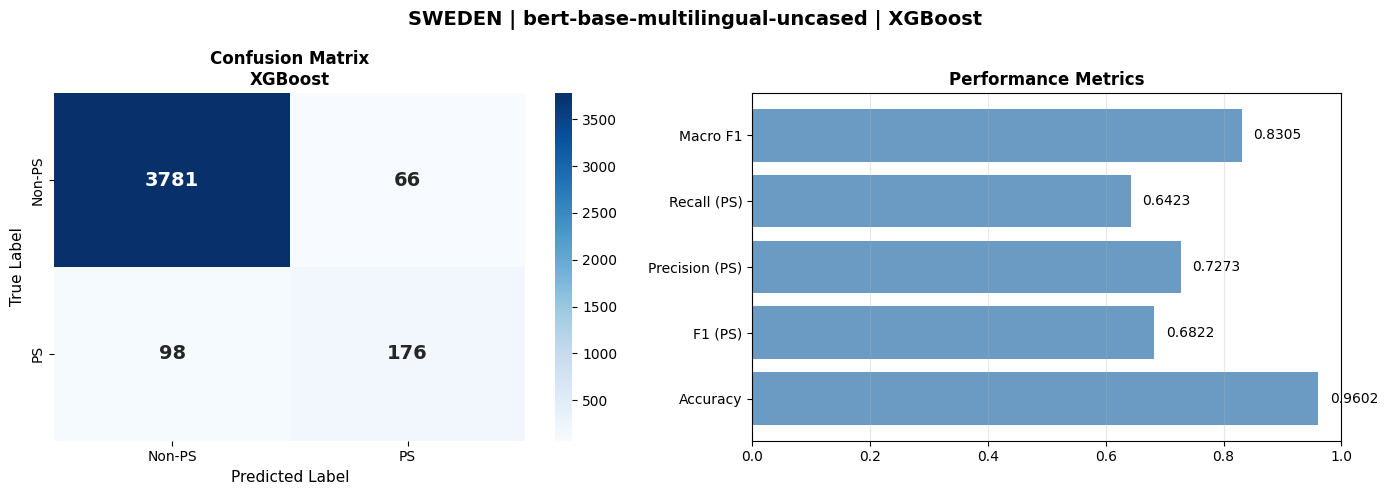


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: SWEDEN | bert-base-multilingual-uncased | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,772                 75
Actual: PS                           99                175
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9744          0.7000       0.8372
Recall                     0.9805          0.6387       0.8096
F1-Score                   0.9775          0.6679       0.8227
-----------------------------------------------------------

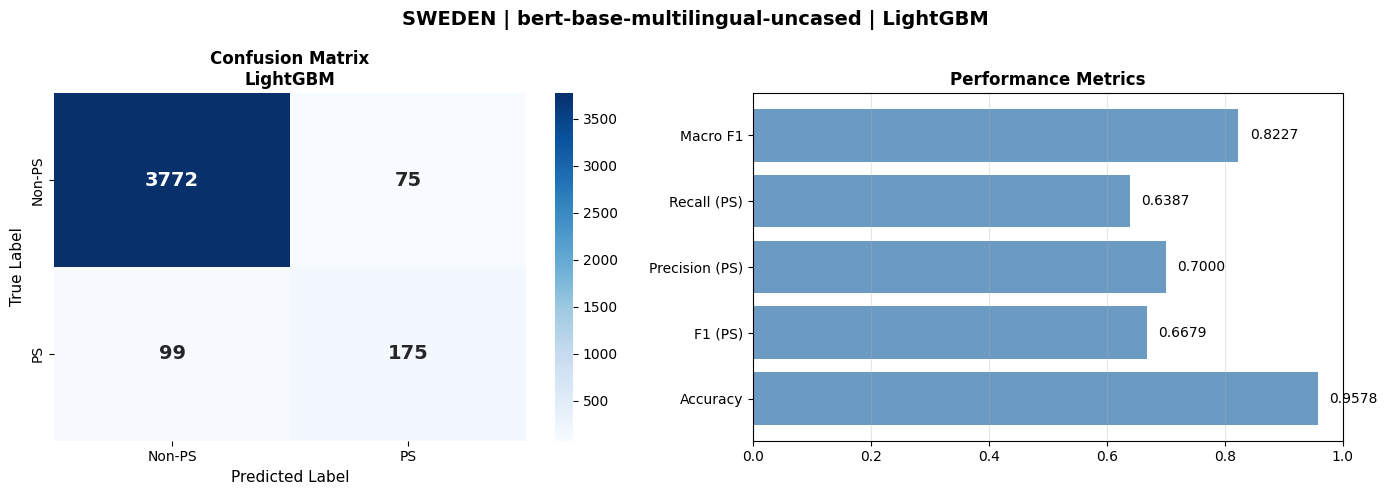


################################################################################
Loading: germany_bert-base-multilingual-uncased_embeddings.pkl
################################################################################
Dataset: GERMANY
Model: bert-base-multilingual-uncased
Training samples: 27356
Test samples: 4568
Embedding dim: 768

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: GERMANY | bert-base-multilingual-uncased | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,313                710
Actual: PS                          164                381
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Pro

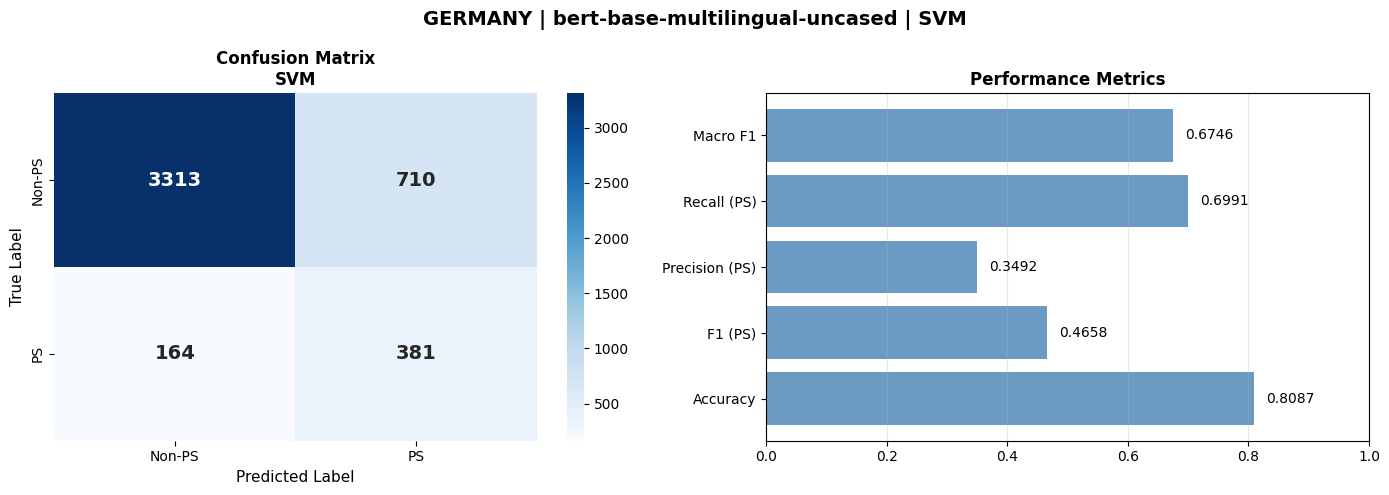


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: GERMANY | bert-base-multilingual-uncased | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,931                 92
Actual: PS                          118                427
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9709          0.8227       0.8968
Recall                     0.9771          0.7835       0.8803
F1-Score                   0.9740          0.8026       0.8883
------------------------------------------------

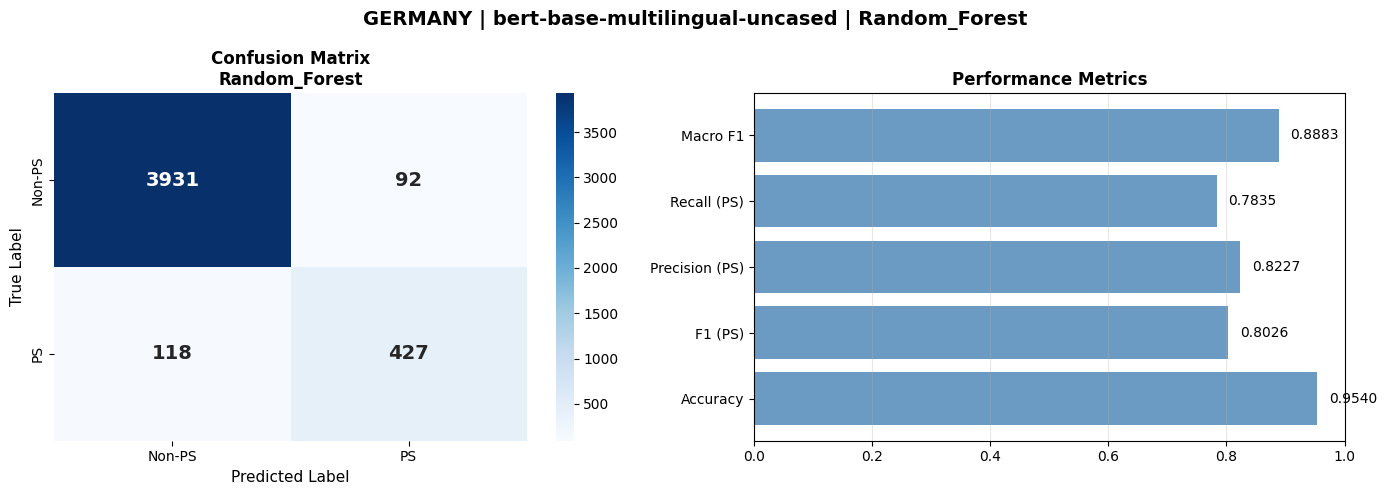


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: GERMANY | bert-base-multilingual-uncased | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,923                100
Actual: PS                          116                429
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9713          0.8110       0.8911
Recall                     0.9751          0.7872       0.8811
F1-Score                   0.9732          0.7989       0.8860
------------------------------------------------------------

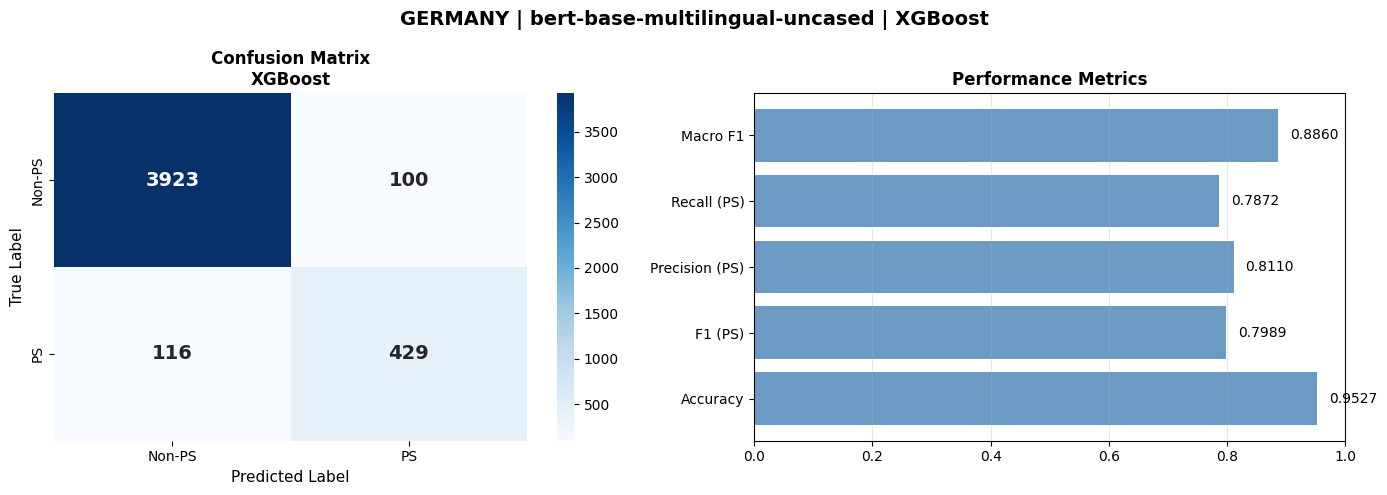


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: GERMANY | bert-base-multilingual-uncased | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,894                129
Actual: PS                          114                431
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9716          0.7696       0.8706
Recall                     0.9679          0.7908       0.8794
F1-Score                   0.9697          0.7801       0.8749
----------------------------------------------------------

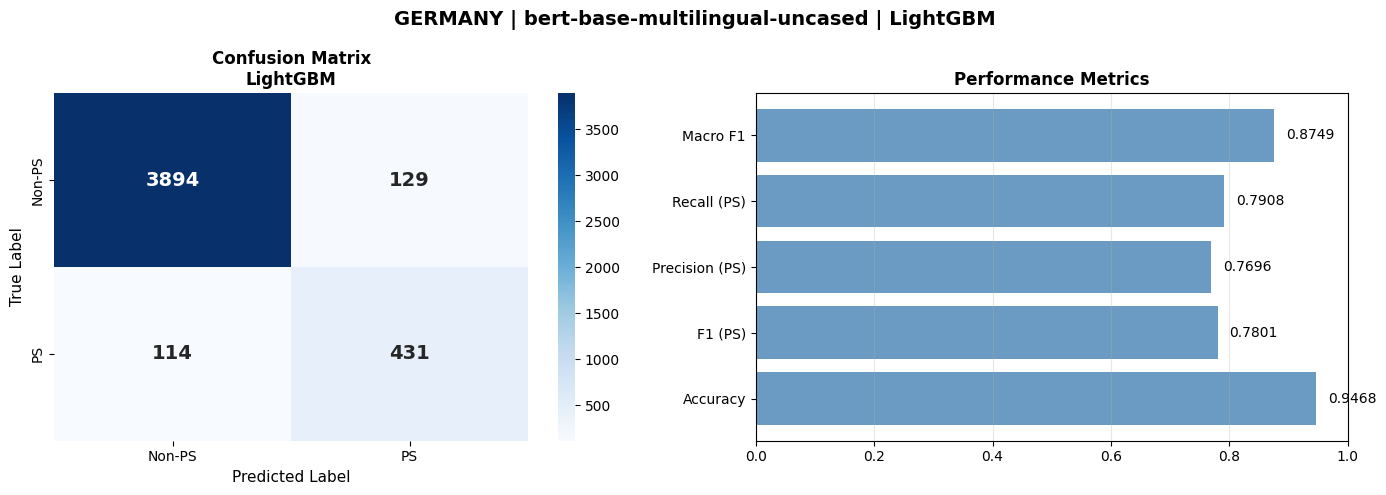


################################################################################
Loading: english_bert-base-multilingual-uncased_embeddings.pkl
################################################################################
Dataset: ENGLISH
Model: bert-base-multilingual-uncased
Training samples: 6621
Test samples: 1422
Embedding dim: 768

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: ENGLISH | bert-base-multilingual-uncased | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      795                180
Actual: PS                          106                341
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Proc

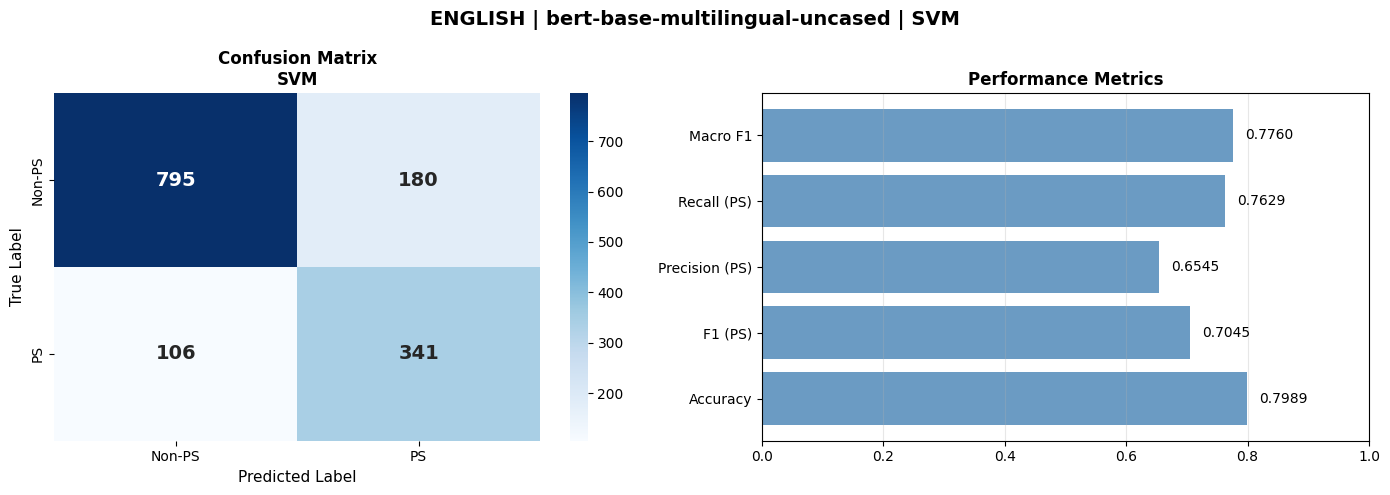


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: ENGLISH | bert-base-multilingual-uncased | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      925                 50
Actual: PS                           98                349
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9042          0.8747       0.8894
Recall                     0.9487          0.7808       0.8647
F1-Score                   0.9259          0.8251       0.8755
------------------------------------------------

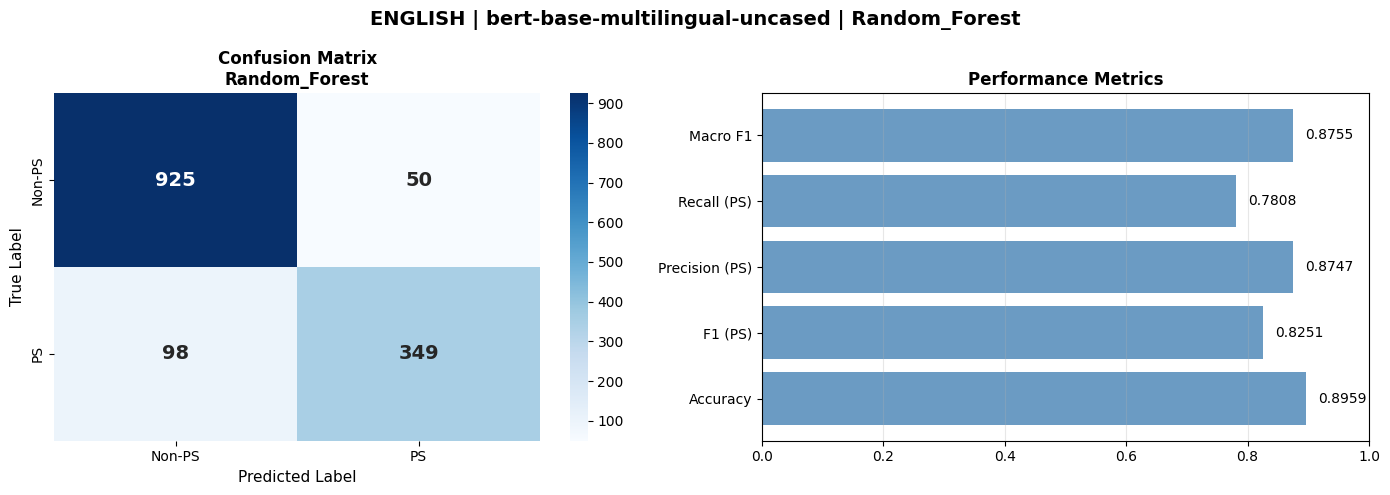


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: ENGLISH | bert-base-multilingual-uncased | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      916                 59
Actual: PS                           86                361
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9142          0.8595       0.8868
Recall                     0.9395          0.8076       0.8735
F1-Score                   0.9267          0.8328       0.8797
------------------------------------------------------------

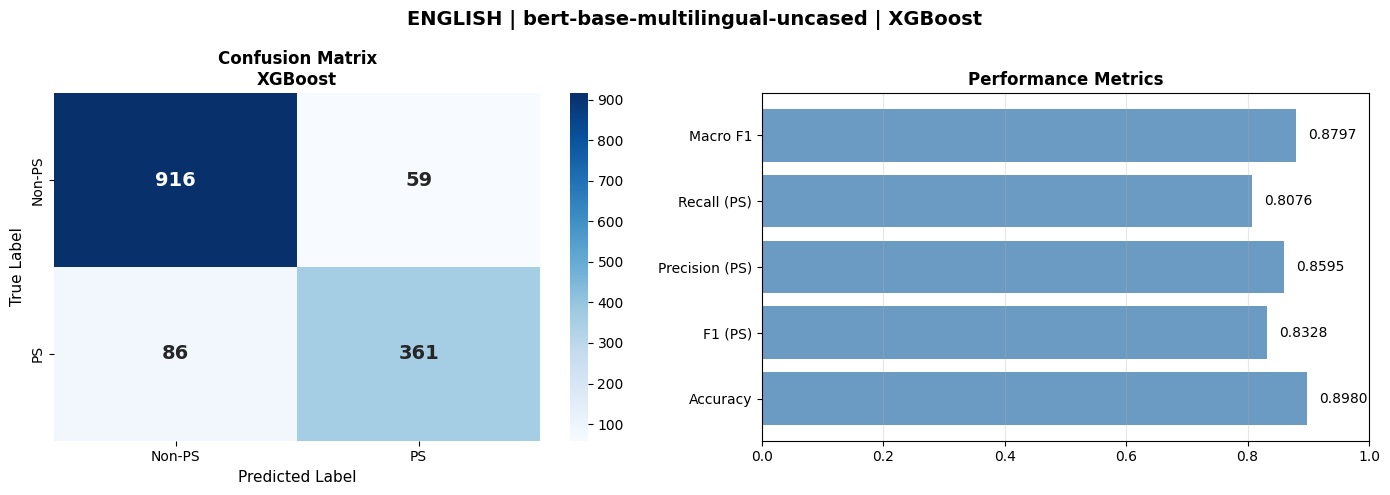


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: ENGLISH | bert-base-multilingual-uncased | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      901                 74
Actual: PS                           90                357
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9092          0.8283       0.8687
Recall                     0.9241          0.7987       0.8614
F1-Score                   0.9166          0.8132       0.8649
----------------------------------------------------------

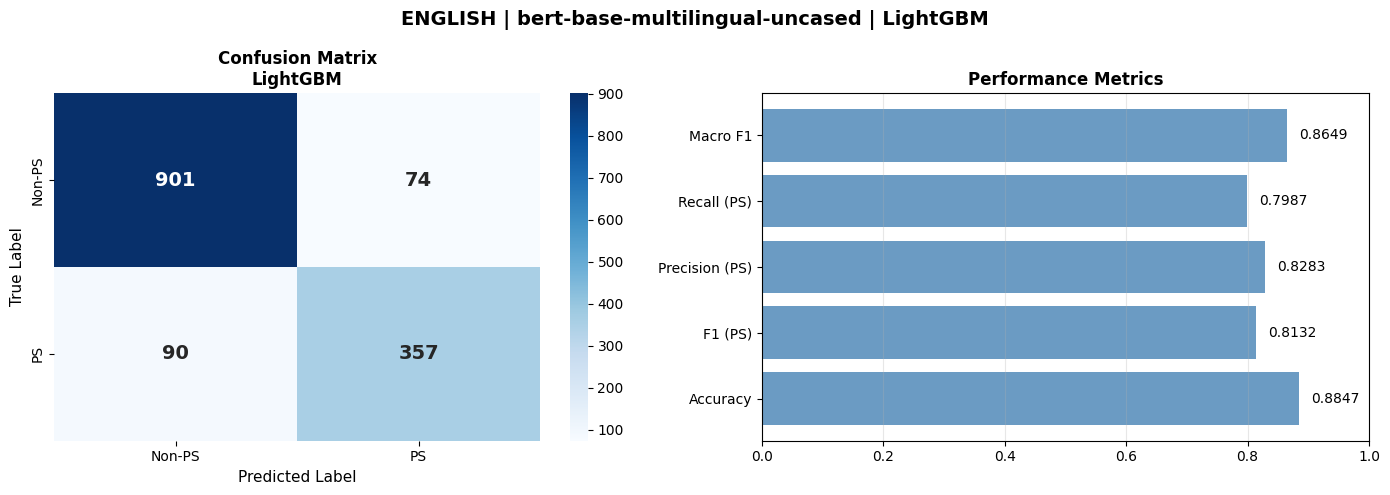


################################################################################
Loading: uk_bert-base-multilingual-uncased_embeddings.pkl
################################################################################
Dataset: UK
Model: bert-base-multilingual-uncased
Training samples: 6582
Test samples: 1407
Embedding dim: 768

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: UK | bert-base-multilingual-uncased | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      779                190
Actual: PS                          107                331
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    M

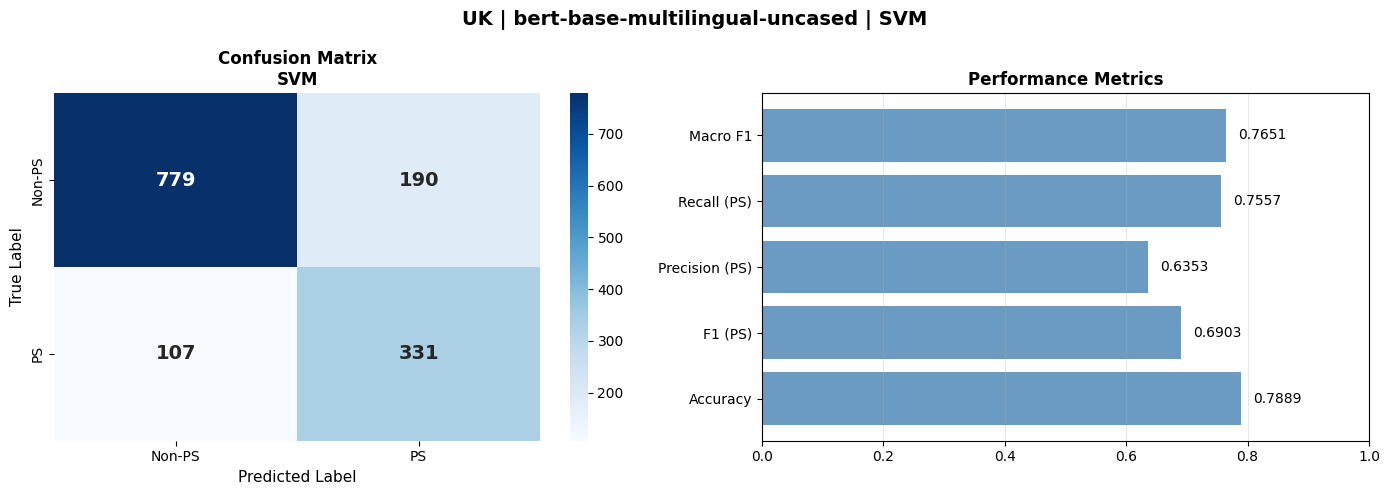


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: UK | bert-base-multilingual-uncased | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      910                 59
Actual: PS                          100                338
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9010          0.8514       0.8762
Recall                     0.9391          0.7717       0.8554
F1-Score                   0.9197          0.8096       0.8646
-----------------------------------------------------

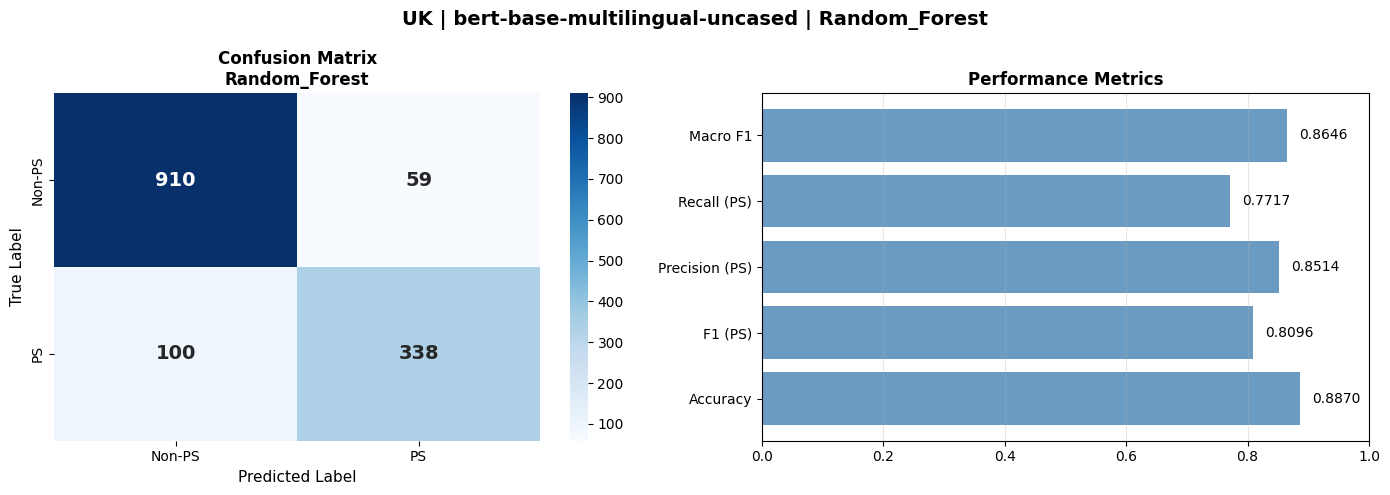


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: UK | bert-base-multilingual-uncased | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      899                 70
Actual: PS                           87                351
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9118          0.8337       0.8727
Recall                     0.9278          0.8014       0.8646
F1-Score                   0.9197          0.8172       0.8685
------------------------------------------------------------
Accu

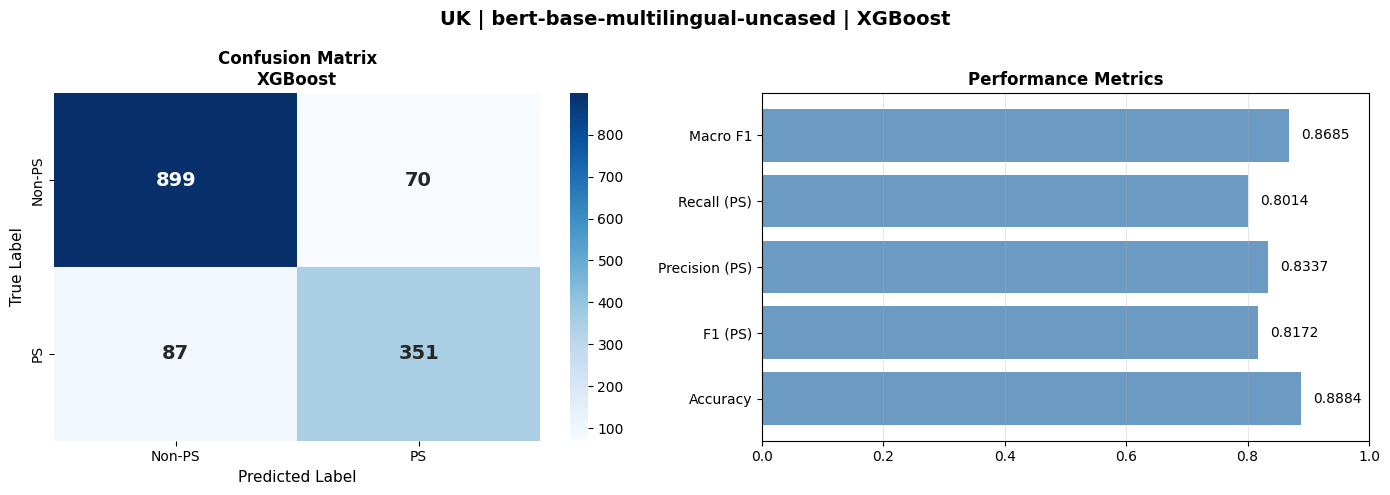


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: UK | bert-base-multilingual-uncased | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      904                 65
Actual: PS                           85                353
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9141          0.8445       0.8793
Recall                     0.9329          0.8059       0.8694
F1-Score                   0.9234          0.8248       0.8741
------------------------------------------------------------
Ac

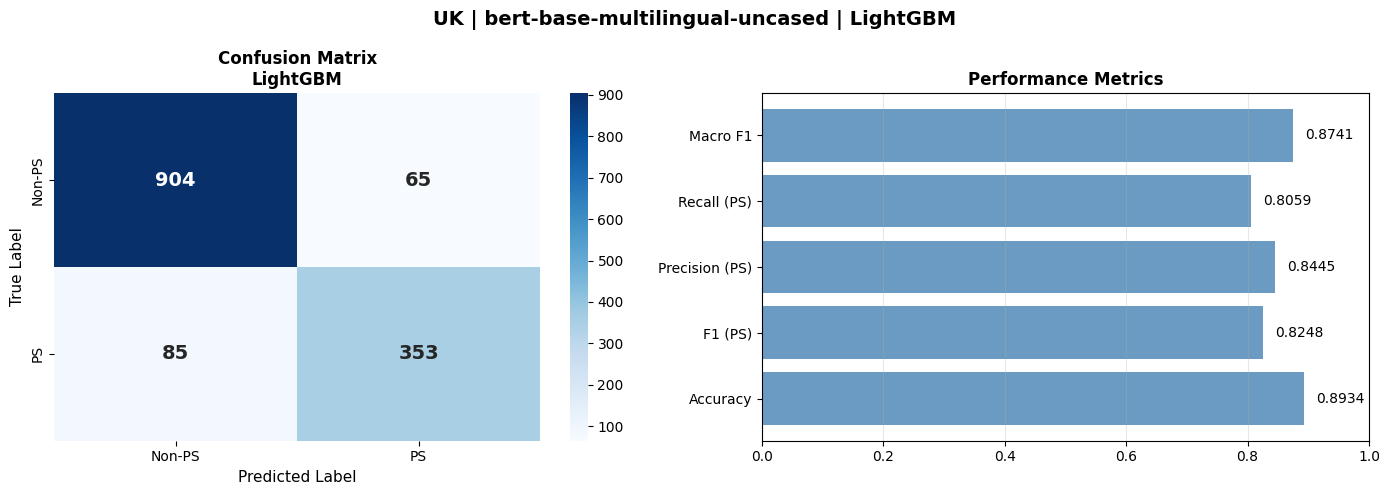


################################################################################
Loading: netherlands_bert-base-multilingual-uncased_embeddings.pkl
################################################################################
Dataset: NETHERLANDS
Model: bert-base-multilingual-uncased
Training samples: 3005
Test samples: 638
Embedding dim: 768

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: NETHERLANDS | bert-base-multilingual-uncased | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      378                 65
Actual: PS                           40                155
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     N

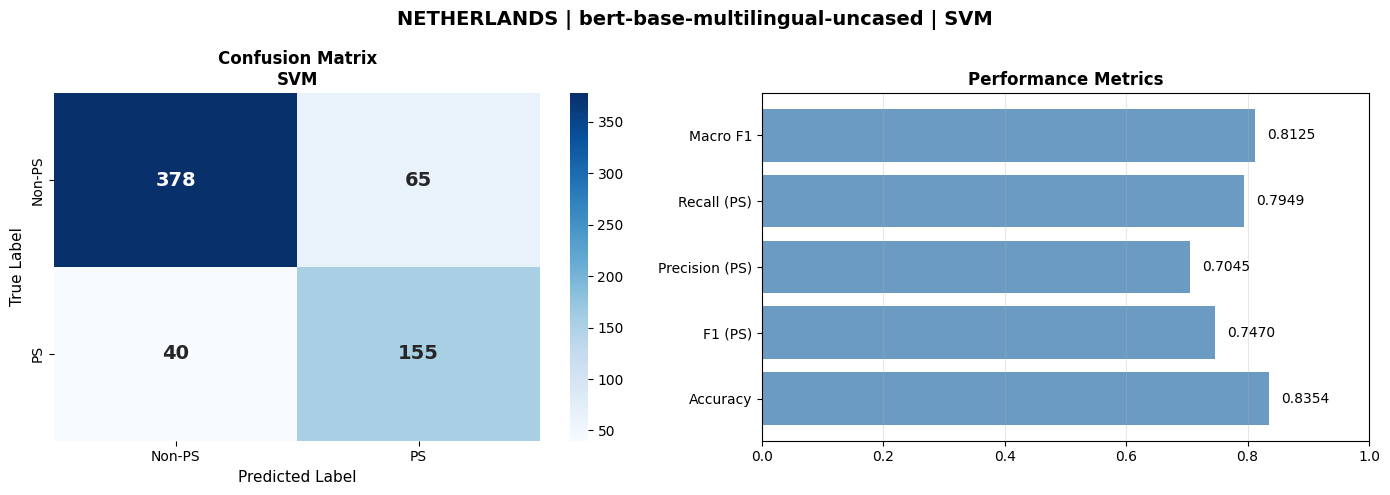


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: NETHERLANDS | bert-base-multilingual-uncased | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      414                 29
Actual: PS                           61                134
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.8716          0.8221       0.8468
Recall                     0.9345          0.6872       0.8109
F1-Score                   0.9020          0.7486       0.8253
--------------------------------------------

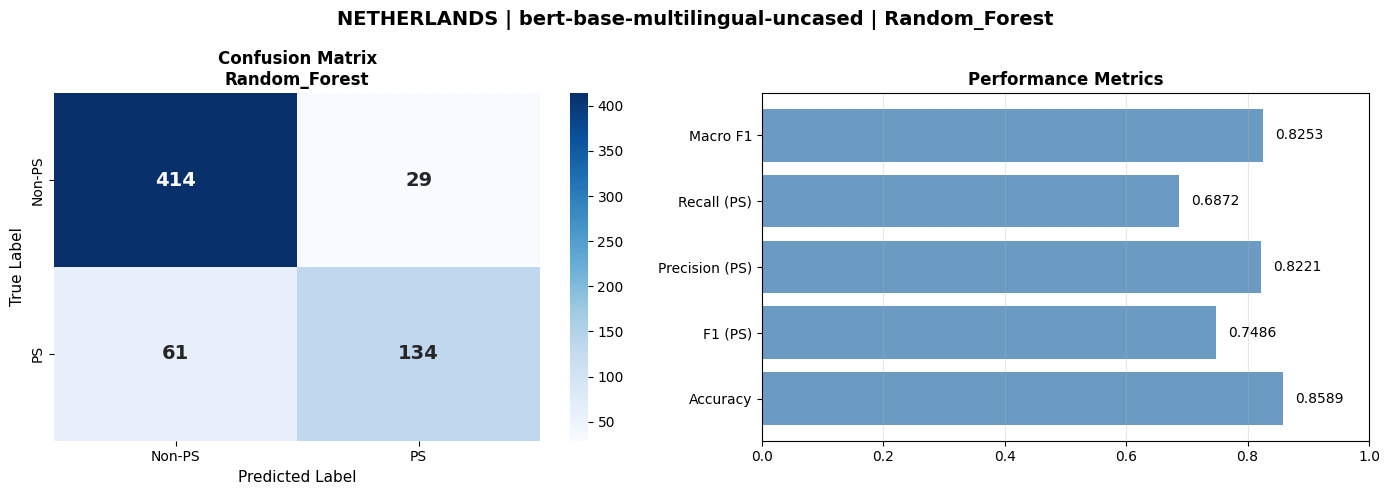


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: NETHERLANDS | bert-base-multilingual-uncased | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      401                 42
Actual: PS                           49                146
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.8911          0.7766       0.8339
Recall                     0.9052          0.7487       0.8270
F1-Score                   0.8981          0.7624       0.8302
--------------------------------------------------------

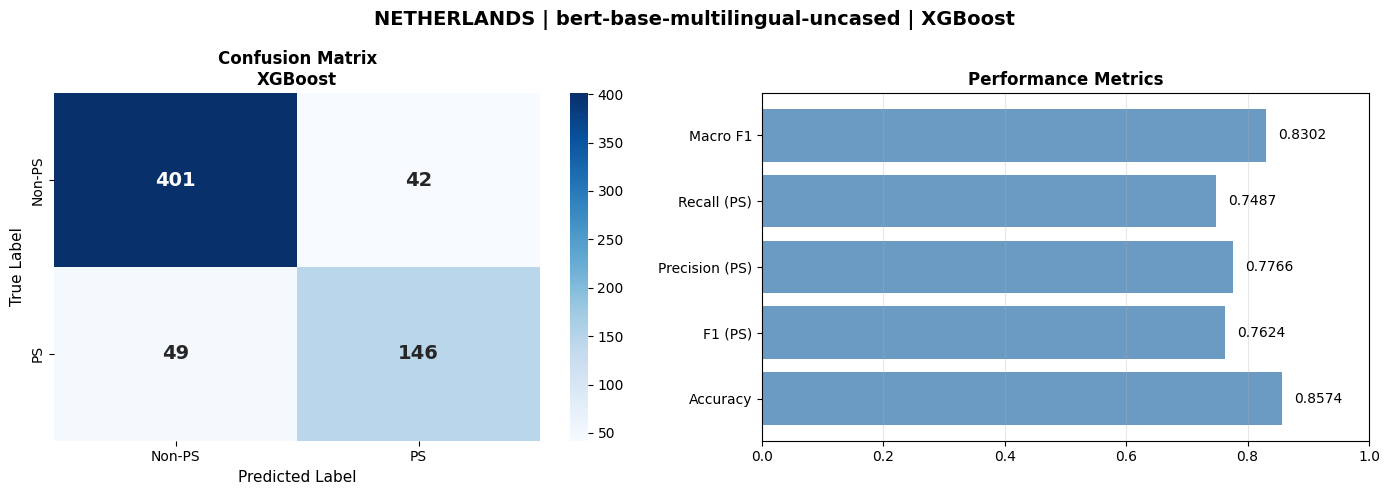


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: NETHERLANDS | bert-base-multilingual-uncased | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      400                 43
Actual: PS                           47                148
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.8949          0.7749       0.8349
Recall                     0.9029          0.7590       0.8310
F1-Score                   0.8989          0.7668       0.8329
------------------------------------------------------

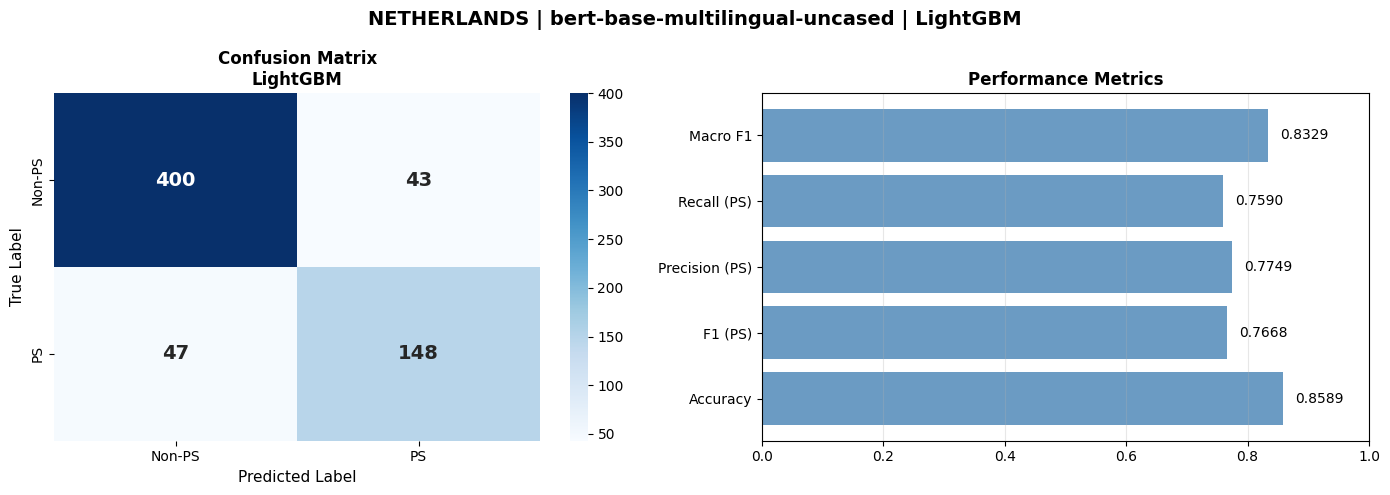


################################################################################
Loading: netherlands_xlm-roberta-base_embeddings.pkl
################################################################################
Dataset: NETHERLANDS
Model: xlm-roberta-base
Training samples: 3005
Test samples: 638
Embedding dim: 768

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: NETHERLANDS | xlm-roberta-base | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      385                 58
Actual: PS                           40                155
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
-------

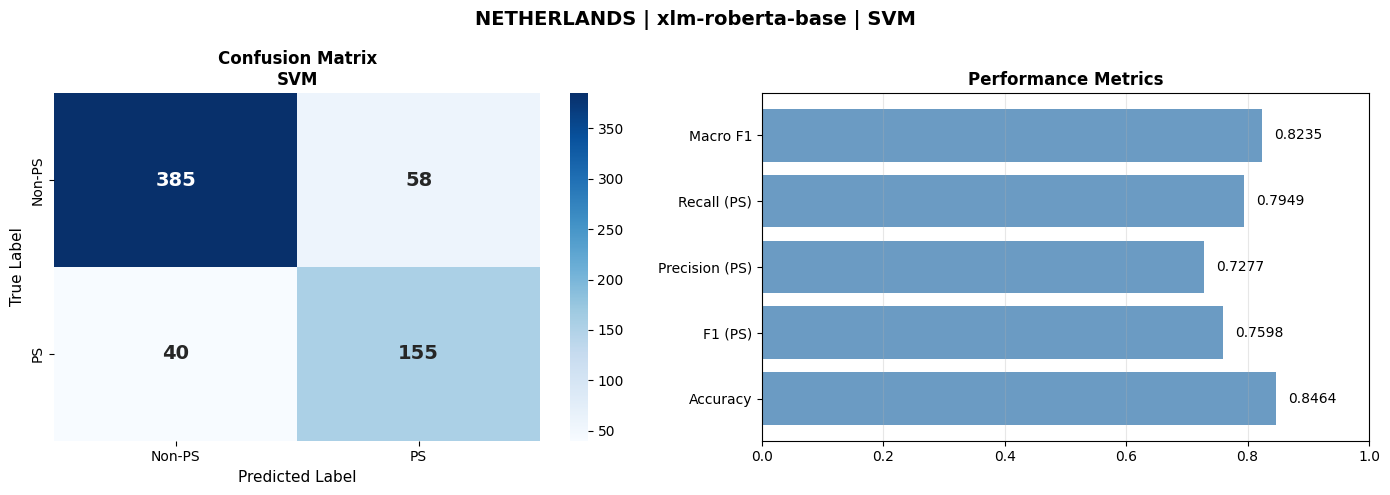


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: NETHERLANDS | xlm-roberta-base | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      400                 43
Actual: PS                           58                137
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.8734          0.7611       0.8172
Recall                     0.9029          0.7026       0.8027
F1-Score                   0.8879          0.7307       0.8093
----------------------------------------------------------

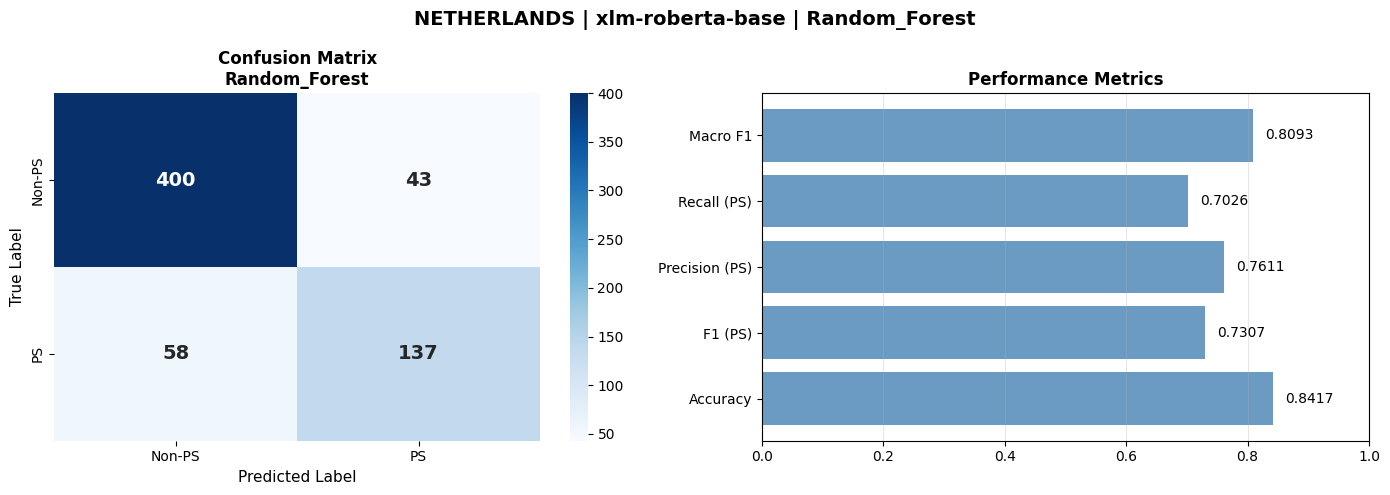


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: NETHERLANDS | xlm-roberta-base | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      394                 49
Actual: PS                           45                150
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.8975          0.7538       0.8256
Recall                     0.8894          0.7692       0.8293
F1-Score                   0.8934          0.7614       0.8274
------------------------------------------------------------
Accuracy 

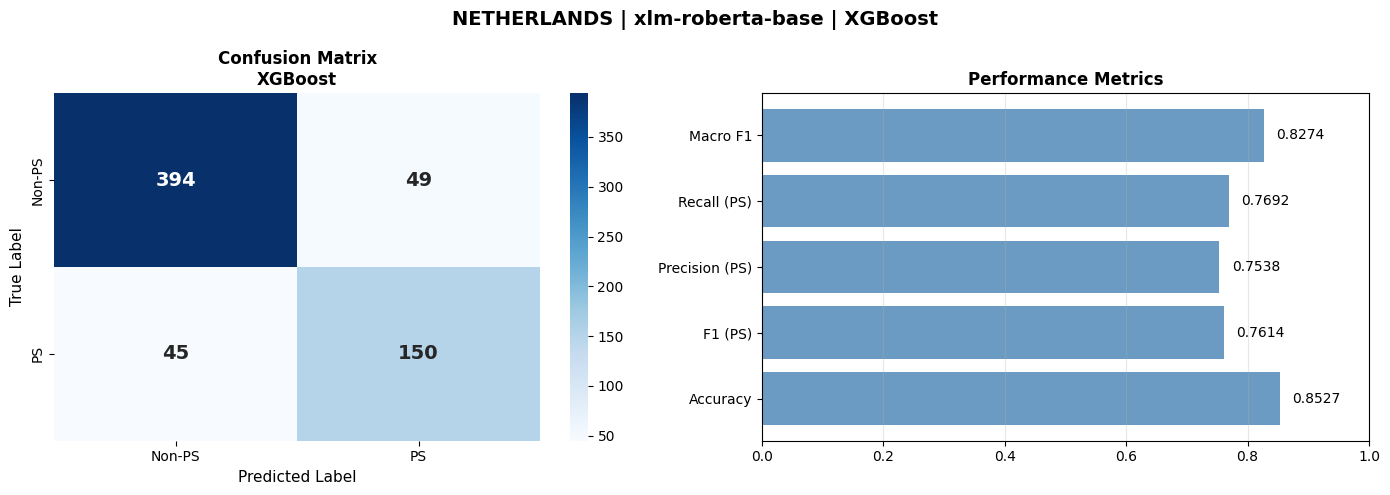


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: NETHERLANDS | xlm-roberta-base | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      396                 47
Actual: PS                           50                145
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.8879          0.7552       0.8216
Recall                     0.8939          0.7436       0.8187
F1-Score                   0.8909          0.7494       0.8201
------------------------------------------------------------
Accurac

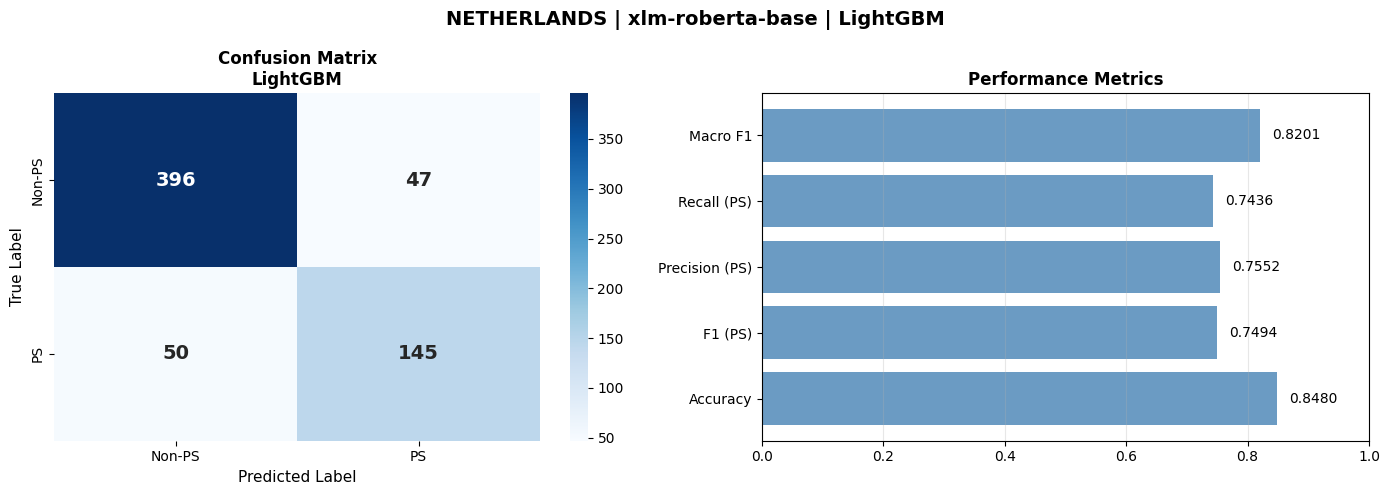


################################################################################
Loading: germany_xlm-roberta-base_embeddings.pkl
################################################################################
Dataset: GERMANY
Model: xlm-roberta-base
Training samples: 27356
Test samples: 4568
Embedding dim: 768

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: GERMANY | xlm-roberta-base | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,327                696
Actual: PS                          153                392
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
-----------------

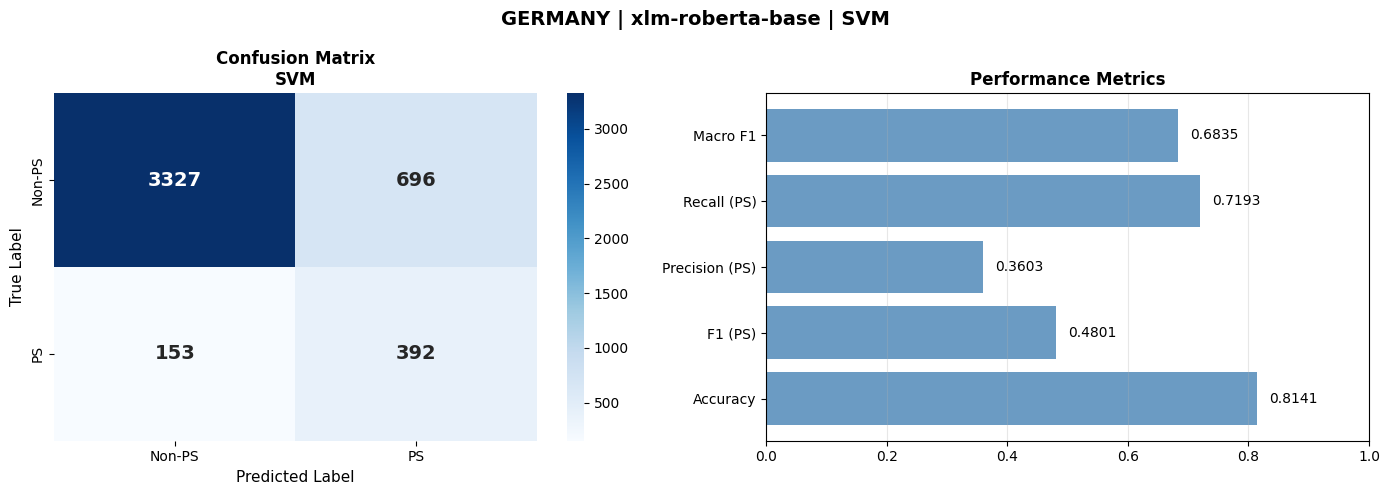


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: GERMANY | xlm-roberta-base | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,930                 93
Actual: PS                          125                420
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9692          0.8187       0.8939
Recall                     0.9769          0.7706       0.8738
F1-Score                   0.9730          0.7940       0.8835
------------------------------------------------------------
A

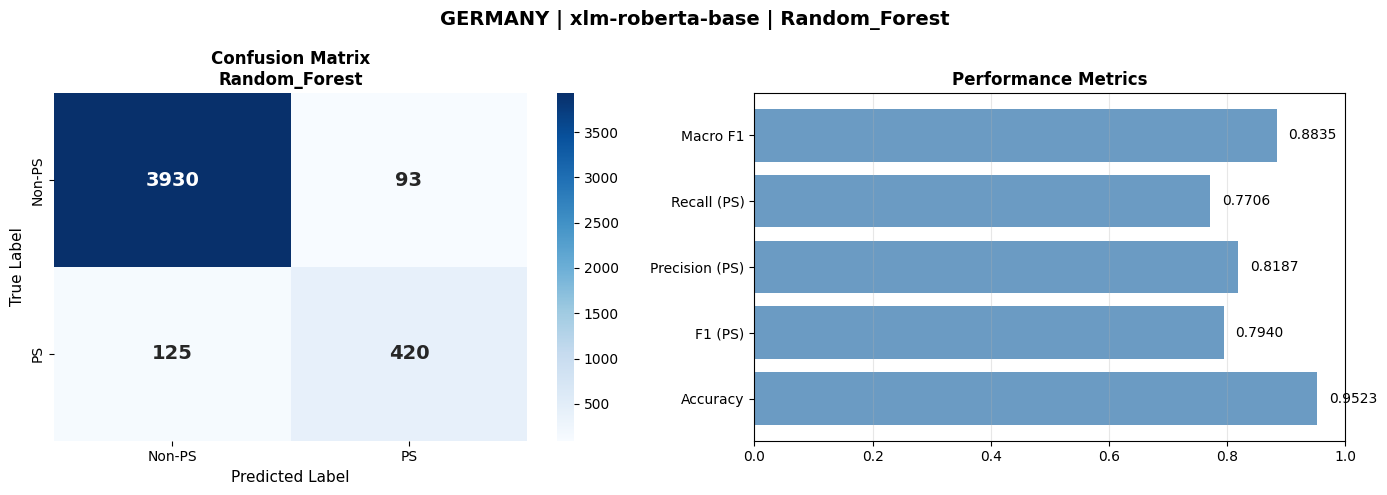


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: GERMANY | xlm-roberta-base | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,923                100
Actual: PS                          108                437
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9732          0.8138       0.8935
Recall                     0.9751          0.8018       0.8885
F1-Score                   0.9742          0.8078       0.8910
------------------------------------------------------------
Accuracy     

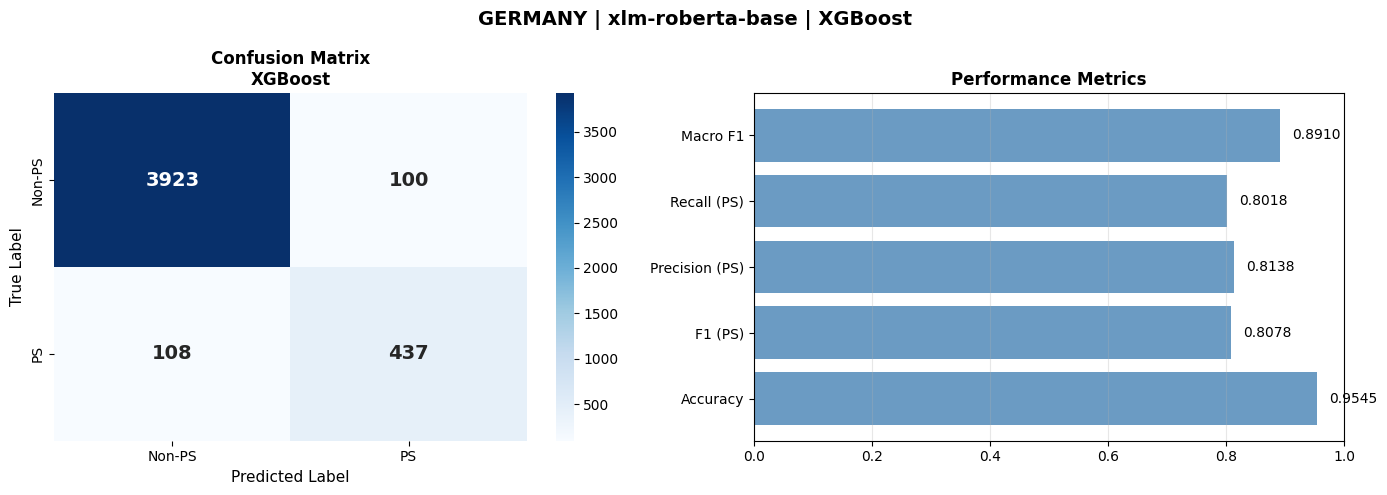


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: GERMANY | xlm-roberta-base | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,900                123
Actual: PS                          114                431
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9716          0.7780       0.8748
Recall                     0.9694          0.7908       0.8801
F1-Score                   0.9705          0.7843       0.8774
------------------------------------------------------------
Accuracy   

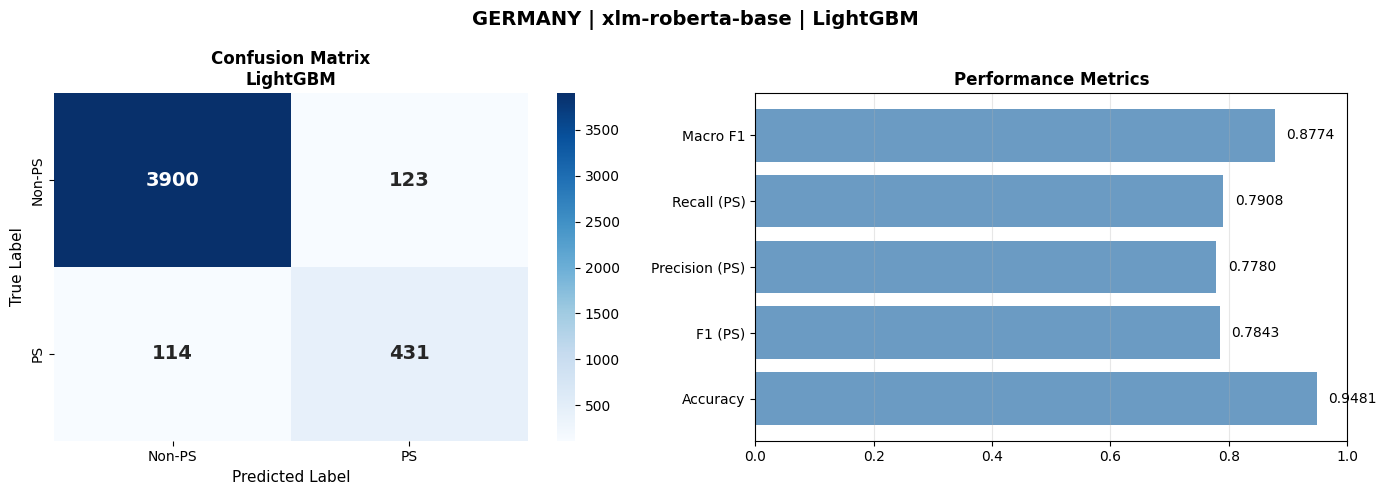


################################################################################
Loading: english_xlm-roberta-base_embeddings.pkl
################################################################################
Dataset: ENGLISH
Model: xlm-roberta-base
Training samples: 6621
Test samples: 1422
Embedding dim: 768

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: ENGLISH | xlm-roberta-base | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      786                189
Actual: PS                          112                335
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------

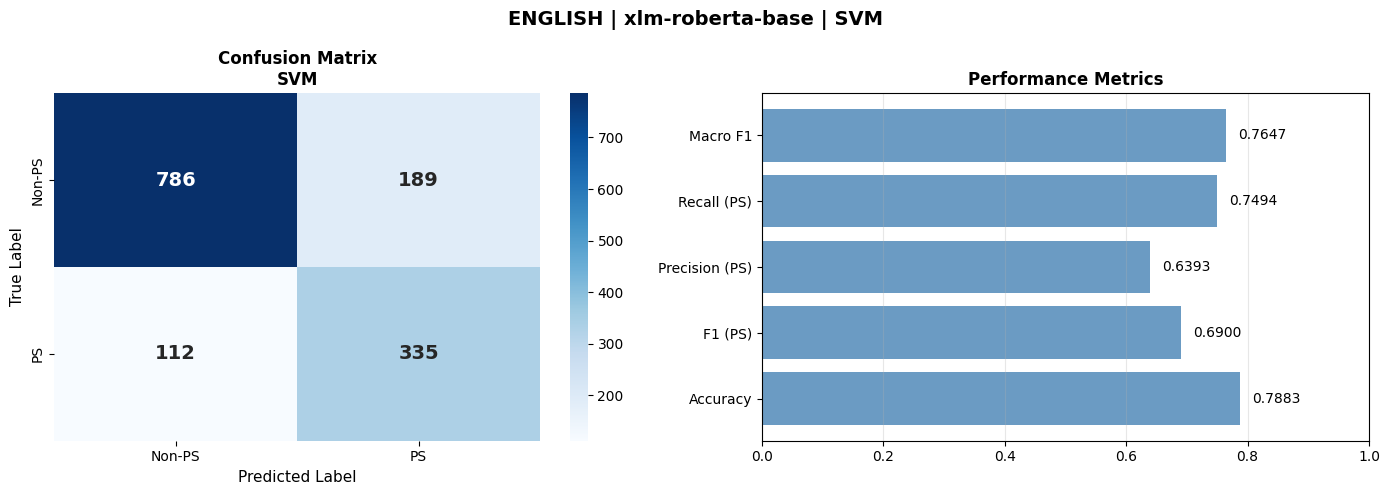


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: ENGLISH | xlm-roberta-base | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      918                 57
Actual: PS                           87                360
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9134          0.8633       0.8884
Recall                     0.9415          0.8054       0.8735
F1-Score                   0.9273          0.8333       0.8803
------------------------------------------------------------
A

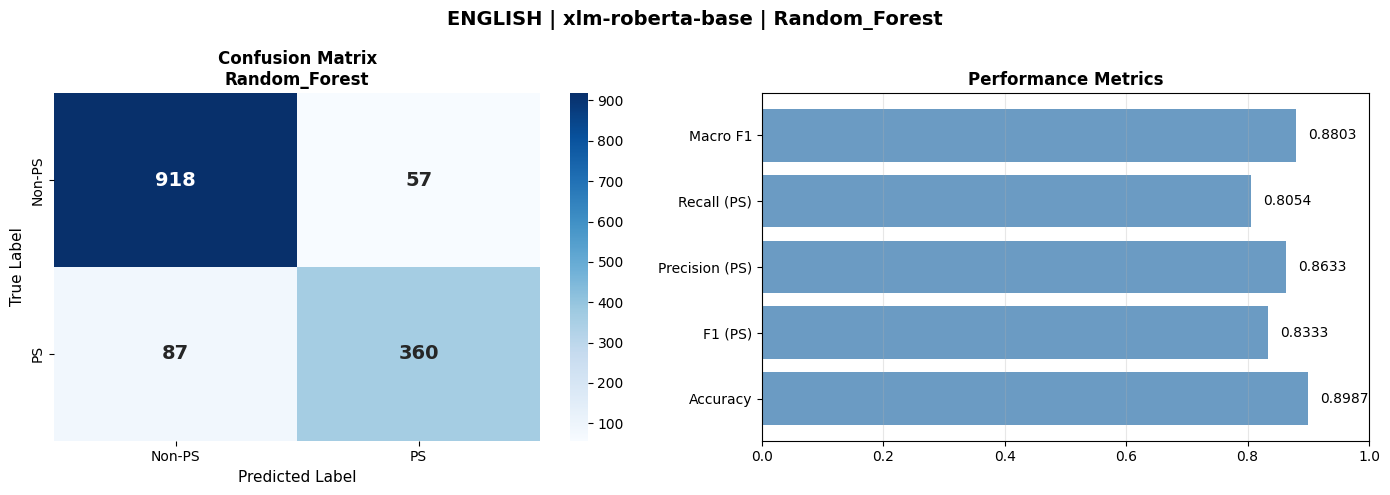


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: ENGLISH | xlm-roberta-base | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      918                 57
Actual: PS                           81                366
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9189          0.8652       0.8921
Recall                     0.9415          0.8188       0.8802
F1-Score                   0.9301          0.8414       0.8857
------------------------------------------------------------
Accuracy     

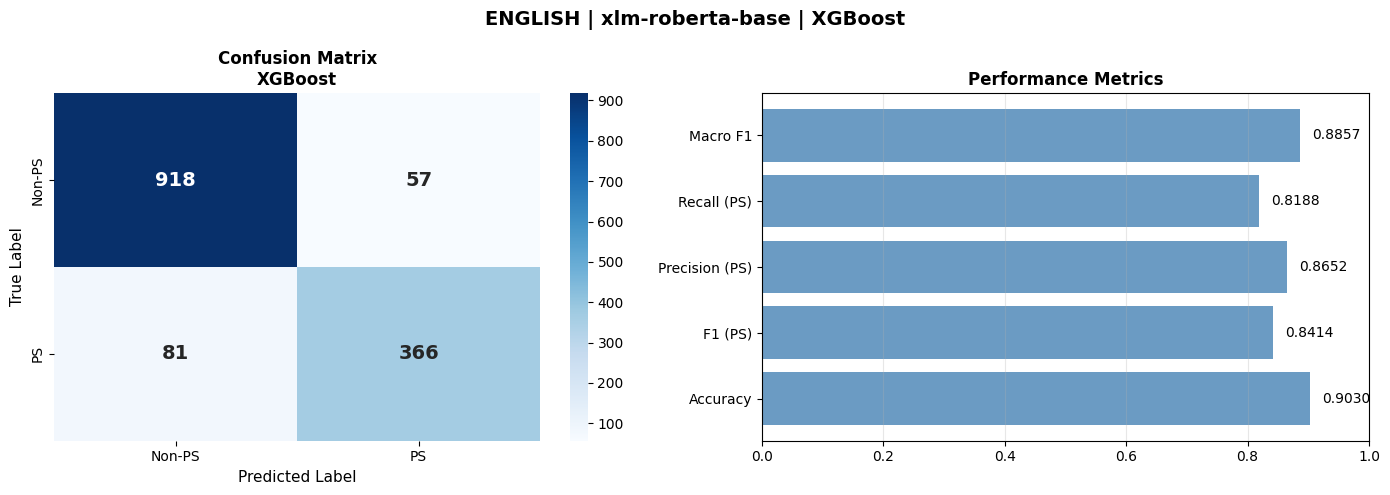


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: ENGLISH | xlm-roberta-base | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      911                 64
Actual: PS                           85                362
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9147          0.8498       0.8822
Recall                     0.9344          0.8098       0.8721
F1-Score                   0.9244          0.8293       0.8769
------------------------------------------------------------
Accuracy   

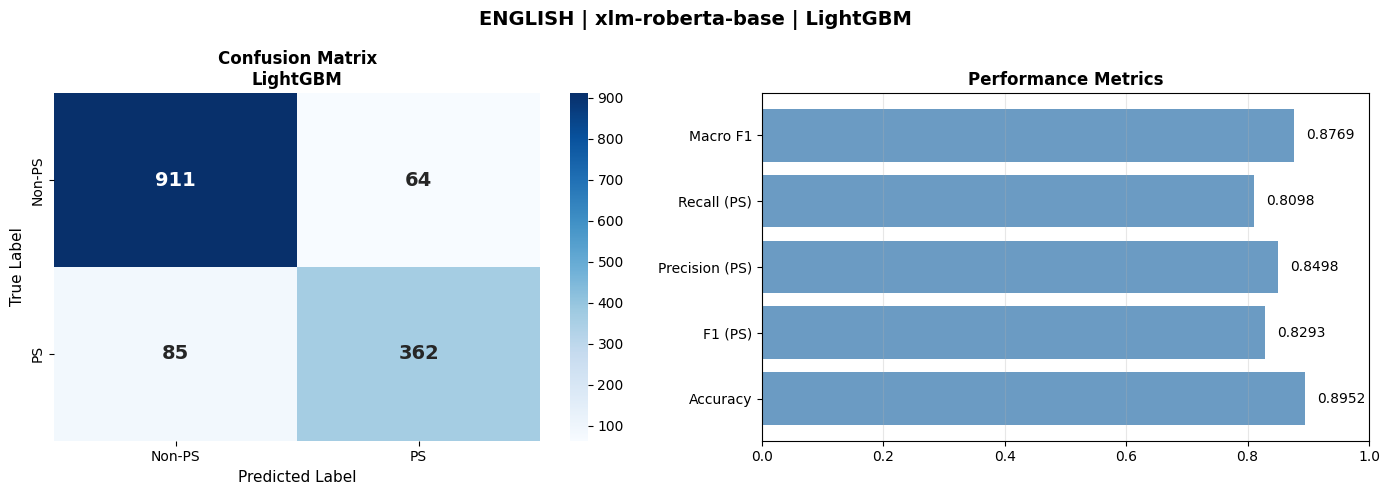


################################################################################
Loading: uk_xlm-roberta-base_embeddings.pkl
################################################################################
Dataset: UK
Model: xlm-roberta-base
Training samples: 6582
Test samples: 1407
Embedding dim: 768

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: UK | xlm-roberta-base | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      773                196
Actual: PS                          106                332
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
---------------------------------

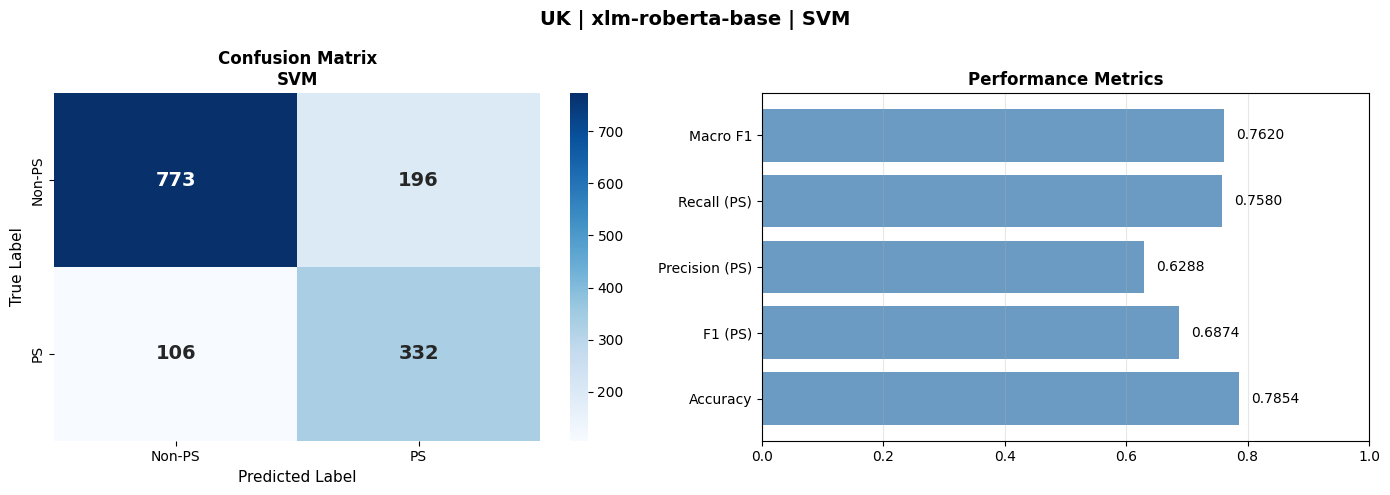


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: UK | xlm-roberta-base | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      892                 77
Actual: PS                           85                353
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9130          0.8209       0.8670
Recall                     0.9205          0.8059       0.8632
F1-Score                   0.9168          0.8134       0.8651
------------------------------------------------------------
Accura

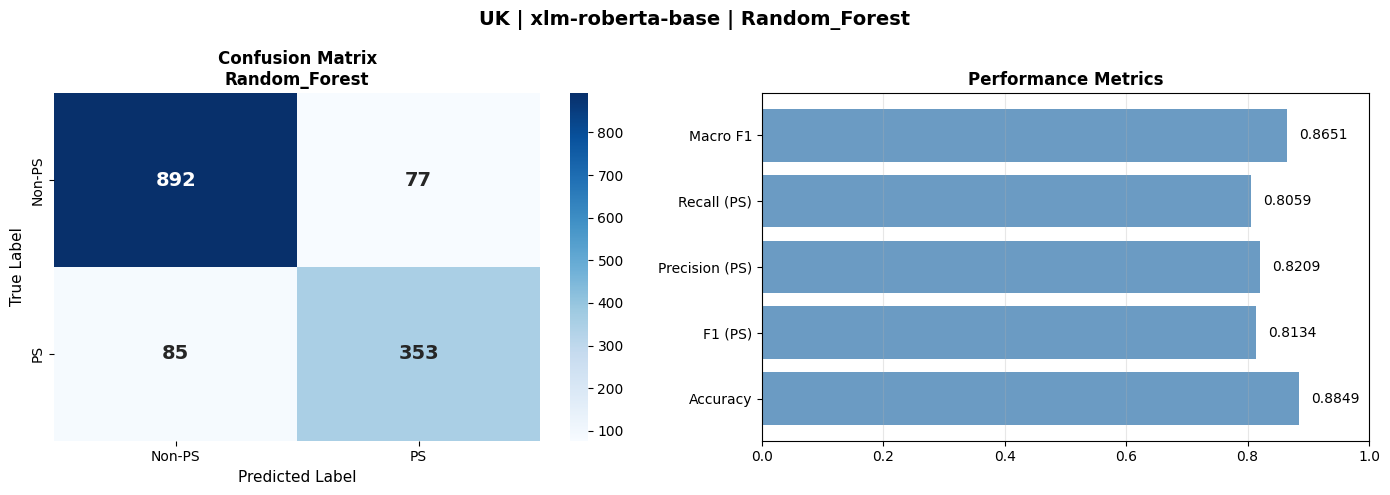


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: UK | xlm-roberta-base | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      898                 71
Actual: PS                           81                357
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9173          0.8341       0.8757
Recall                     0.9267          0.8151       0.8709
F1-Score                   0.9220          0.8245       0.8732
------------------------------------------------------------
Accuracy          

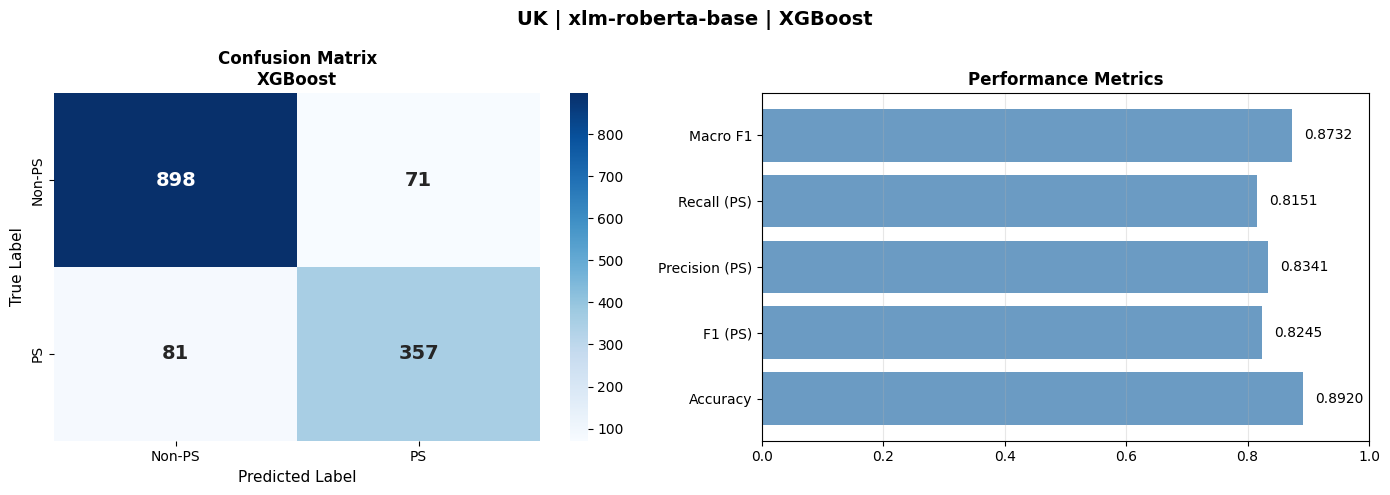


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: UK | xlm-roberta-base | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      900                 69
Actual: PS                           73                365
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9250          0.8410       0.8830
Recall                     0.9288          0.8333       0.8811
F1-Score                   0.9269          0.8372       0.8820
------------------------------------------------------------
Accuracy        

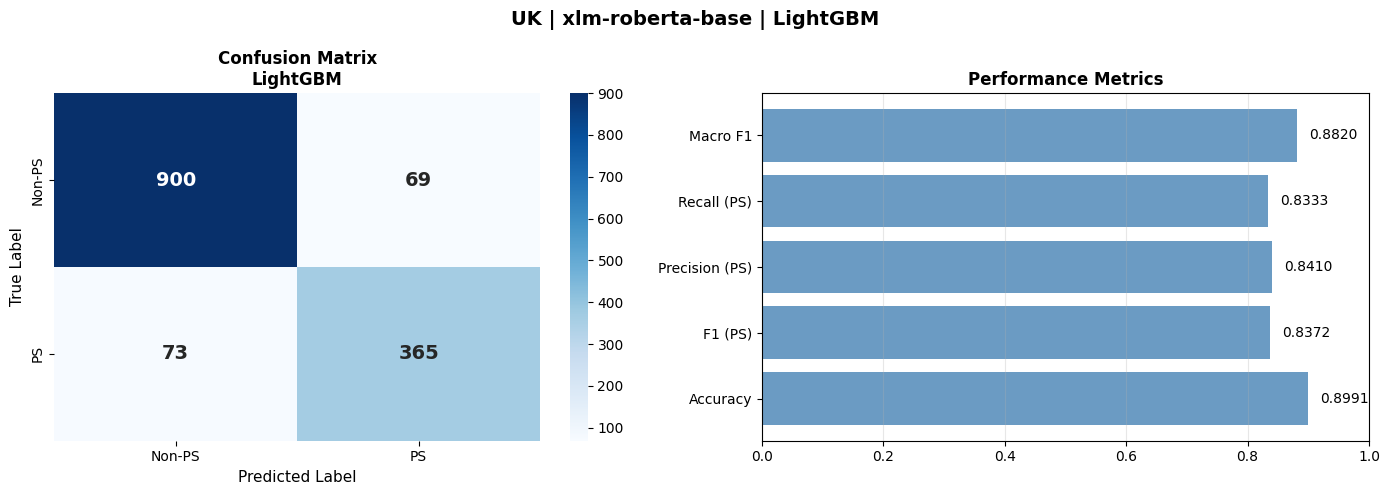


################################################################################
Loading: sweden_xlm-roberta-base_embeddings.pkl
################################################################################
Dataset: SWEDEN
Model: xlm-roberta-base
Training samples: 26161
Test samples: 4121
Embedding dim: 768

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: SWEDEN | xlm-roberta-base | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,193                654
Actual: PS                           92                182
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
--------------------

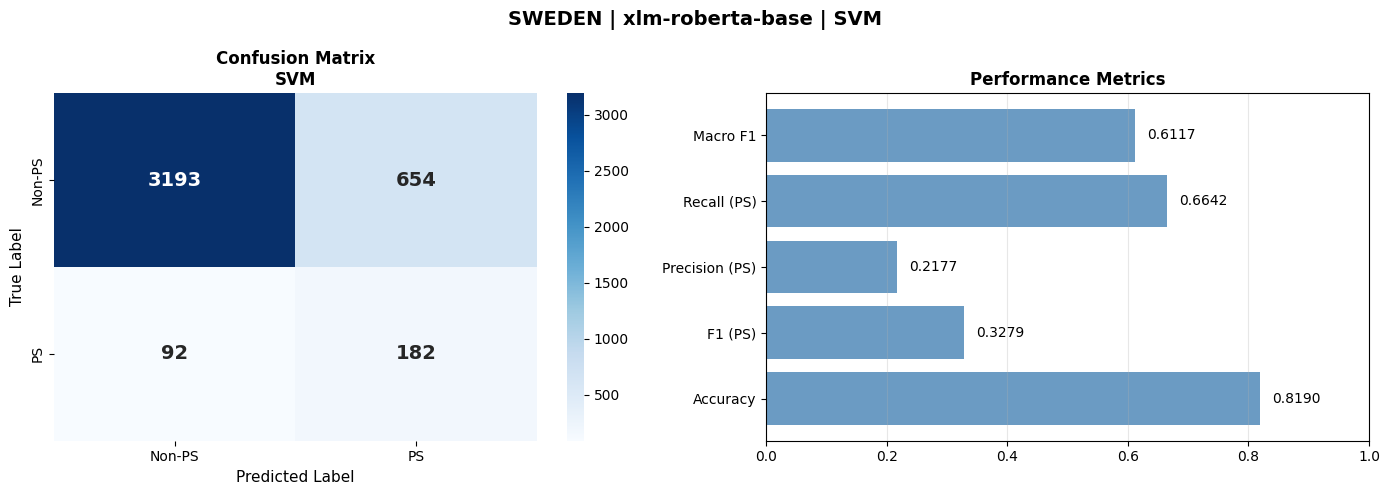


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: SWEDEN | xlm-roberta-base | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,756                 91
Actual: PS                          101                173
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9738          0.6553       0.8146
Recall                     0.9763          0.6314       0.8039
F1-Score                   0.9751          0.6431       0.8091
------------------------------------------------------------
Ac

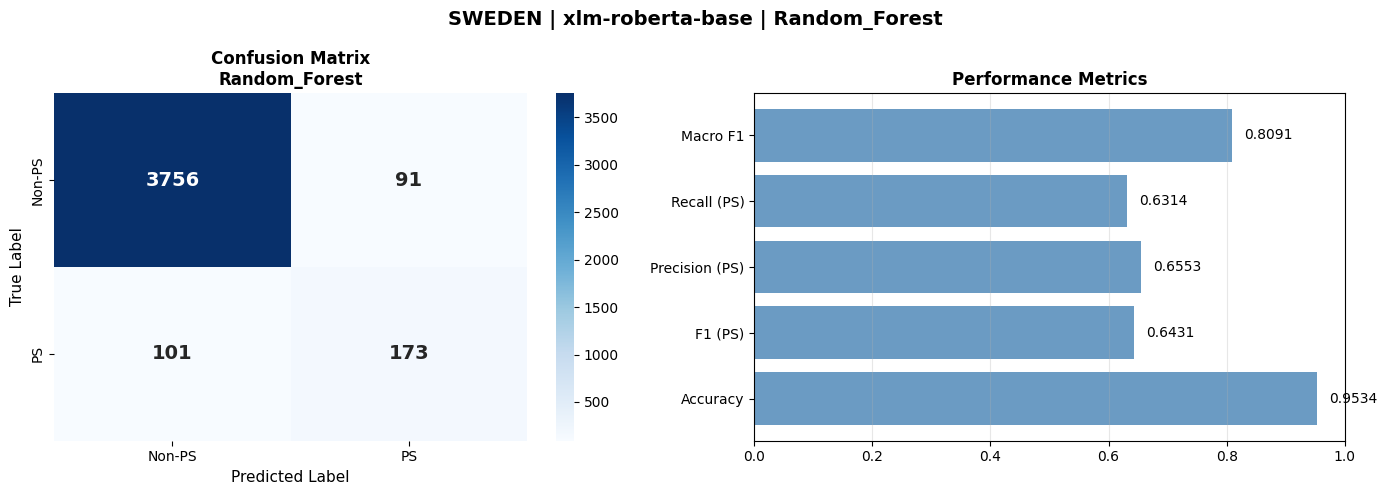


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: SWEDEN | xlm-roberta-base | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,774                 73
Actual: PS                           96                178
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9752          0.7092       0.8422
Recall                     0.9810          0.6496       0.8153
F1-Score                   0.9781          0.6781       0.8281
------------------------------------------------------------
Accuracy      

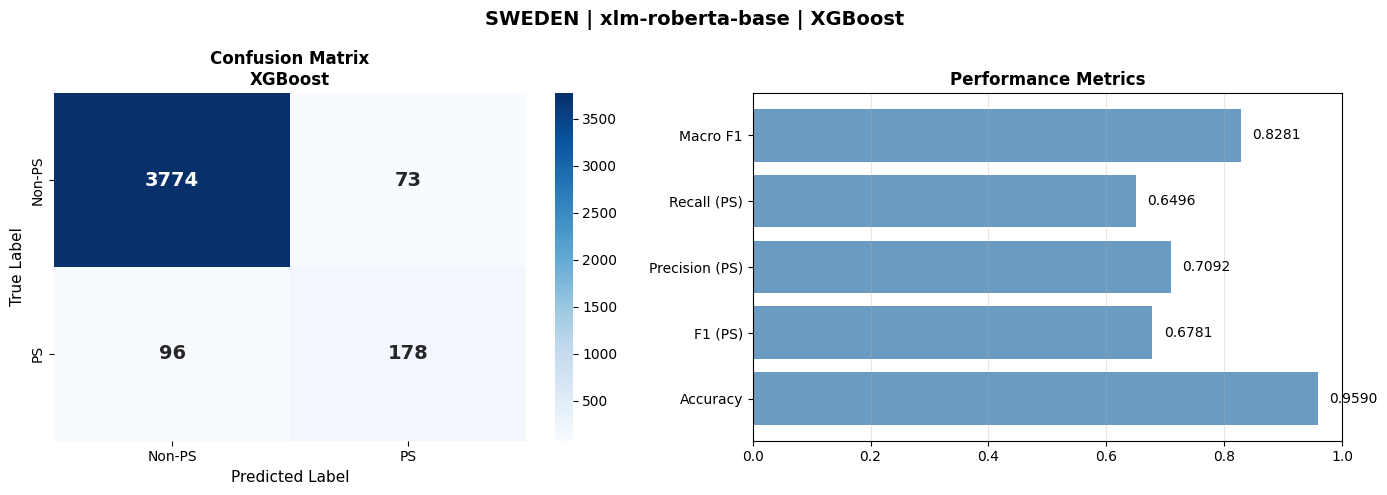


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: SWEDEN | xlm-roberta-base | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,772                 75
Actual: PS                           97                177
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9749          0.7024       0.8387
Recall                     0.9805          0.6460       0.8132
F1-Score                   0.9777          0.6730       0.8254
------------------------------------------------------------
Accuracy    

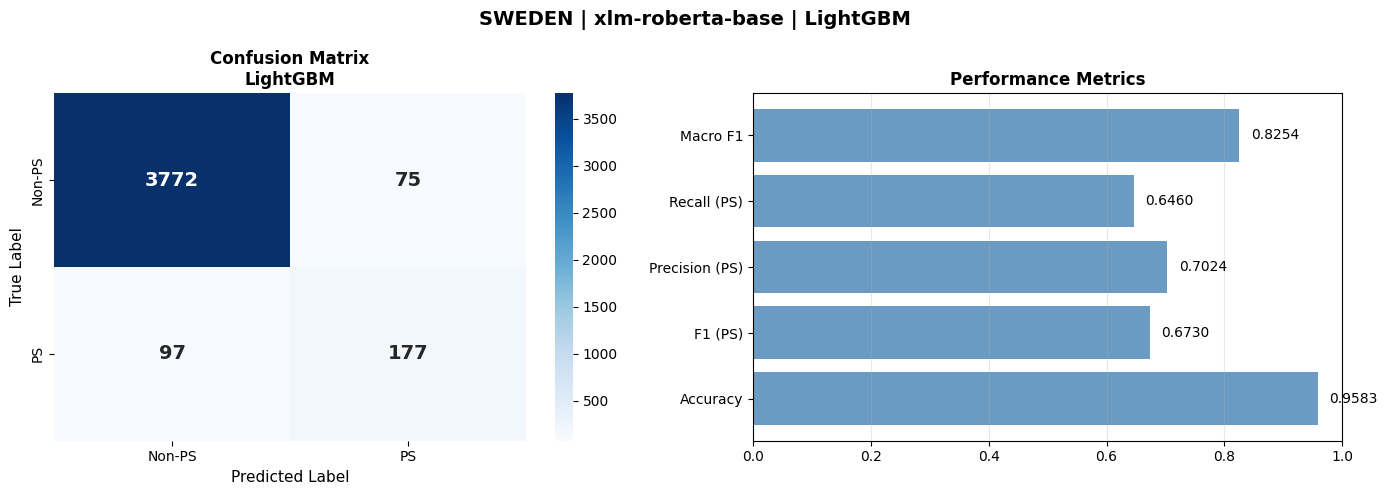


################################################################################
Loading: english_intfloat_multilingual-e5-large-instruct_embeddings.pkl
################################################################################
Dataset: ENGLISH
Model: intfloat/multilingual-e5-large-instruct
Training samples: 6621
Test samples: 1422
Embedding dim: 1024

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: ENGLISH | intfloat/multilingual-e5-large-instruct | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      832                143
Actual: PS                          105                342
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric     

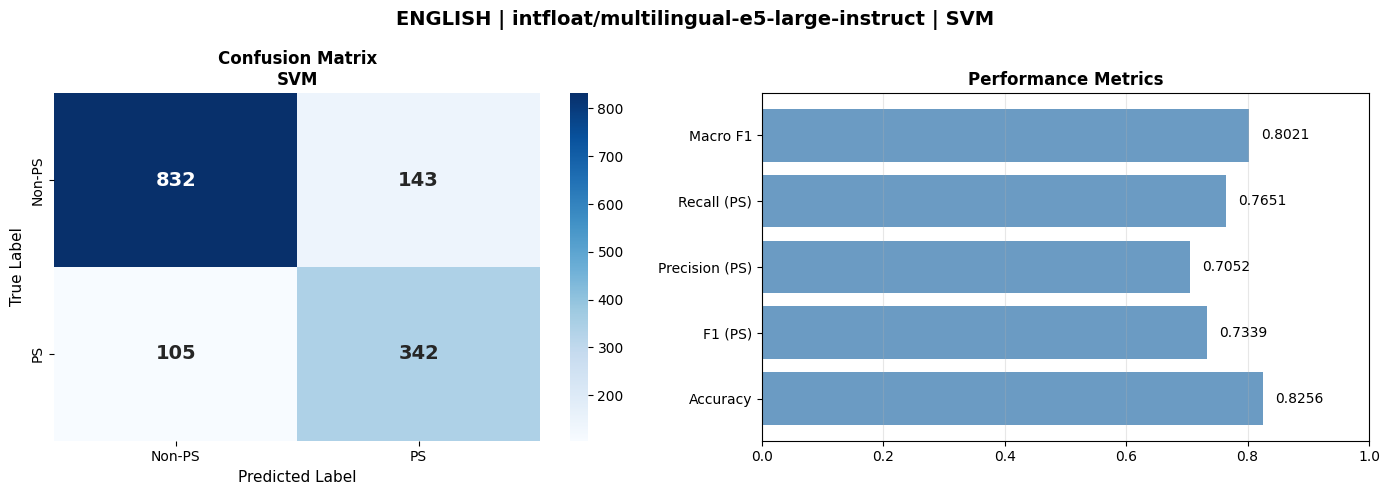


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: ENGLISH | intfloat/multilingual-e5-large-instruct | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      936                 39
Actual: PS                          103                344
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9009          0.8982       0.8995
Recall                     0.9600          0.7696       0.8648
F1-Score                   0.9295          0.8289       0.8792
---------------------------------------

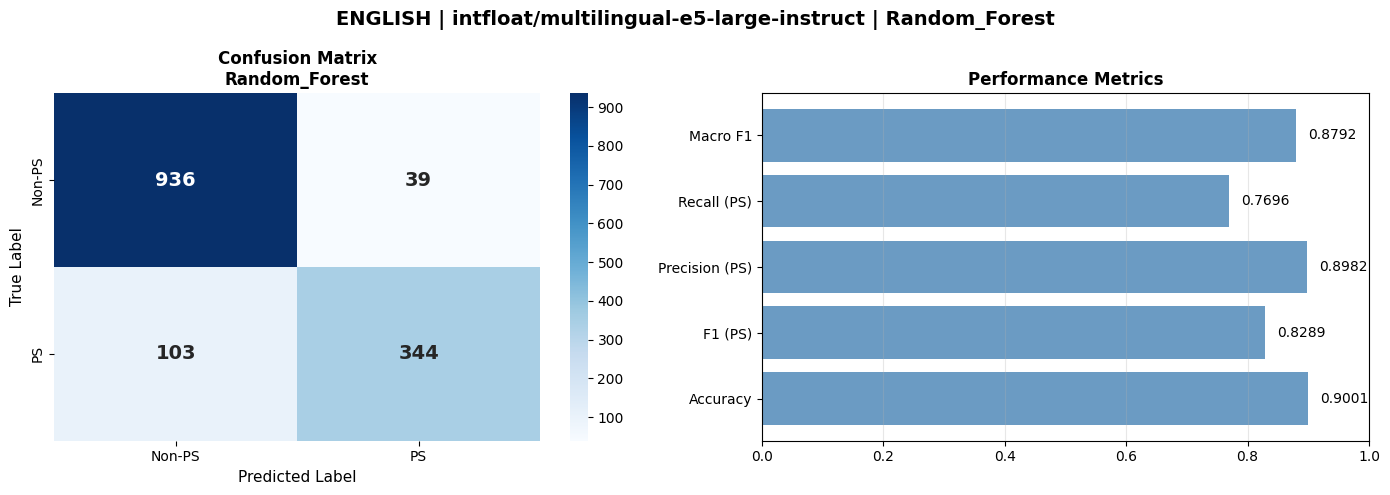


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: ENGLISH | intfloat/multilingual-e5-large-instruct | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      931                 44
Actual: PS                           84                363
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9172          0.8919       0.9046
Recall                     0.9549          0.8121       0.8835
F1-Score                   0.9357          0.8501       0.8929
---------------------------------------------------

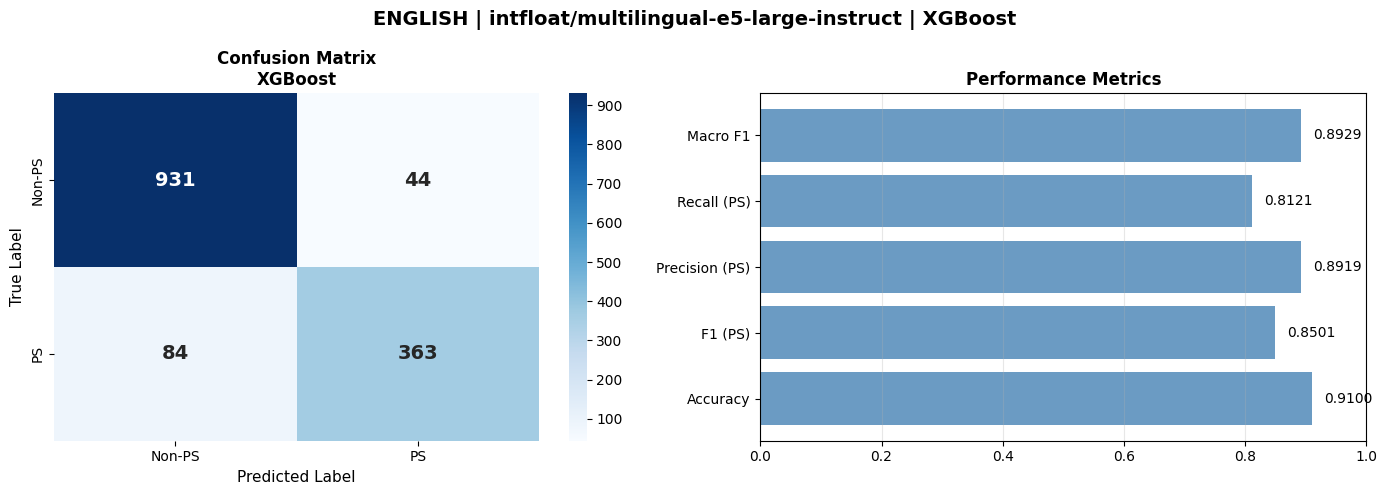


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: ENGLISH | intfloat/multilingual-e5-large-instruct | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      927                 48
Actual: PS                           80                367
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9206          0.8843       0.9024
Recall                     0.9508          0.8210       0.8859
F1-Score                   0.9354          0.8515       0.8935
-------------------------------------------------

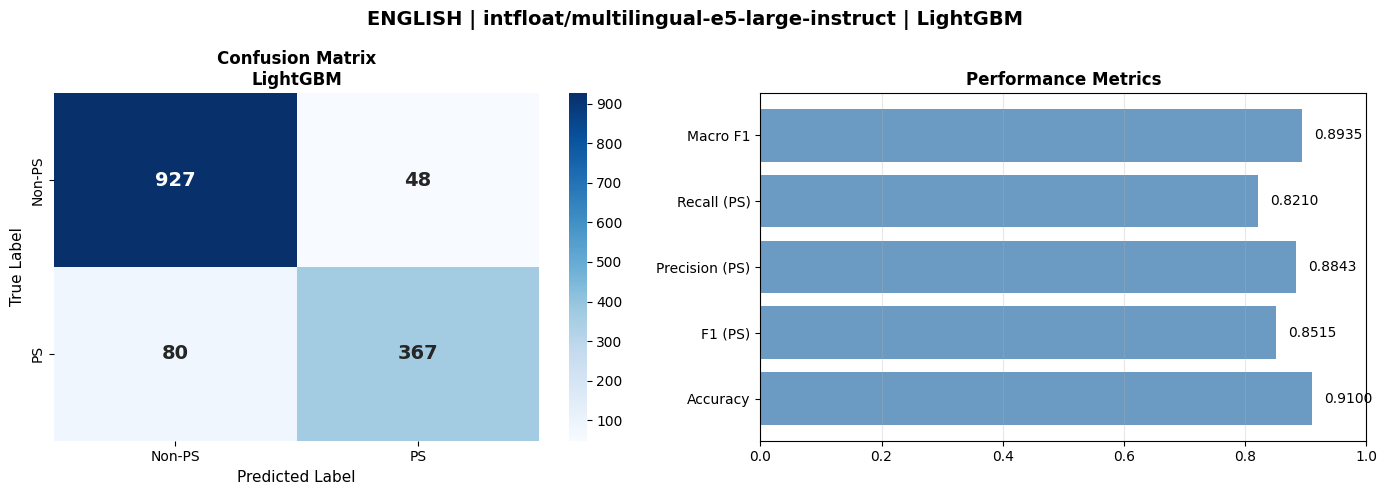


################################################################################
Loading: netherlands_intfloat_multilingual-e5-large-instruct_embeddings.pkl
################################################################################
Dataset: NETHERLANDS
Model: intfloat/multilingual-e5-large-instruct
Training samples: 3005
Test samples: 638
Embedding dim: 1024

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: NETHERLANDS | intfloat/multilingual-e5-large-instruct | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      392                 51
Actual: PS                           38                157
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------


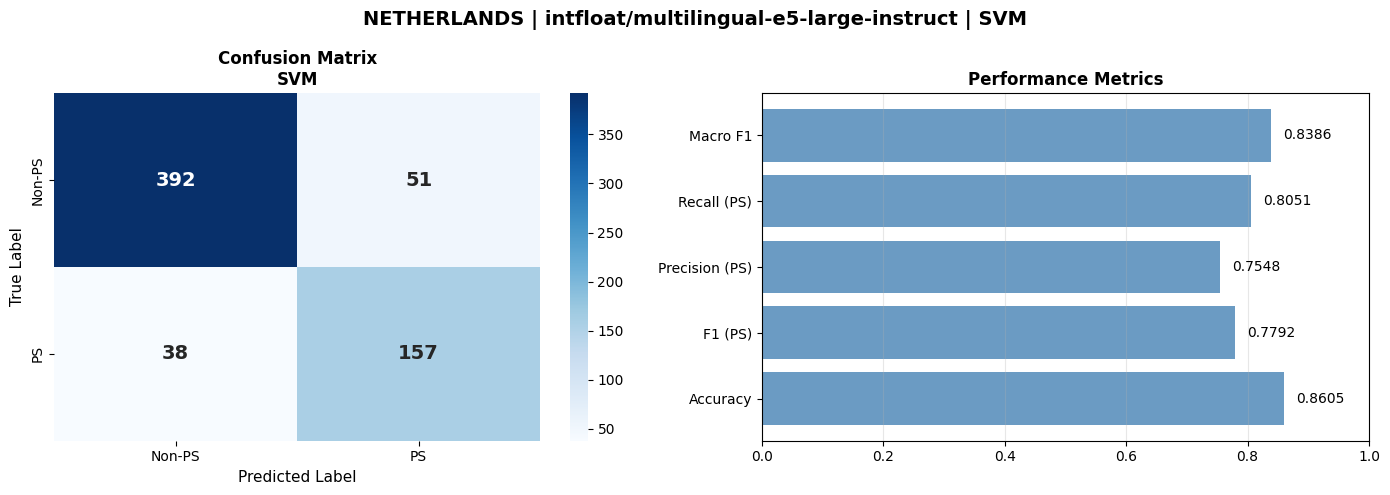


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: NETHERLANDS | intfloat/multilingual-e5-large-instruct | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      408                 35
Actual: PS                           52                143
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.8870          0.8034       0.8452
Recall                     0.9210          0.7333       0.8272
F1-Score                   0.9037          0.7668       0.8352
-----------------------------------

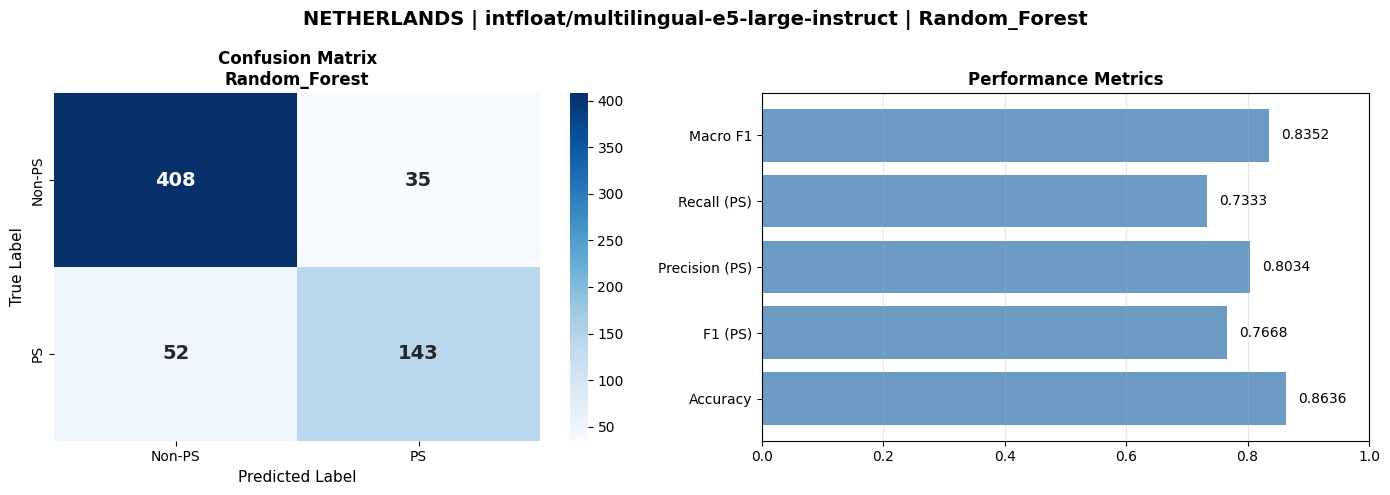


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: NETHERLANDS | intfloat/multilingual-e5-large-instruct | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      398                 45
Actual: PS                           34                161
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9213          0.7816       0.8514
Recall                     0.8984          0.8256       0.8620
F1-Score                   0.9097          0.8030       0.8564
-----------------------------------------------

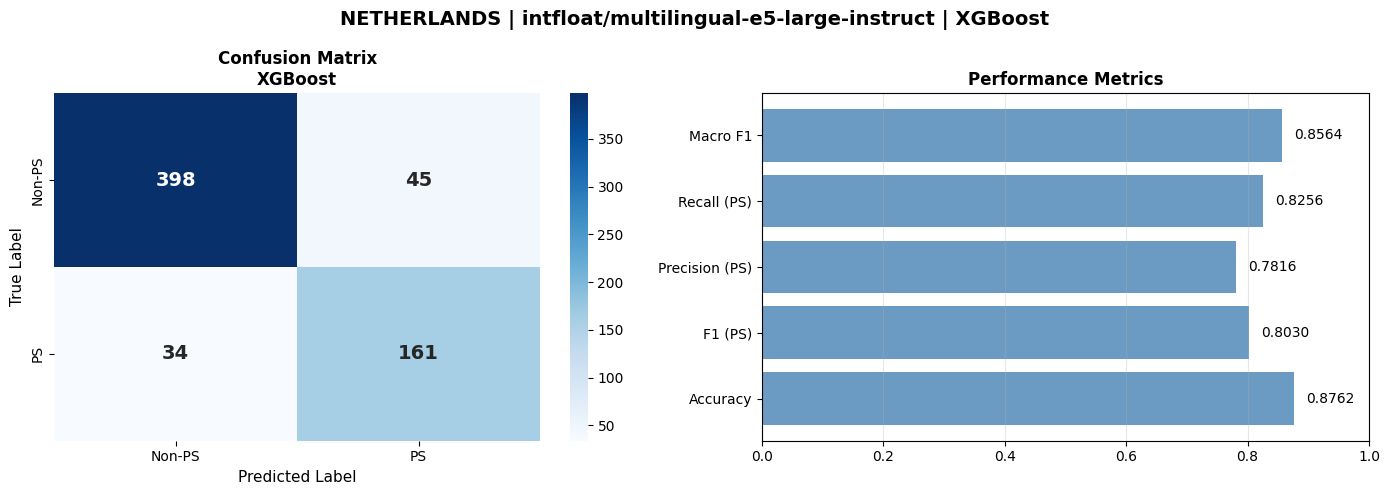


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: NETHERLANDS | intfloat/multilingual-e5-large-instruct | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      398                 45
Actual: PS                           31                164
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9277          0.7847       0.8562
Recall                     0.8984          0.8410       0.8697
F1-Score                   0.9128          0.8119       0.8624
---------------------------------------------

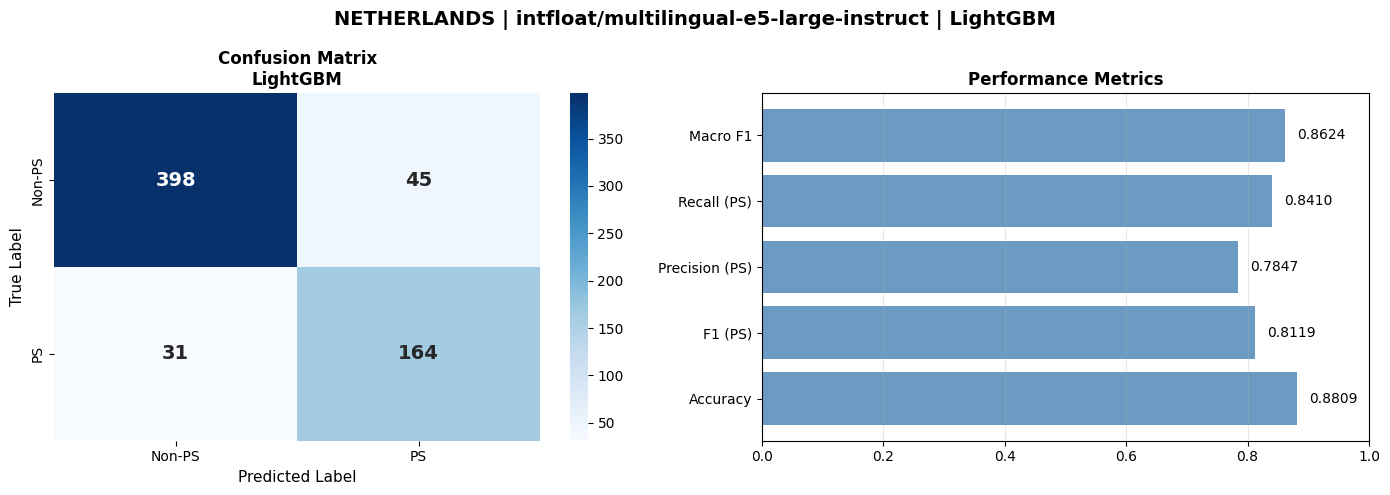


################################################################################
Loading: germany_intfloat_multilingual-e5-large-instruct_embeddings.pkl
################################################################################
Dataset: GERMANY
Model: intfloat/multilingual-e5-large-instruct
Training samples: 27356
Test samples: 4568
Embedding dim: 1024

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: GERMANY | intfloat/multilingual-e5-large-instruct | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,412                611
Actual: PS                          148                397
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric    

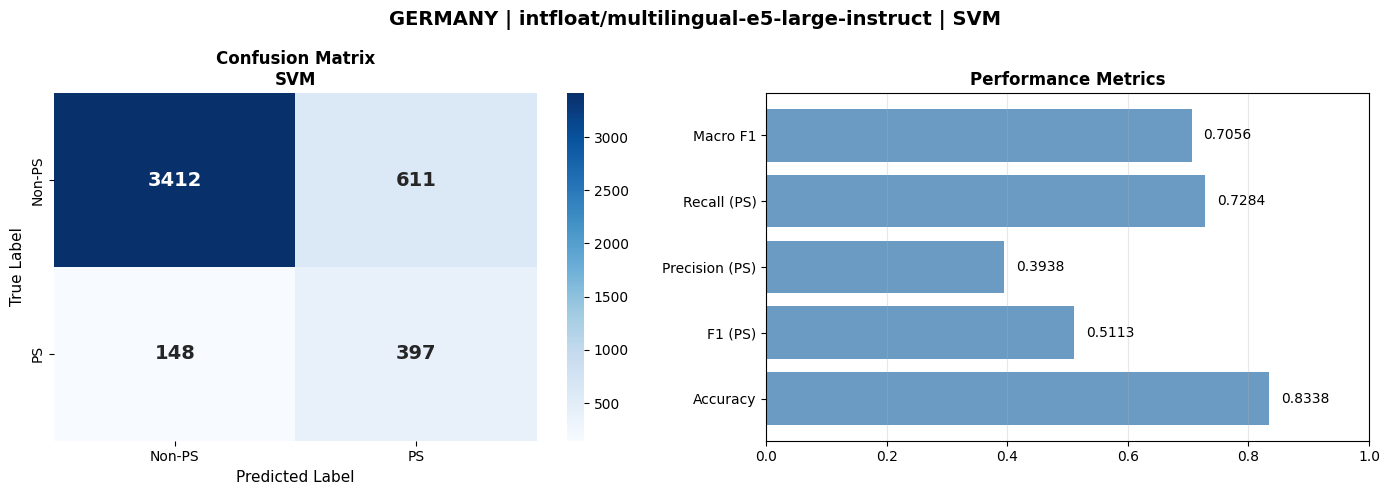


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: GERMANY | intfloat/multilingual-e5-large-instruct | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,963                 60
Actual: PS                          121                424
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9704          0.8760       0.9232
Recall                     0.9851          0.7780       0.8815
F1-Score                   0.9777          0.8241       0.9009
---------------------------------------

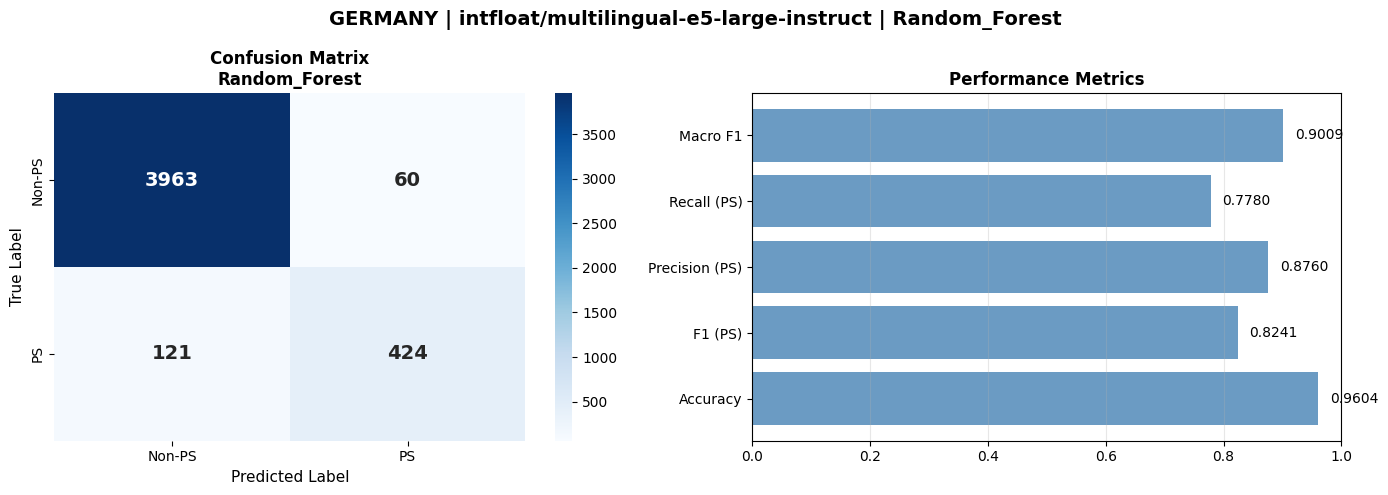


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: GERMANY | intfloat/multilingual-e5-large-instruct | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,933                 90
Actual: PS                          106                439
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9738          0.8299       0.9018
Recall                     0.9776          0.8055       0.8916
F1-Score                   0.9757          0.8175       0.8966
---------------------------------------------------

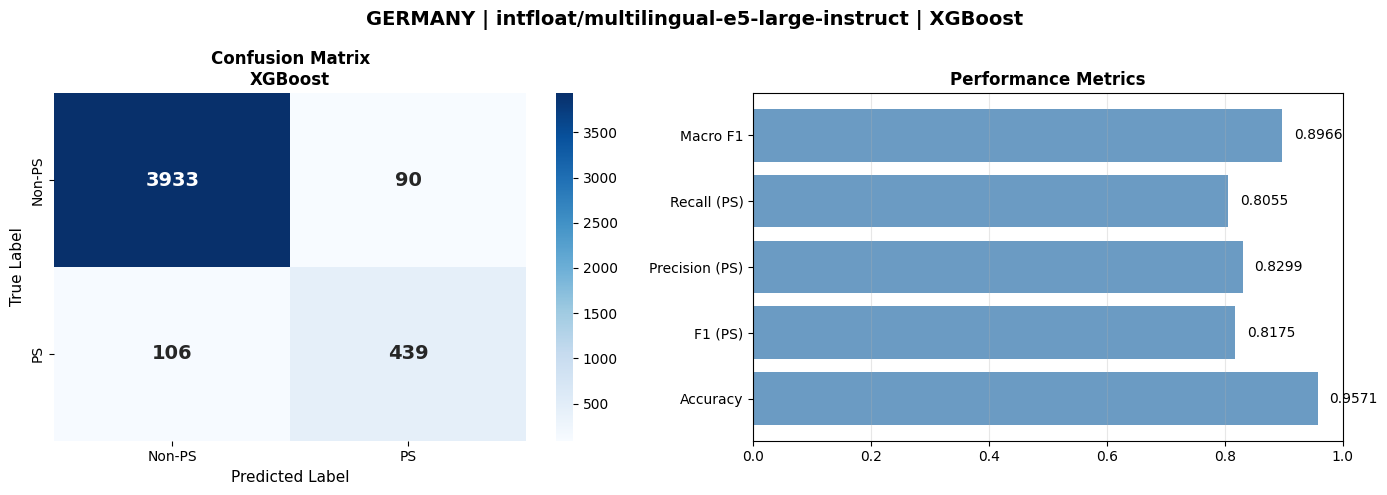


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: GERMANY | intfloat/multilingual-e5-large-instruct | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,938                 85
Actual: PS                          111                434
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9726          0.8362       0.9044
Recall                     0.9789          0.7963       0.8876
F1-Score                   0.9757          0.8158       0.8958
-------------------------------------------------

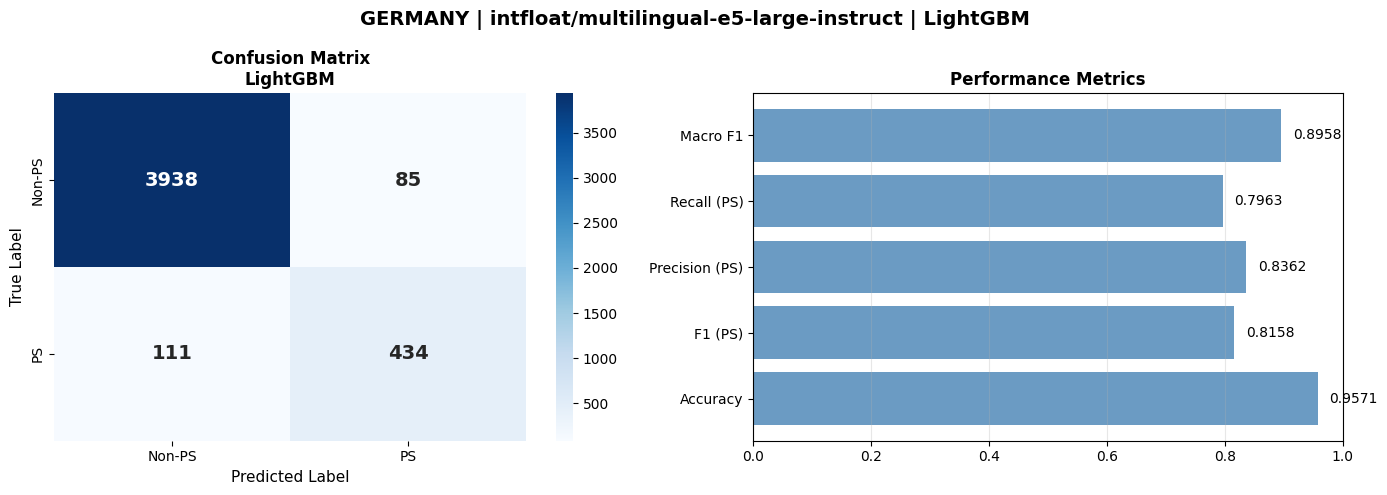


################################################################################
Loading: uk_intfloat_multilingual-e5-large-instruct_embeddings.pkl
################################################################################
Dataset: UK
Model: intfloat/multilingual-e5-large-instruct
Training samples: 6582
Test samples: 1407
Embedding dim: 1024

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: UK | intfloat/multilingual-e5-large-instruct | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      824                145
Actual: PS                           98                340
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                    

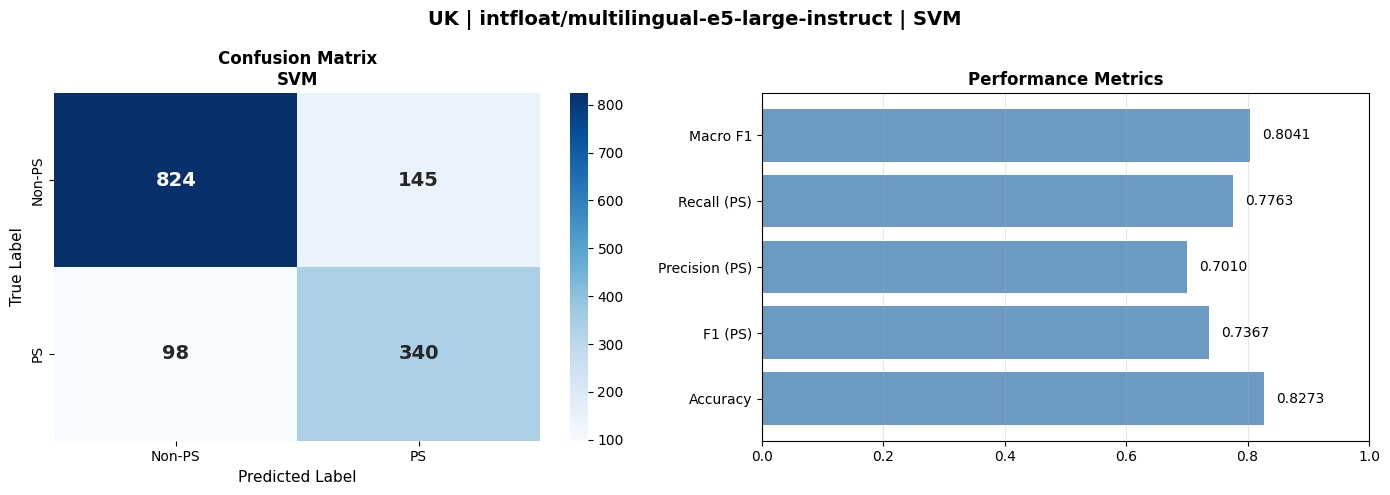


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: UK | intfloat/multilingual-e5-large-instruct | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      911                 58
Actual: PS                           81                357
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9183          0.8602       0.8893
Recall                     0.9401          0.8151       0.8776
F1-Score                   0.9291          0.8370       0.8831
--------------------------------------------

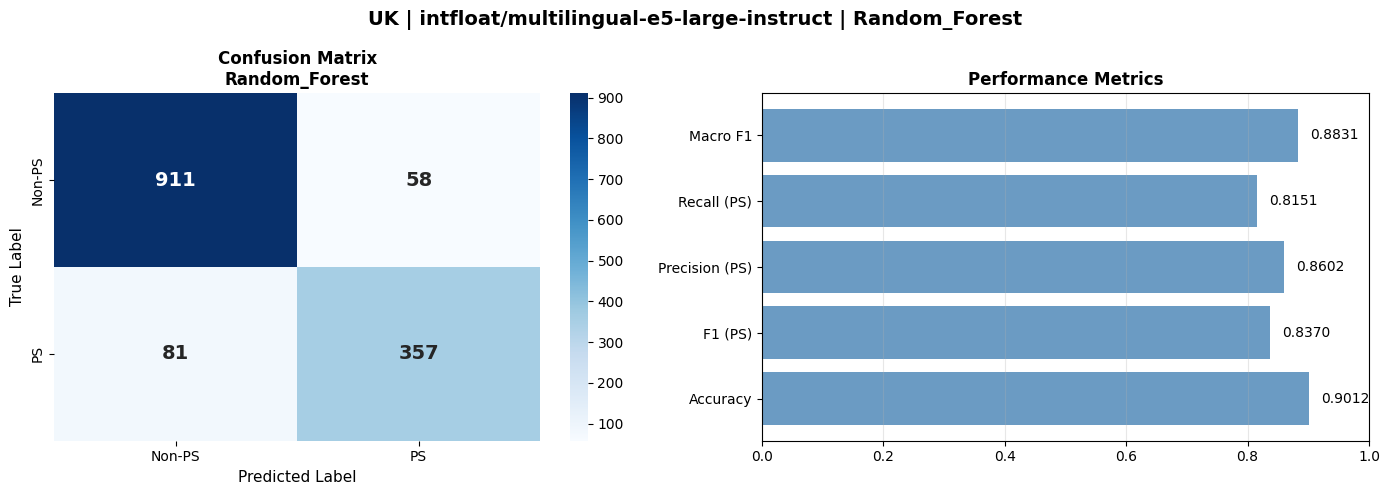


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: UK | intfloat/multilingual-e5-large-instruct | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      908                 61
Actual: PS                           69                369
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9294          0.8581       0.8938
Recall                     0.9370          0.8425       0.8898
F1-Score                   0.9332          0.8502       0.8917
--------------------------------------------------------

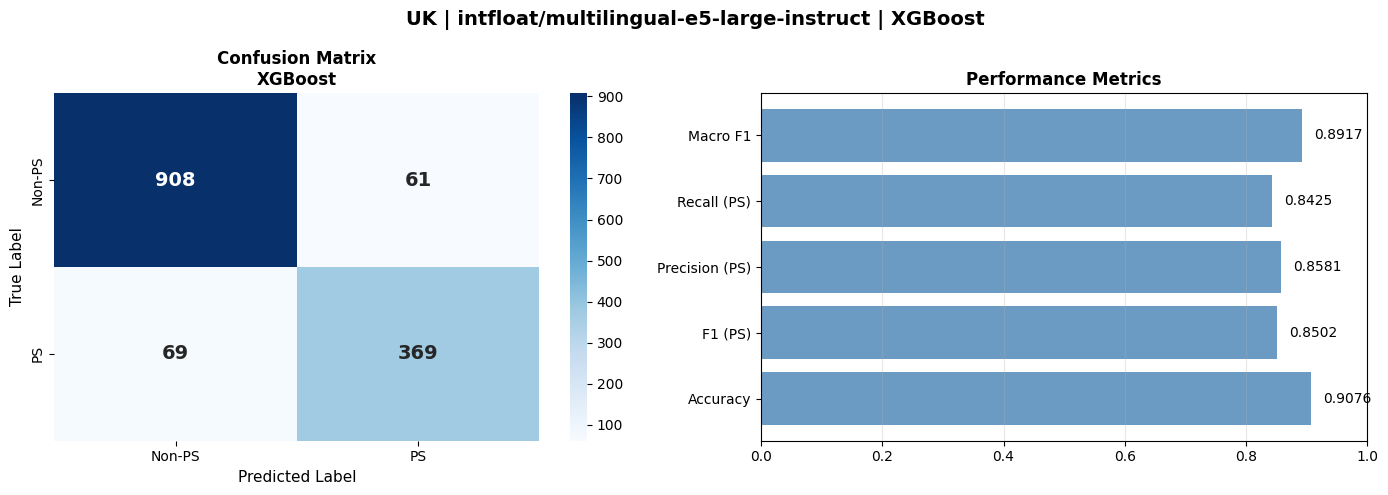


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: UK | intfloat/multilingual-e5-large-instruct | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      912                 57
Actual: PS                           79                359
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9203          0.8630       0.8916
Recall                     0.9412          0.8196       0.8804
F1-Score                   0.9306          0.8407       0.8857
------------------------------------------------------

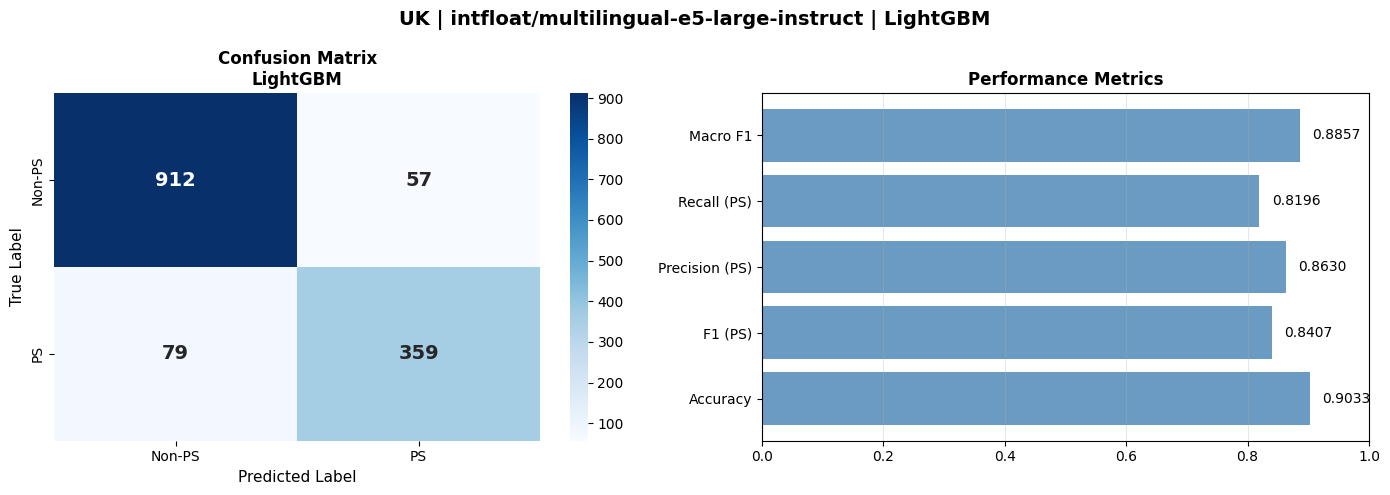


################################################################################
Loading: sweden_intfloat_multilingual-e5-large-instruct_embeddings.pkl
################################################################################
Dataset: SWEDEN
Model: intfloat/multilingual-e5-large-instruct
Training samples: 26161
Test samples: 4121
Embedding dim: 1024

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: SWEDEN | intfloat/multilingual-e5-large-instruct | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,345                502
Actual: PS                           86                188
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric       

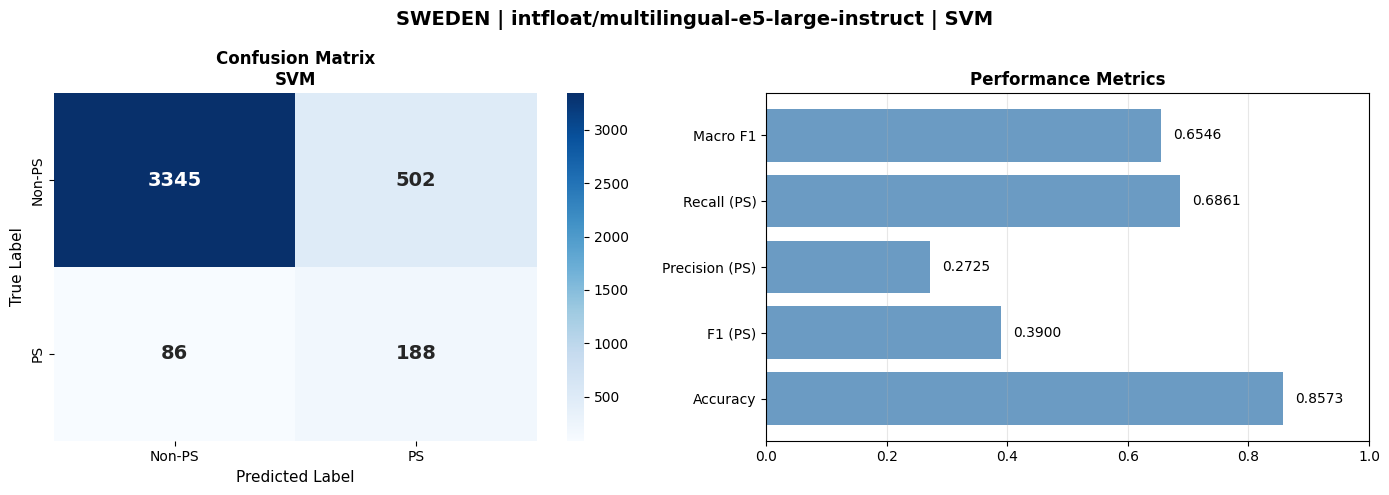


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: SWEDEN | intfloat/multilingual-e5-large-instruct | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,765                 82
Actual: PS                           95                179
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9754          0.6858       0.8306
Recall                     0.9787          0.6533       0.8160
F1-Score                   0.9770          0.6692       0.8231
----------------------------------------

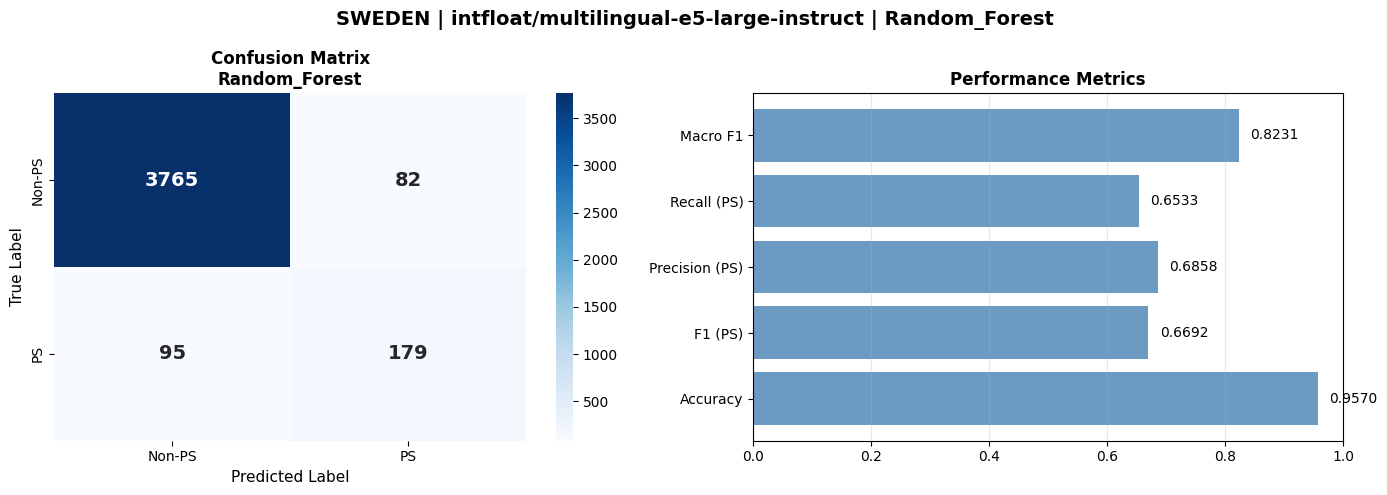


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: SWEDEN | intfloat/multilingual-e5-large-instruct | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,778                 69
Actual: PS                           97                177
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9750          0.7195       0.8472
Recall                     0.9821          0.6460       0.8140
F1-Score                   0.9785          0.6808       0.8296
----------------------------------------------------

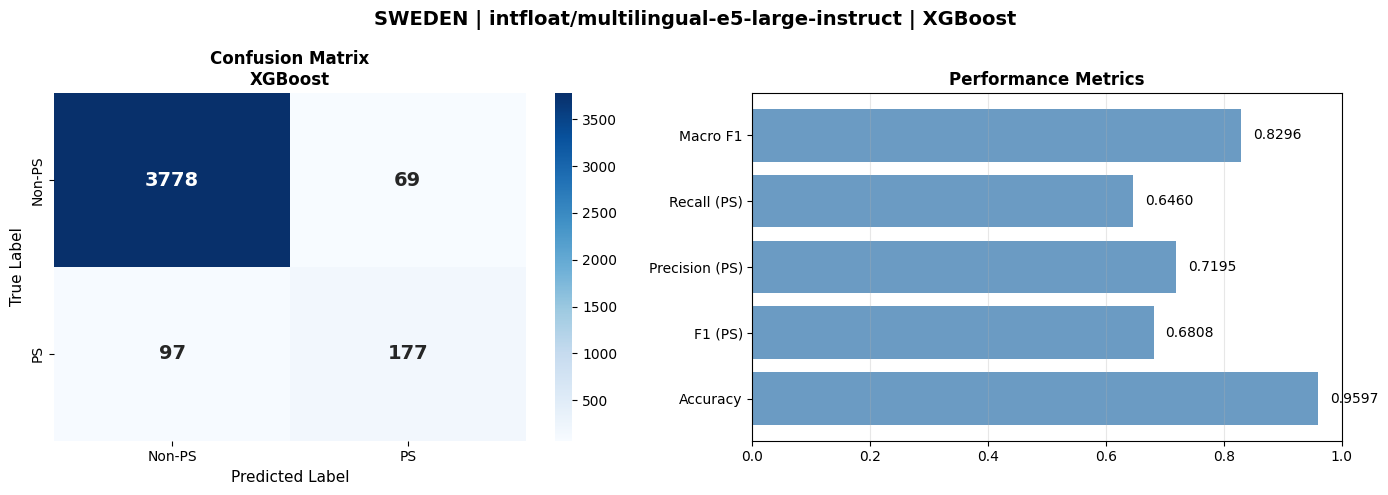


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: SWEDEN | intfloat/multilingual-e5-large-instruct | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,767                 80
Actual: PS                           91                183
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9764          0.6958       0.8361
Recall                     0.9792          0.6679       0.8235
F1-Score                   0.9778          0.6816       0.8297
--------------------------------------------------

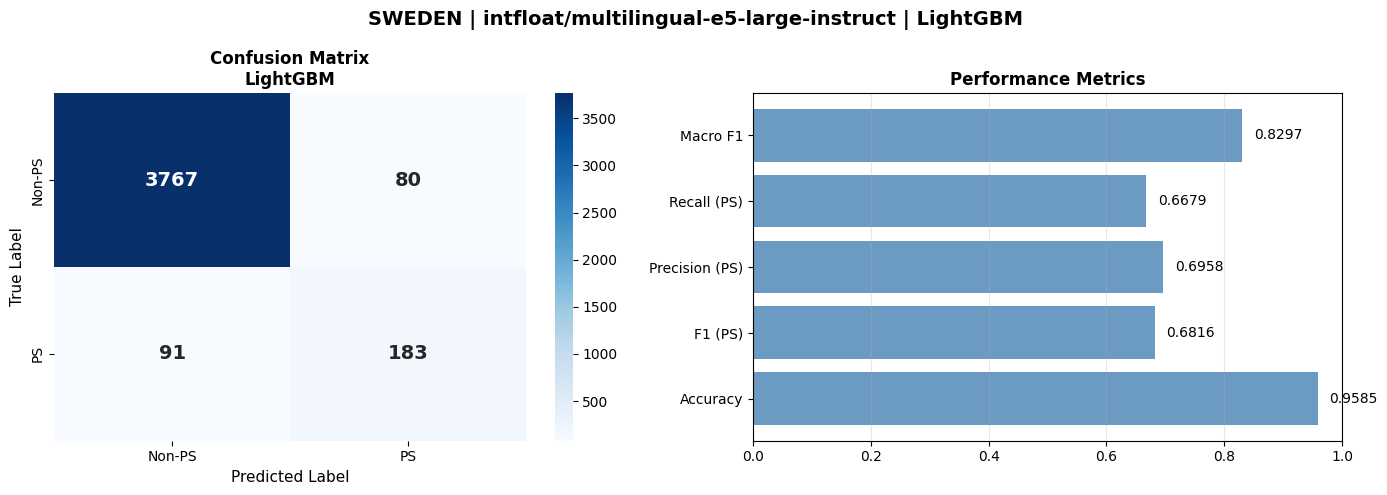


################################################################################
Loading: uk_paraphrase-multilingual-MiniLM-L12-v2_embeddings.pkl
################################################################################
Dataset: UK
Model: paraphrase-multilingual-MiniLM-L12-v2
Training samples: 6582
Test samples: 1407
Embedding dim: 384

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: UK | paraphrase-multilingual-MiniLM-L12-v2 | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      778                191
Actual: PS                           94                344
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS

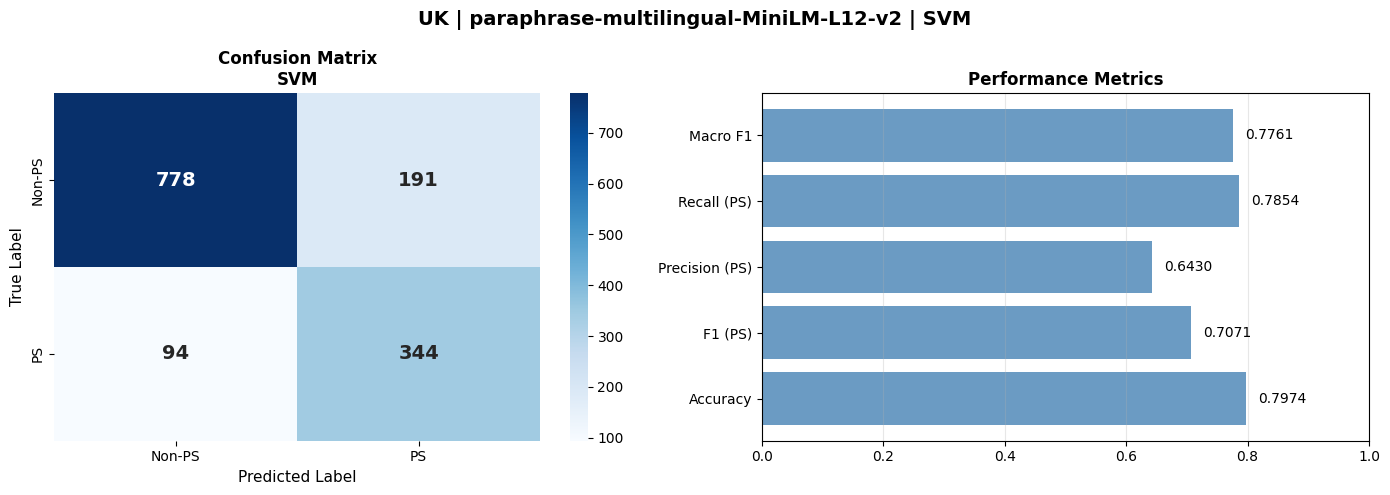


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: UK | paraphrase-multilingual-MiniLM-L12-v2 | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      908                 61
Actual: PS                           96                342
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9044          0.8486       0.8765
Recall                     0.9370          0.7808       0.8589
F1-Score                   0.9204          0.8133       0.8669
----------------------------------------------

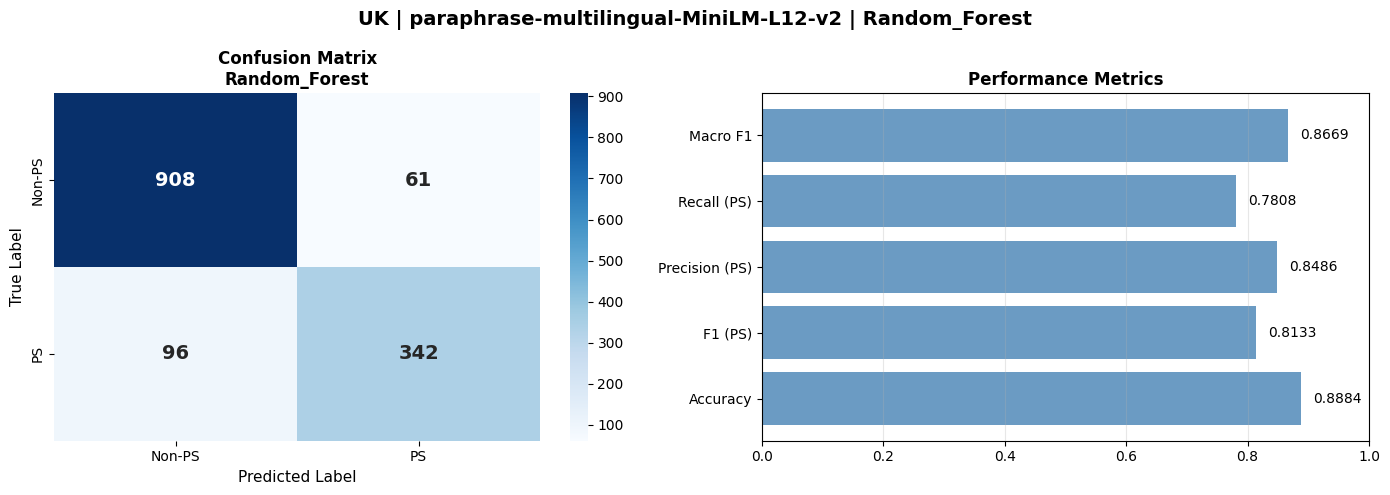


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: UK | paraphrase-multilingual-MiniLM-L12-v2 | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      901                 68
Actual: PS                           85                353
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9138          0.8385       0.8761
Recall                     0.9298          0.8059       0.8679
F1-Score                   0.9217          0.8219       0.8718
----------------------------------------------------------

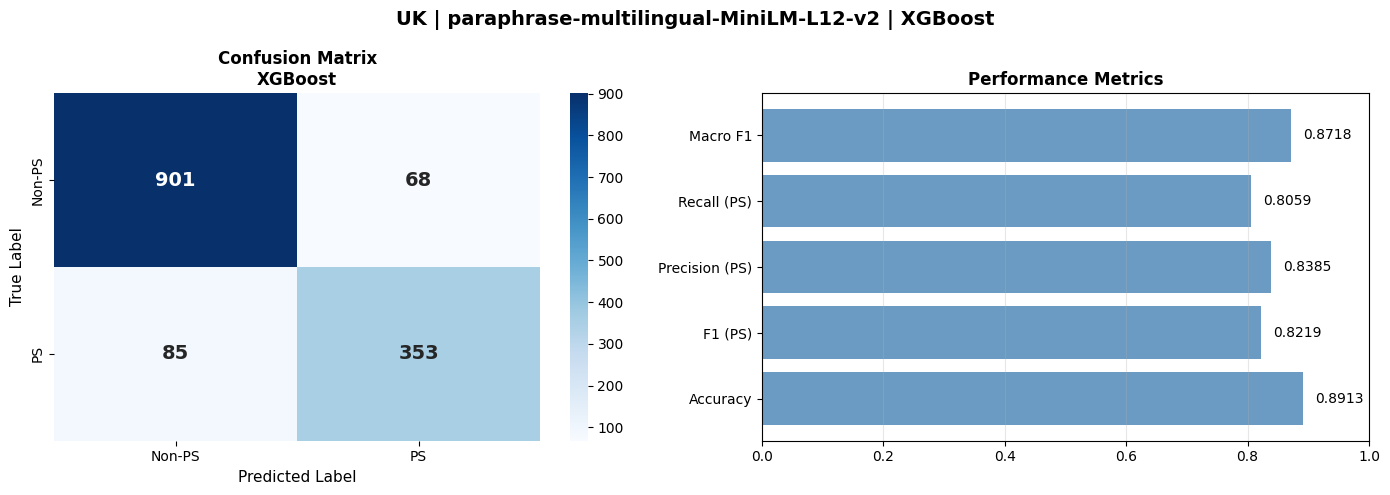


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: UK | paraphrase-multilingual-MiniLM-L12-v2 | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      897                 72
Actual: PS                           76                362
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9219          0.8341       0.8780
Recall                     0.9257          0.8265       0.8761
F1-Score                   0.9238          0.8303       0.8770
--------------------------------------------------------

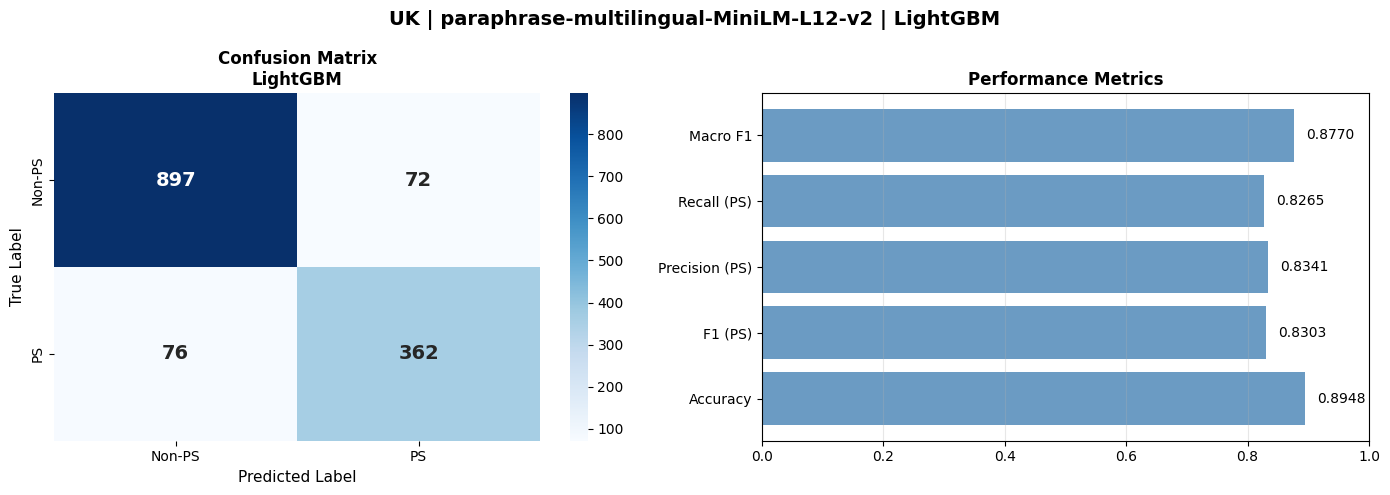


################################################################################
Loading: germany_paraphrase-multilingual-MiniLM-L12-v2_embeddings.pkl
################################################################################
Dataset: GERMANY
Model: paraphrase-multilingual-MiniLM-L12-v2
Training samples: 27356
Test samples: 4568
Embedding dim: 384

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: GERMANY | paraphrase-multilingual-MiniLM-L12-v2 | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,109                914
Actual: PS                          185                360
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric           

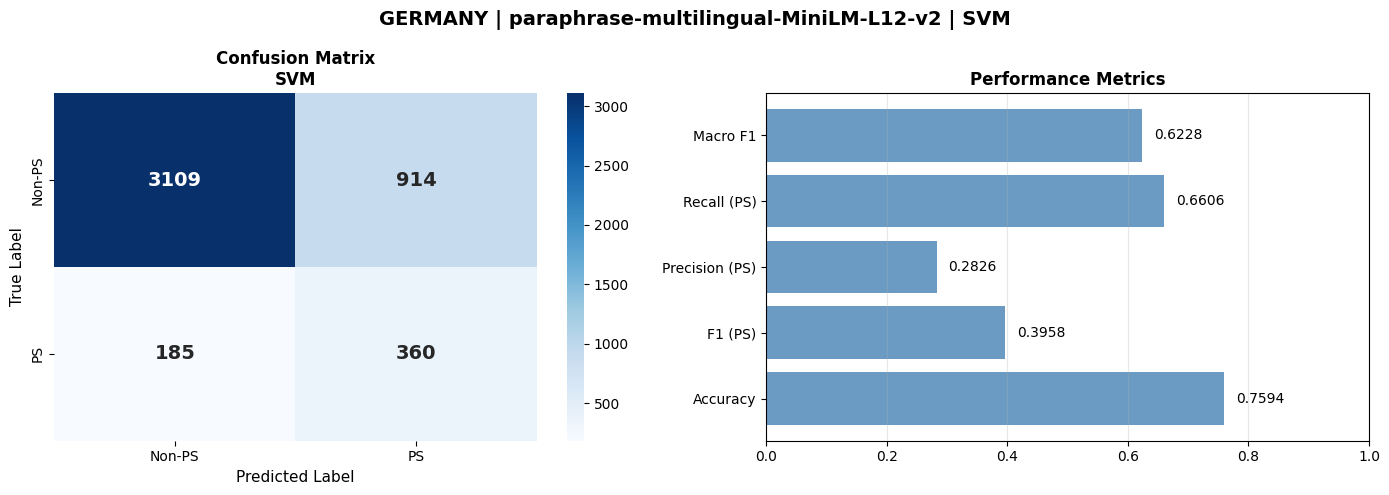


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: GERMANY | paraphrase-multilingual-MiniLM-L12-v2 | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,926                 97
Actual: PS                          138                407
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9660          0.8075       0.8868
Recall                     0.9759          0.7468       0.8613
F1-Score                   0.9709          0.7760       0.8735
-----------------------------------------

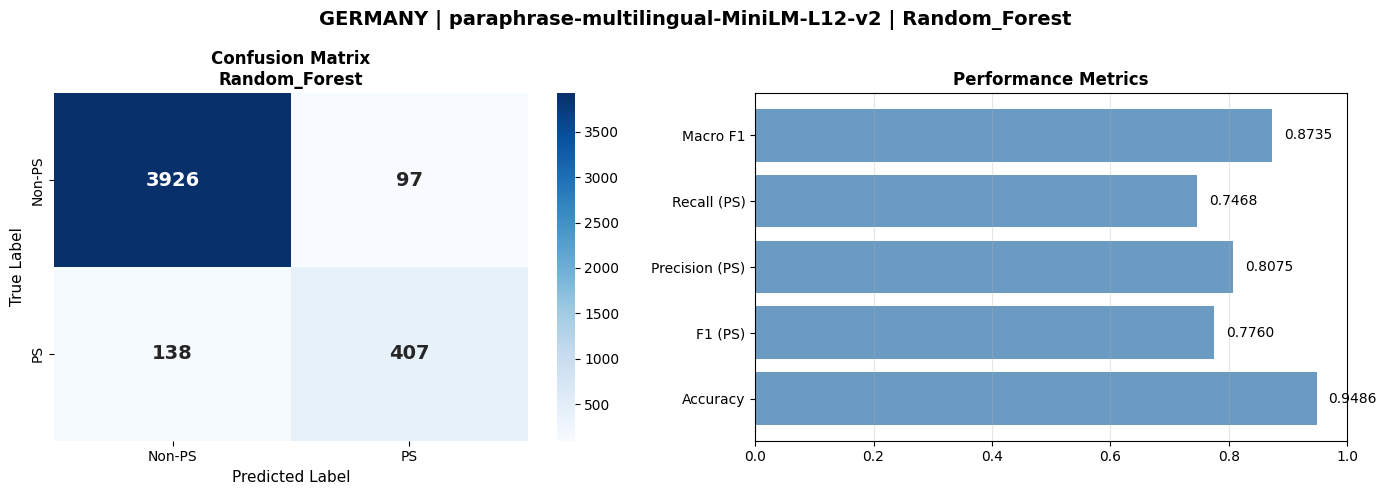


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: GERMANY | paraphrase-multilingual-MiniLM-L12-v2 | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,894                129
Actual: PS                          118                427
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9706          0.7680       0.8693
Recall                     0.9679          0.7835       0.8757
F1-Score                   0.9693          0.7757       0.8725
-----------------------------------------------------

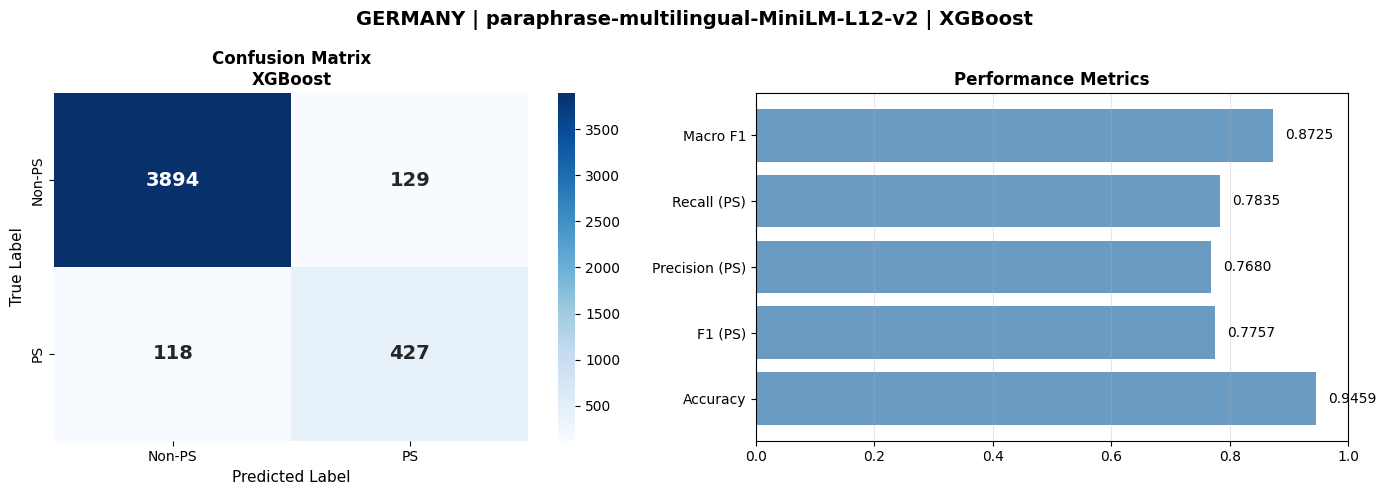


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: GERMANY | paraphrase-multilingual-MiniLM-L12-v2 | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,836                187
Actual: PS                          124                421
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9687          0.6924       0.8306
Recall                     0.9535          0.7725       0.8630
F1-Score                   0.9610          0.7303       0.8457
---------------------------------------------------

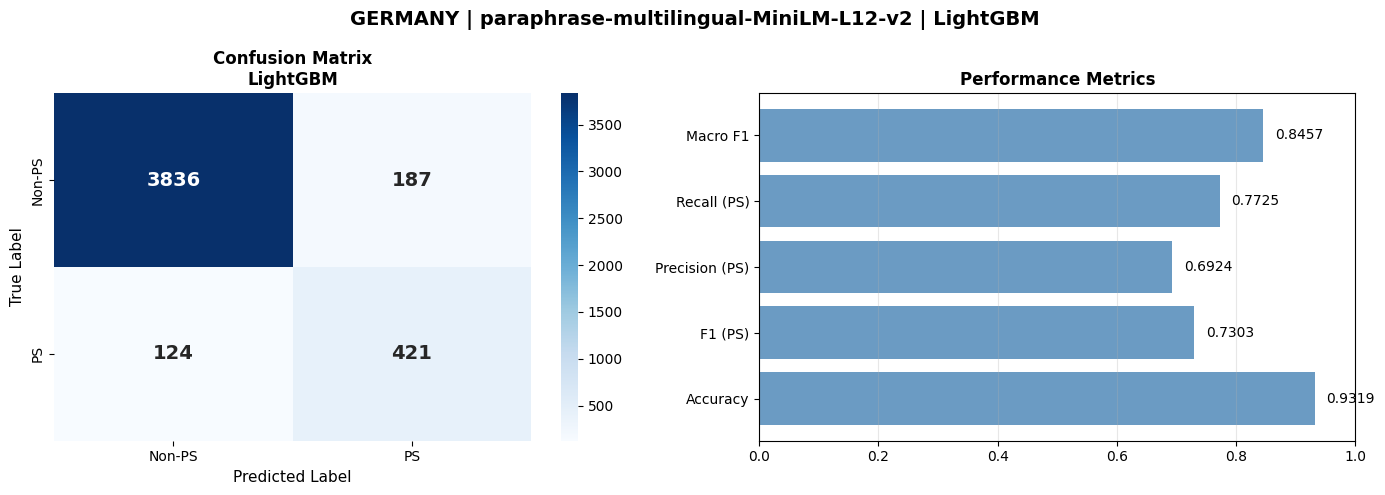


################################################################################
Loading: netherlands_paraphrase-multilingual-MiniLM-L12-v2_embeddings.pkl
################################################################################
Dataset: NETHERLANDS
Model: paraphrase-multilingual-MiniLM-L12-v2
Training samples: 3005
Test samples: 638
Embedding dim: 384

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: NETHERLANDS | paraphrase-multilingual-MiniLM-L12-v2 | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      334                109
Actual: PS                           45                150
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric 

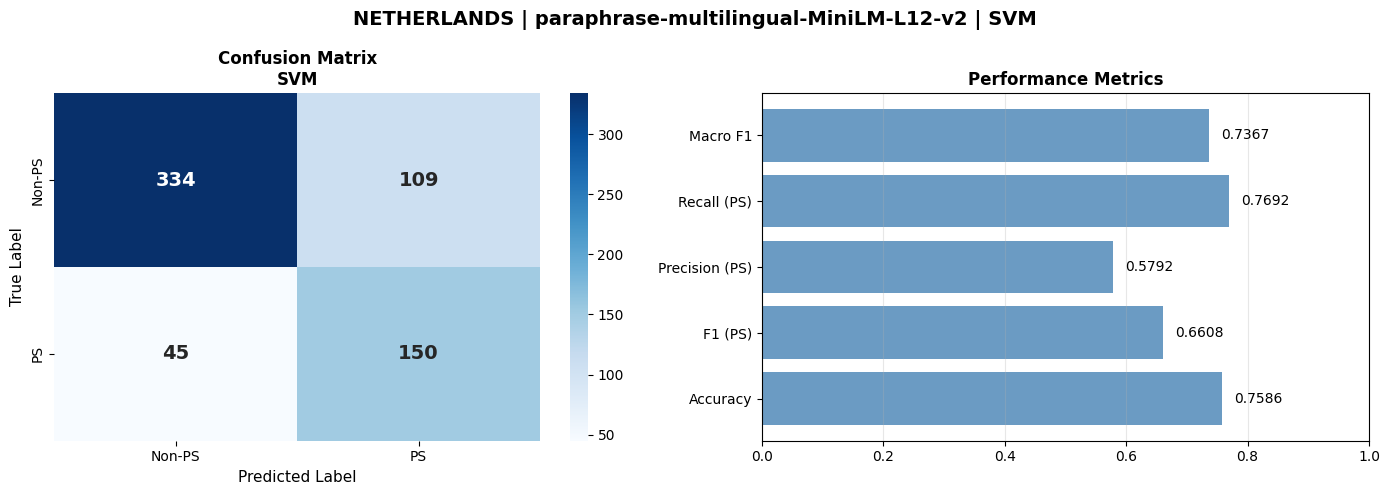


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: NETHERLANDS | paraphrase-multilingual-MiniLM-L12-v2 | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      406                 37
Actual: PS                           58                137
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.8750          0.7874       0.8312
Recall                     0.9165          0.7026       0.8095
F1-Score                   0.8953          0.7425       0.8189
-------------------------------------

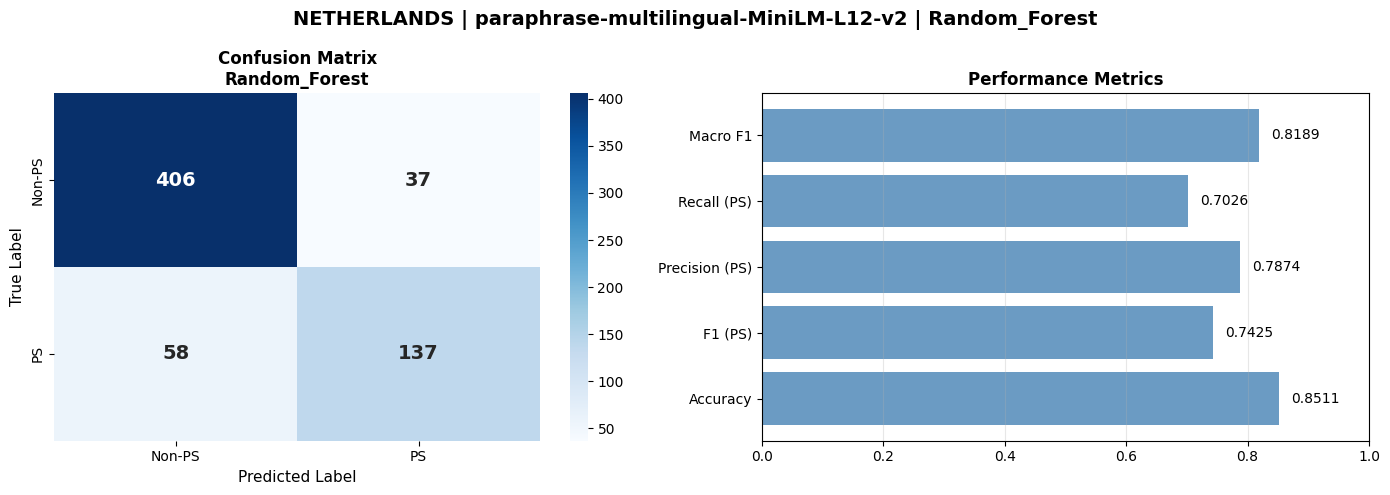


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: NETHERLANDS | paraphrase-multilingual-MiniLM-L12-v2 | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      403                 40
Actual: PS                           45                150
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.8996          0.7895       0.8445
Recall                     0.9097          0.7692       0.8395
F1-Score                   0.9046          0.7792       0.8419
-------------------------------------------------

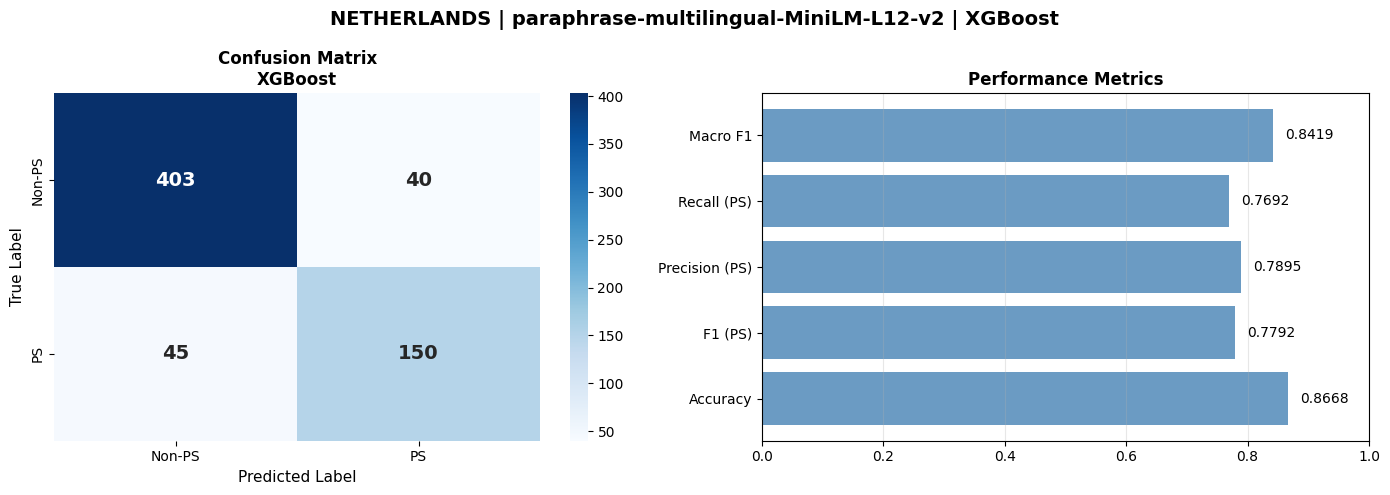


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: NETHERLANDS | paraphrase-multilingual-MiniLM-L12-v2 | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      401                 42
Actual: PS                           52                143
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.8852          0.7730       0.8291
Recall                     0.9052          0.7333       0.8193
F1-Score                   0.8951          0.7526       0.8239
-----------------------------------------------

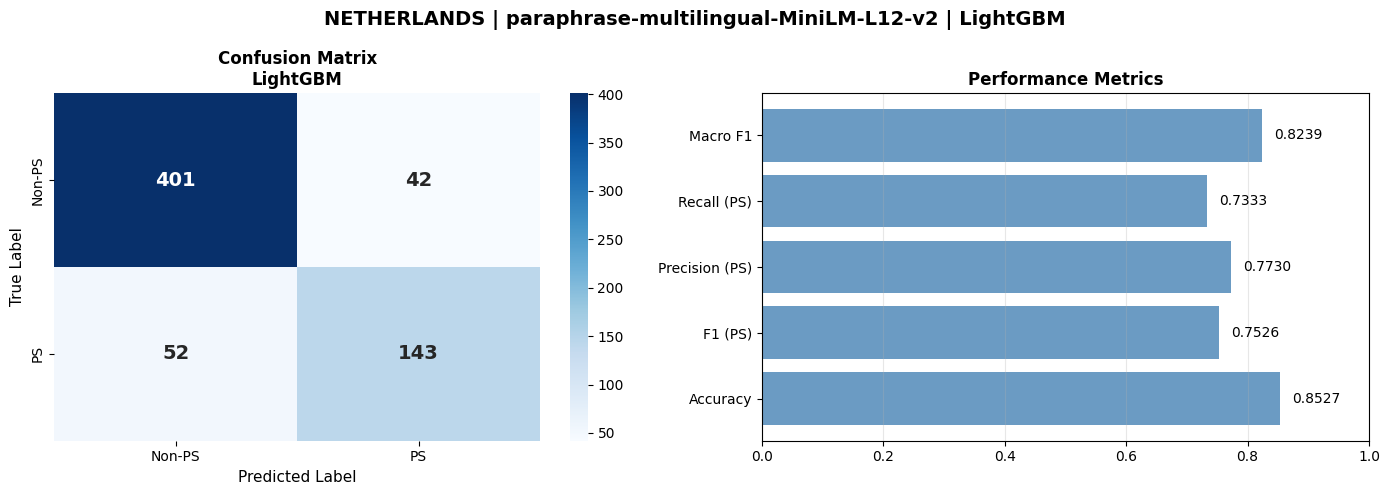


################################################################################
Loading: sweden_paraphrase-multilingual-MiniLM-L12-v2_embeddings.pkl
################################################################################
Dataset: SWEDEN
Model: paraphrase-multilingual-MiniLM-L12-v2
Training samples: 26161
Test samples: 4121
Embedding dim: 384

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: SWEDEN | paraphrase-multilingual-MiniLM-L12-v2 | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    2,959                888
Actual: PS                           78                196
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric              

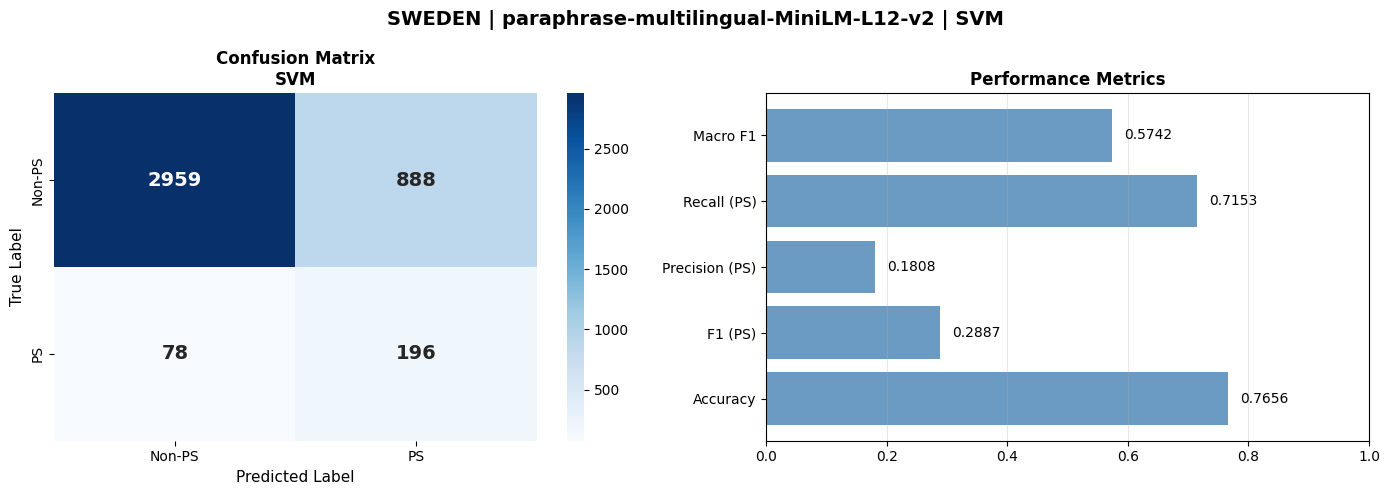


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: SWEDEN | paraphrase-multilingual-MiniLM-L12-v2 | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,721                126
Actual: PS                           84                190
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9779          0.6013       0.7896
Recall                     0.9672          0.6934       0.8303
F1-Score                   0.9726          0.6441       0.8083
------------------------------------------

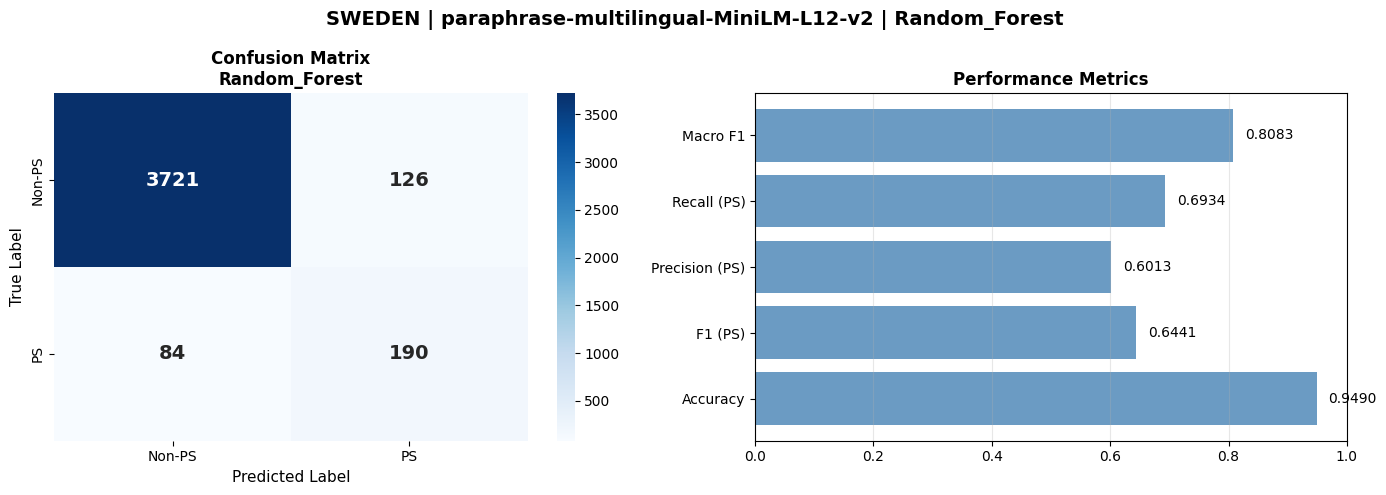


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: SWEDEN | paraphrase-multilingual-MiniLM-L12-v2 | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,753                 94
Actual: PS                           86                188
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9776          0.6667       0.8221
Recall                     0.9756          0.6861       0.8308
F1-Score                   0.9766          0.6763       0.8264
------------------------------------------------------

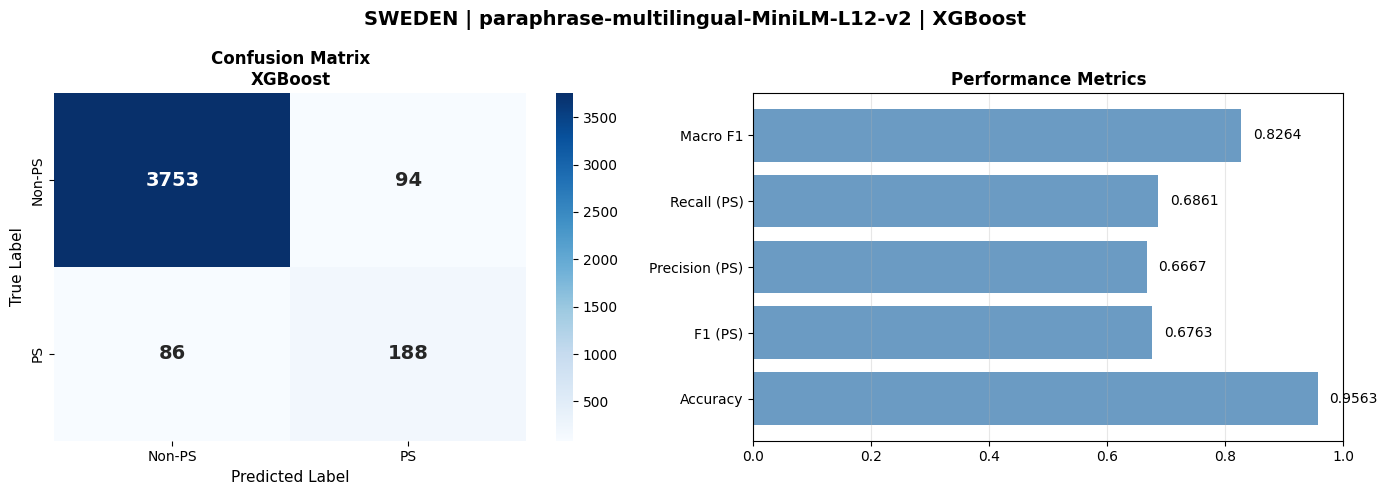


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: SWEDEN | paraphrase-multilingual-MiniLM-L12-v2 | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,735                112
Actual: PS                           80                194
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9790          0.6340       0.8065
Recall                     0.9709          0.7080       0.8395
F1-Score                   0.9749          0.6690       0.8220
----------------------------------------------------

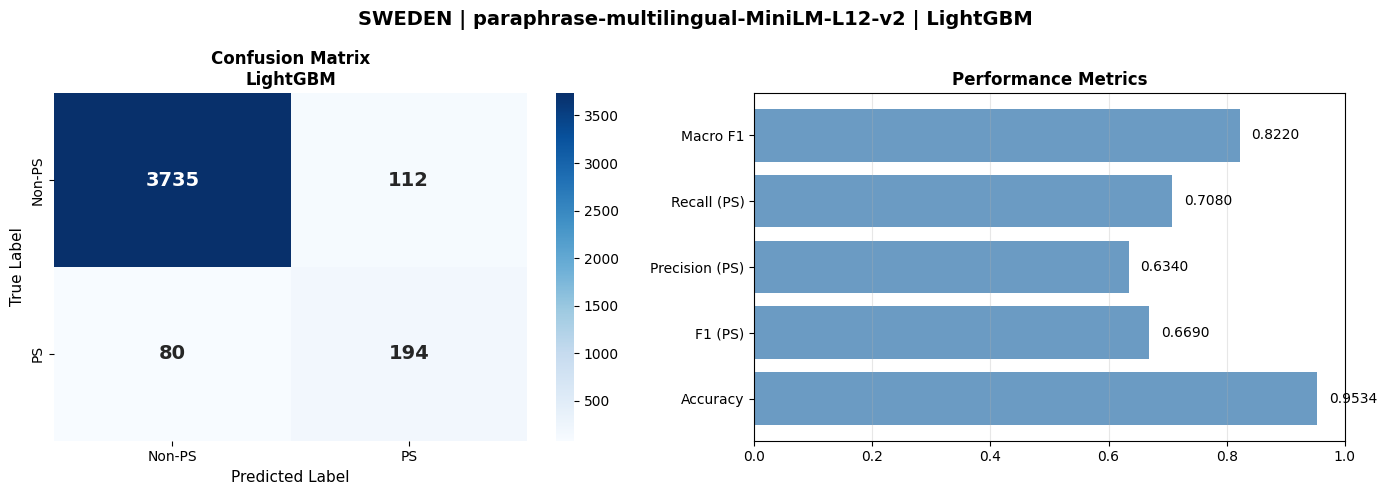


################################################################################
Loading: english_paraphrase-multilingual-MiniLM-L12-v2_embeddings.pkl
################################################################################
Dataset: ENGLISH
Model: paraphrase-multilingual-MiniLM-L12-v2
Training samples: 6621
Test samples: 1422
Embedding dim: 384

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: ENGLISH | paraphrase-multilingual-MiniLM-L12-v2 | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      784                191
Actual: PS                          107                340
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric            

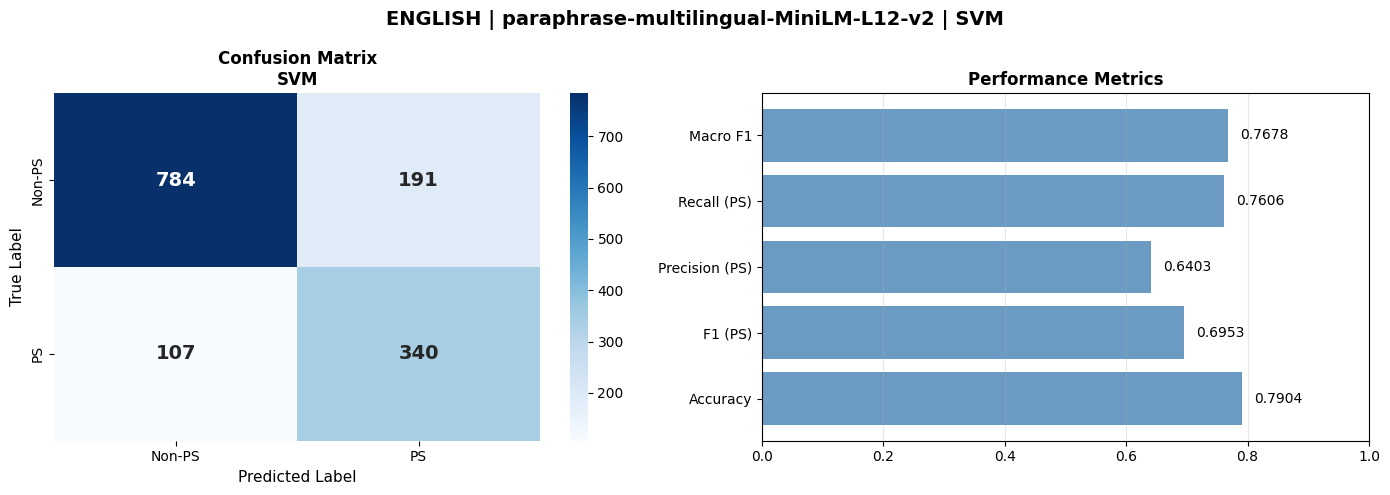


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: ENGLISH | paraphrase-multilingual-MiniLM-L12-v2 | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      931                 44
Actual: PS                           98                349
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9048          0.8880       0.8964
Recall                     0.9549          0.7808       0.8678
F1-Score                   0.9291          0.8310       0.8800
-----------------------------------------

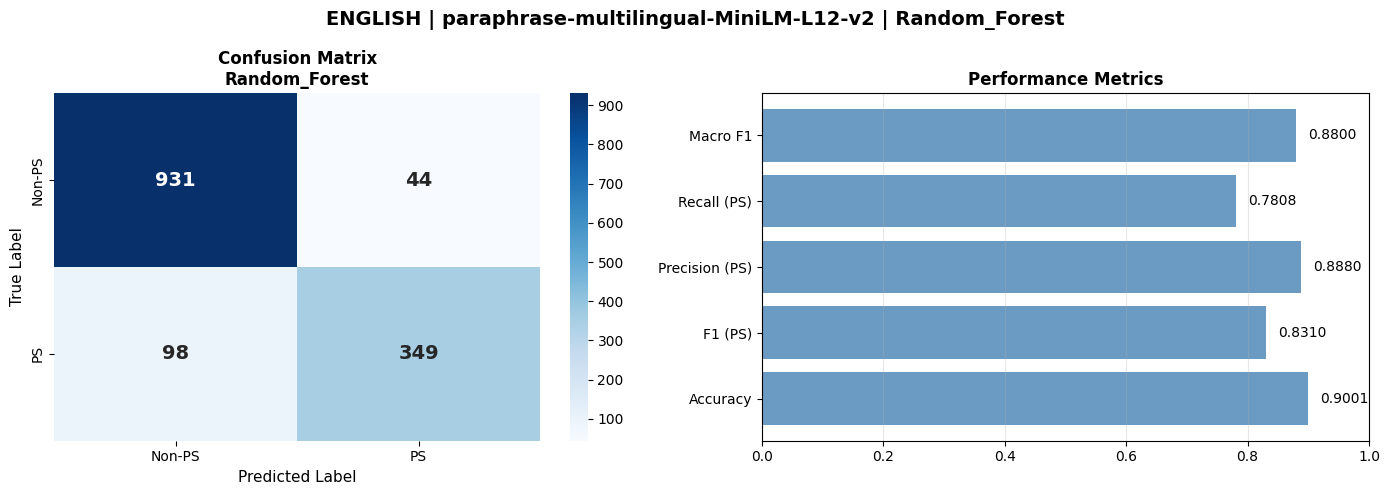


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: ENGLISH | paraphrase-multilingual-MiniLM-L12-v2 | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      912                 63
Actual: PS                           85                362
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9147          0.8518       0.8833
Recall                     0.9354          0.8098       0.8726
F1-Score                   0.9249          0.8303       0.8776
-----------------------------------------------------

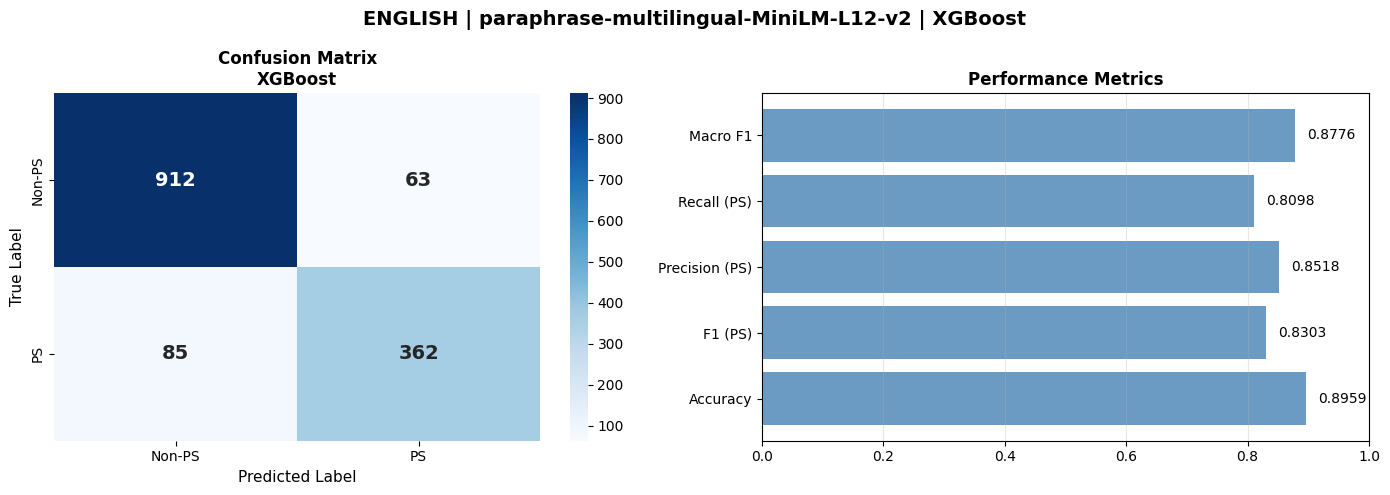


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: ENGLISH | paraphrase-multilingual-MiniLM-L12-v2 | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      916                 59
Actual: PS                           79                368
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9206          0.8618       0.8912
Recall                     0.9395          0.8233       0.8814
F1-Score                   0.9299          0.8421       0.8860
---------------------------------------------------

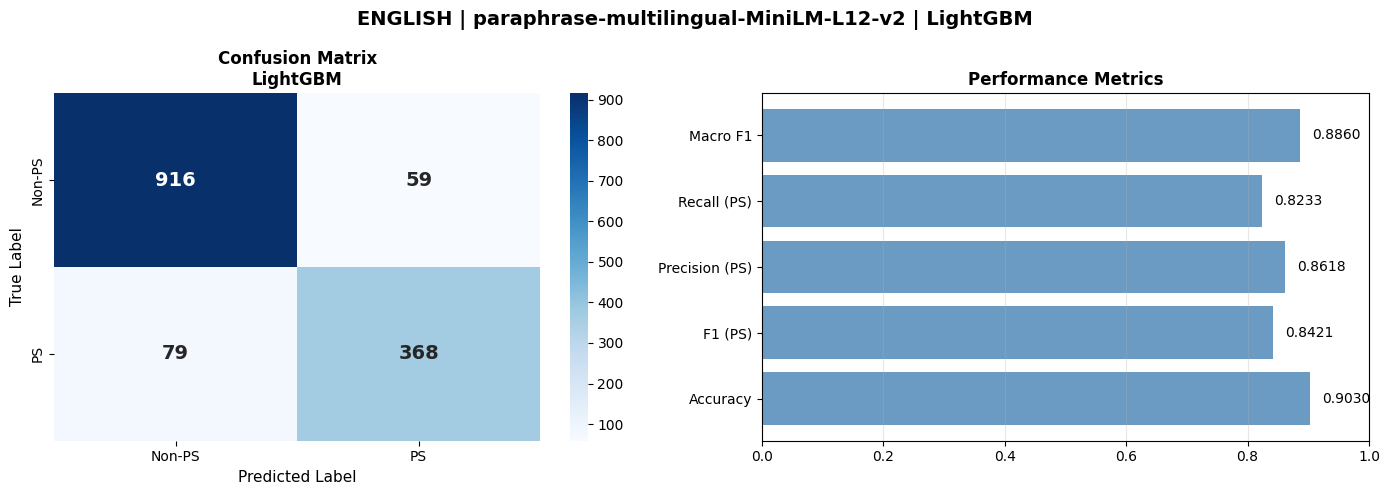


################################################################################
Loading: english_paraphrase-multilingual-mpnet-base-v2_embeddings.pkl
################################################################################
Dataset: ENGLISH
Model: paraphrase-multilingual-mpnet-base-v2
Training samples: 6621
Test samples: 1422
Embedding dim: 768

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: ENGLISH | paraphrase-multilingual-mpnet-base-v2 | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      802                173
Actual: PS                          106                341
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric            

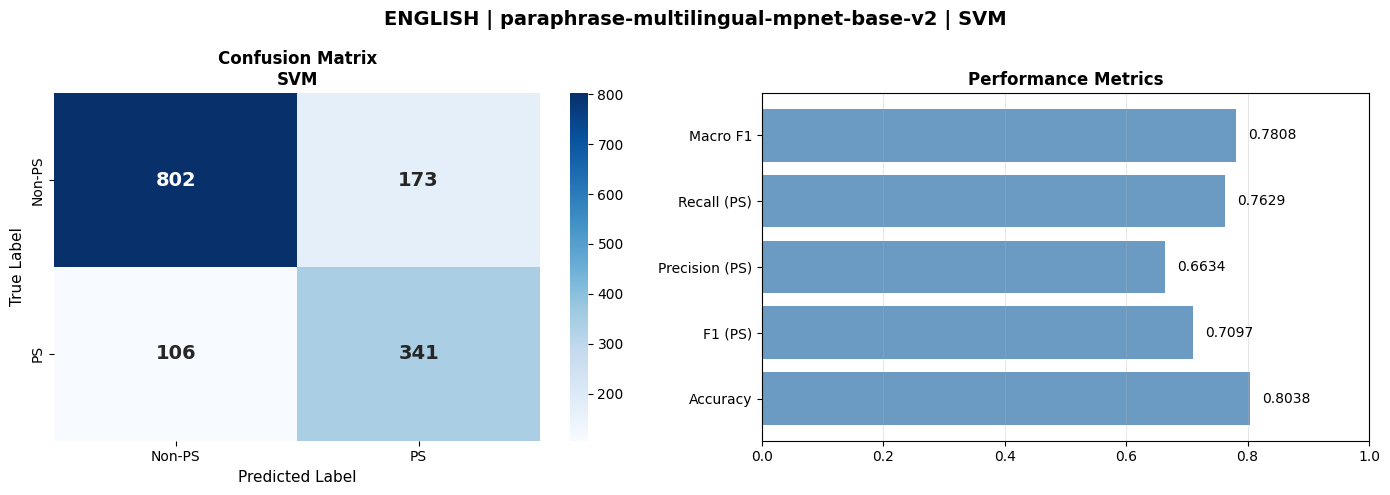


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: ENGLISH | paraphrase-multilingual-mpnet-base-v2 | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      924                 51
Actual: PS                           93                354
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9086          0.8741       0.8913
Recall                     0.9477          0.7919       0.8698
F1-Score                   0.9277          0.8310       0.8793
-----------------------------------------

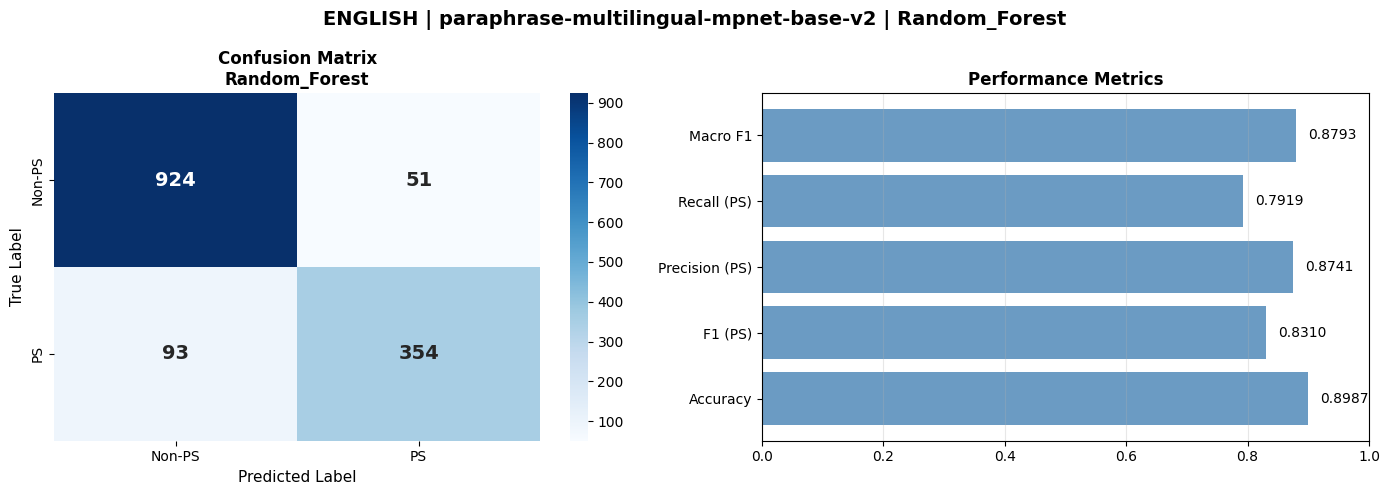


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: ENGLISH | paraphrase-multilingual-mpnet-base-v2 | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      924                 51
Actual: PS                           80                367
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9203          0.8780       0.8992
Recall                     0.9477          0.8210       0.8844
F1-Score                   0.9338          0.8486       0.8912
-----------------------------------------------------

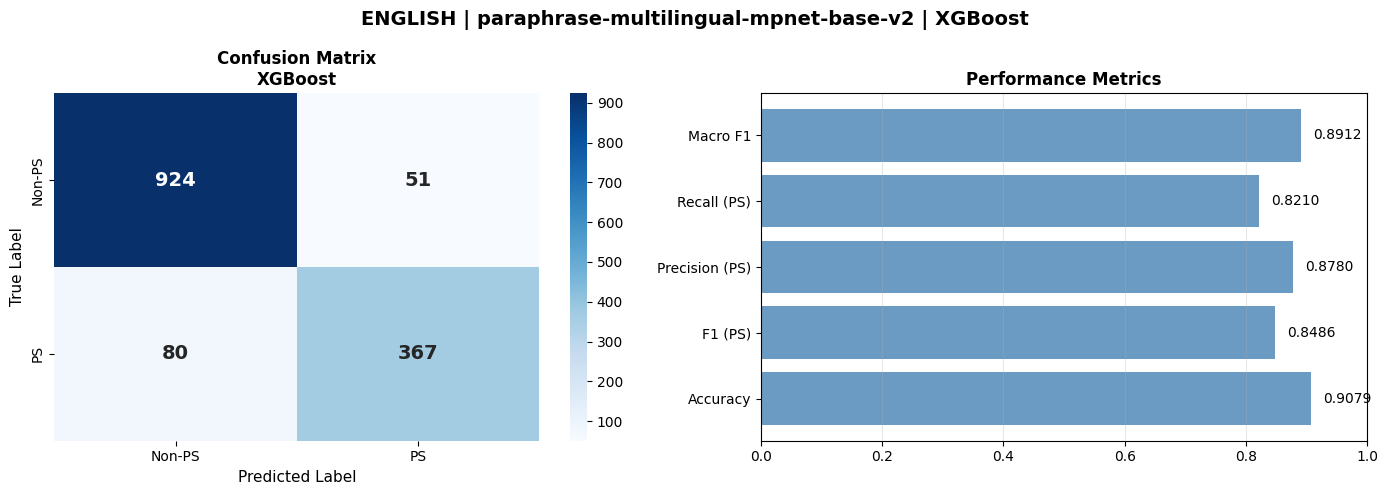


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: ENGLISH | paraphrase-multilingual-mpnet-base-v2 | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      921                 54
Actual: PS                           77                370
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9228          0.8726       0.8977
Recall                     0.9446          0.8277       0.8862
F1-Score                   0.9336          0.8496       0.8916
---------------------------------------------------

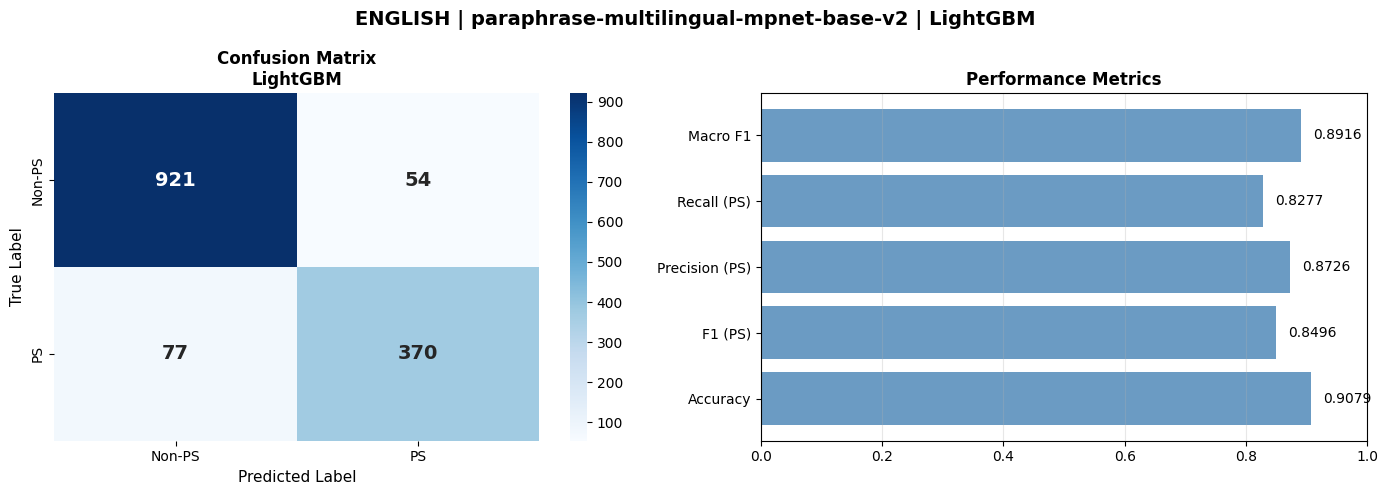


################################################################################
Loading: netherlands_paraphrase-multilingual-mpnet-base-v2_embeddings.pkl
################################################################################
Dataset: NETHERLANDS
Model: paraphrase-multilingual-mpnet-base-v2
Training samples: 3005
Test samples: 638
Embedding dim: 768

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: NETHERLANDS | paraphrase-multilingual-mpnet-base-v2 | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      382                 61
Actual: PS                           37                158
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric 

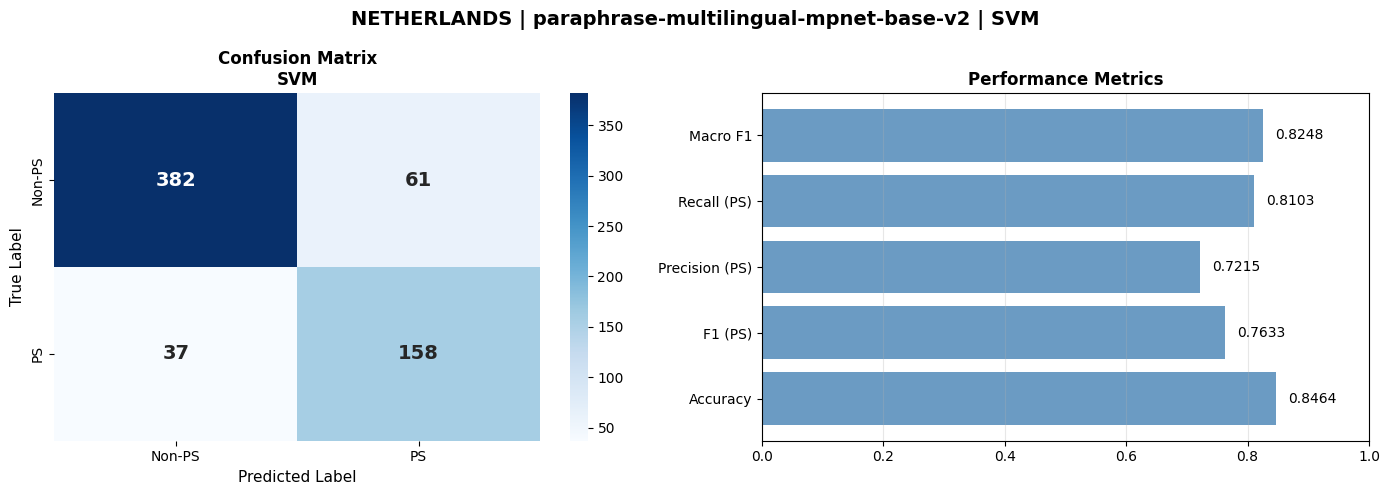


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: NETHERLANDS | paraphrase-multilingual-mpnet-base-v2 | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      404                 39
Actual: PS                           58                137
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.8745          0.7784       0.8264
Recall                     0.9120          0.7026       0.8073
F1-Score                   0.8928          0.7385       0.8157
-------------------------------------

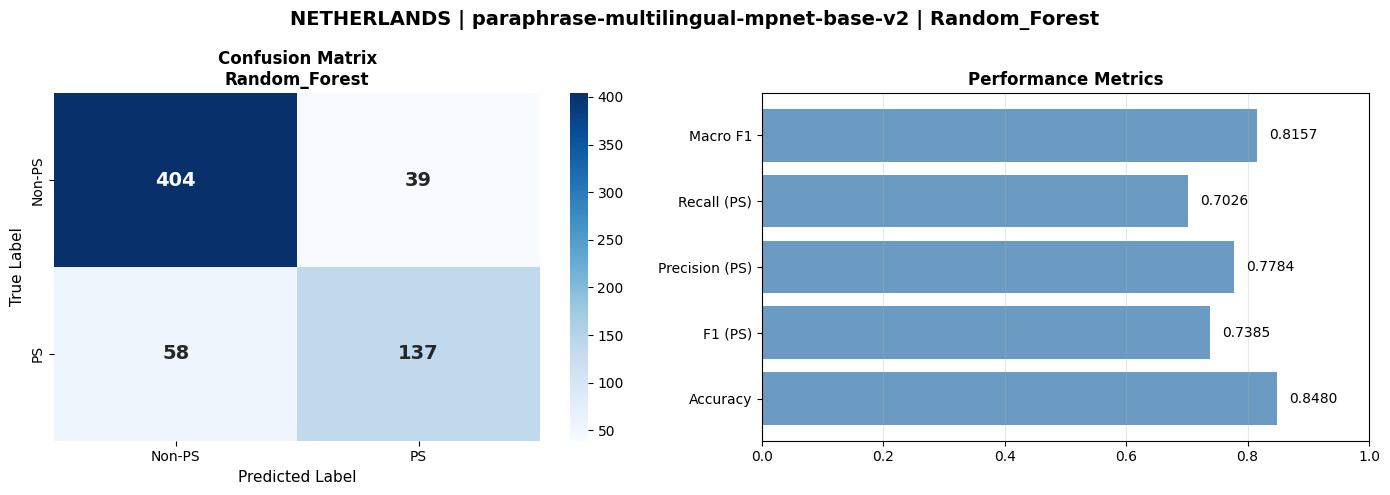


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: NETHERLANDS | paraphrase-multilingual-mpnet-base-v2 | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      390                 53
Actual: PS                           42                153
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9028          0.7427       0.8227
Recall                     0.8804          0.7846       0.8325
F1-Score                   0.8914          0.7631       0.8273
-------------------------------------------------

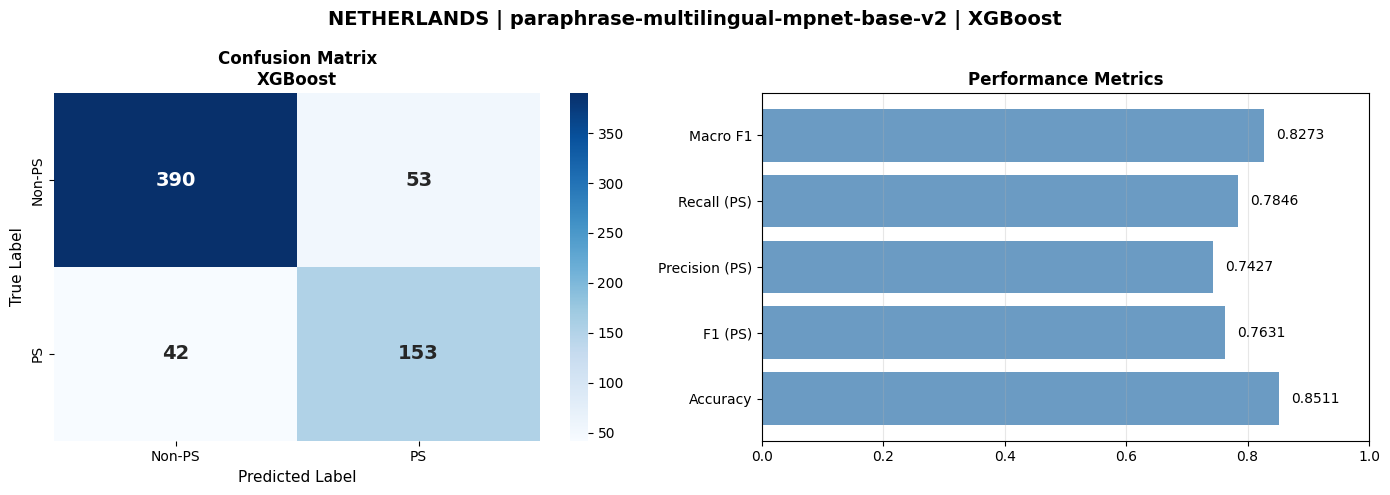


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: NETHERLANDS | paraphrase-multilingual-mpnet-base-v2 | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      394                 49
Actual: PS                           42                153
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9037          0.7574       0.8305
Recall                     0.8894          0.7846       0.8370
F1-Score                   0.8965          0.7708       0.8336
-----------------------------------------------

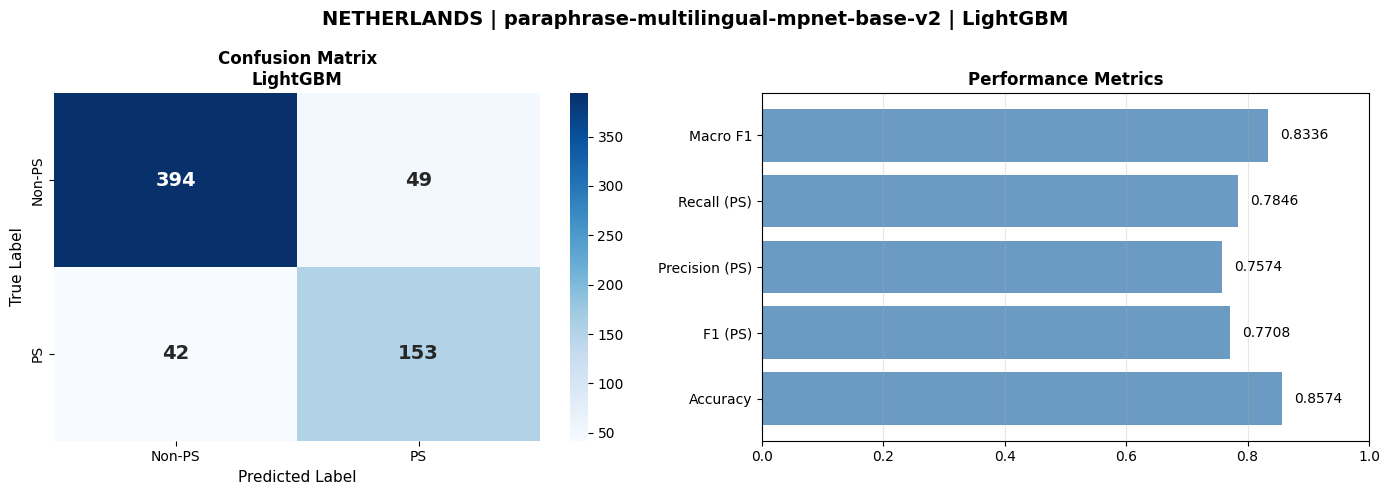


################################################################################
Loading: sweden_paraphrase-multilingual-mpnet-base-v2_embeddings.pkl
################################################################################
Dataset: SWEDEN
Model: paraphrase-multilingual-mpnet-base-v2
Training samples: 26161
Test samples: 4121
Embedding dim: 768

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: SWEDEN | paraphrase-multilingual-mpnet-base-v2 | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,234                613
Actual: PS                           77                197
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric              

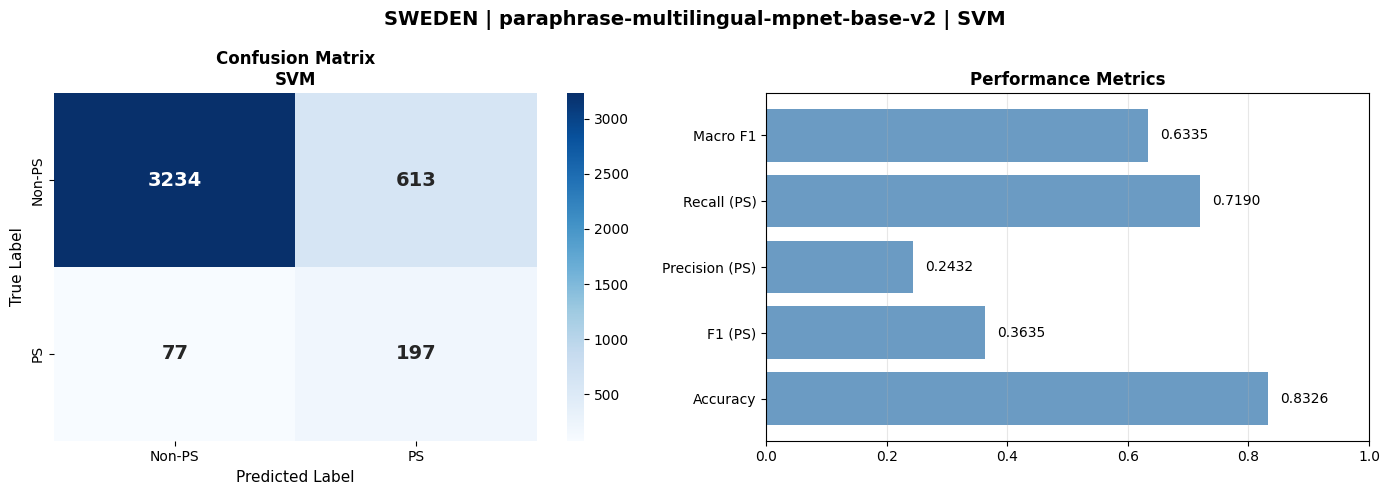


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: SWEDEN | paraphrase-multilingual-mpnet-base-v2 | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,740                107
Actual: PS                           88                186
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9770          0.6348       0.8059
Recall                     0.9722          0.6788       0.8255
F1-Score                   0.9746          0.6561       0.8153
------------------------------------------

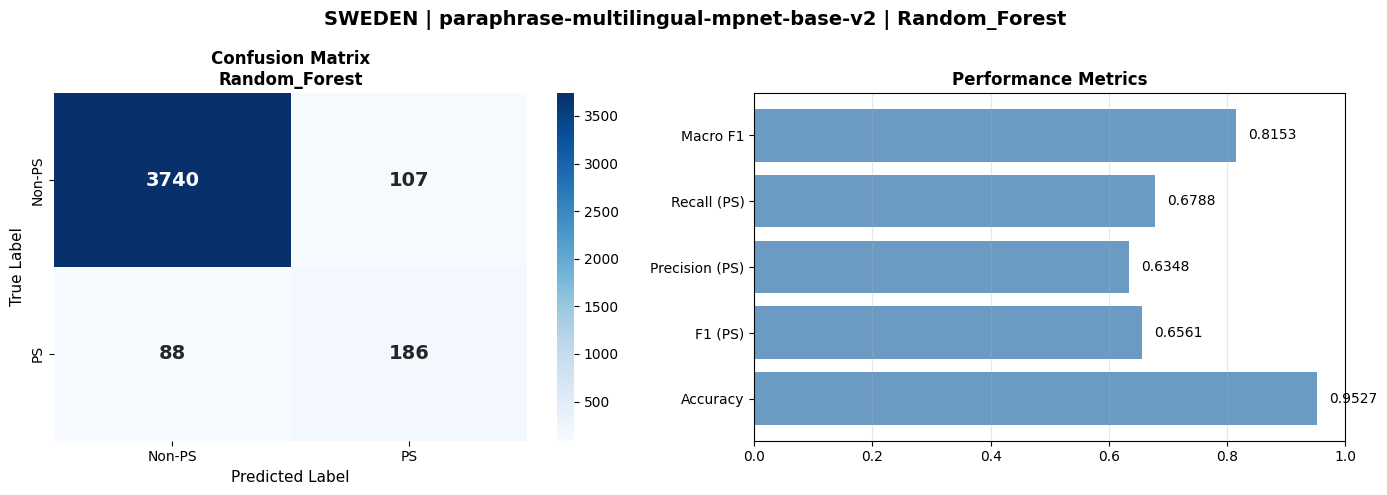


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: SWEDEN | paraphrase-multilingual-mpnet-base-v2 | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,772                 75
Actual: PS                           90                184
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9767          0.7104       0.8436
Recall                     0.9805          0.6715       0.8260
F1-Score                   0.9786          0.6904       0.8345
------------------------------------------------------

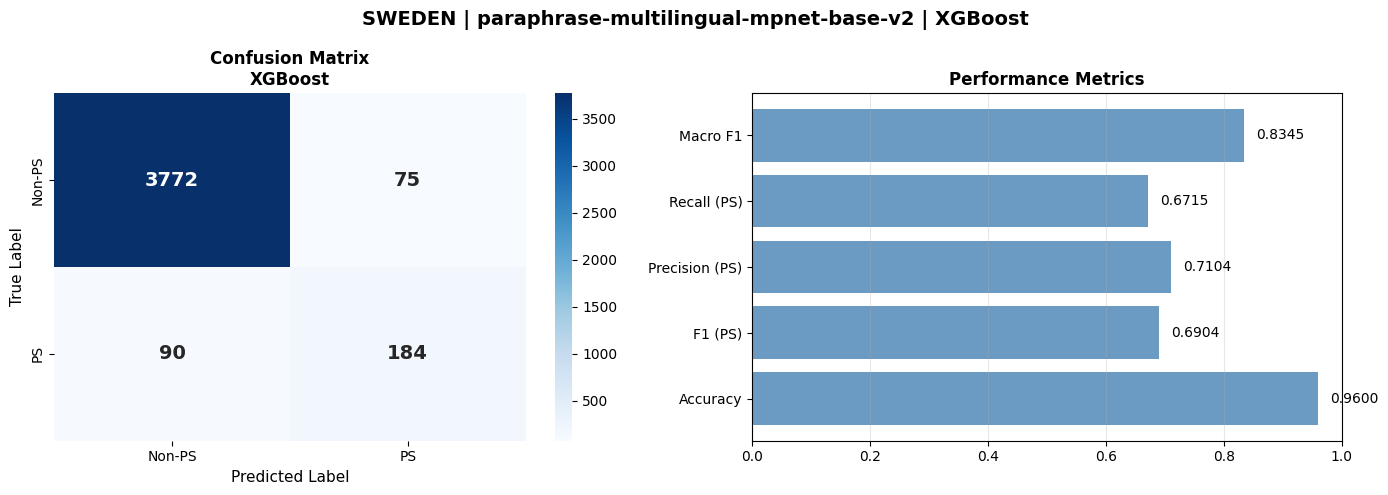


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: SWEDEN | paraphrase-multilingual-mpnet-base-v2 | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,754                 93
Actual: PS                           86                188
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9776          0.6690       0.8233
Recall                     0.9758          0.6861       0.8310
F1-Score                   0.9767          0.6775       0.8271
----------------------------------------------------

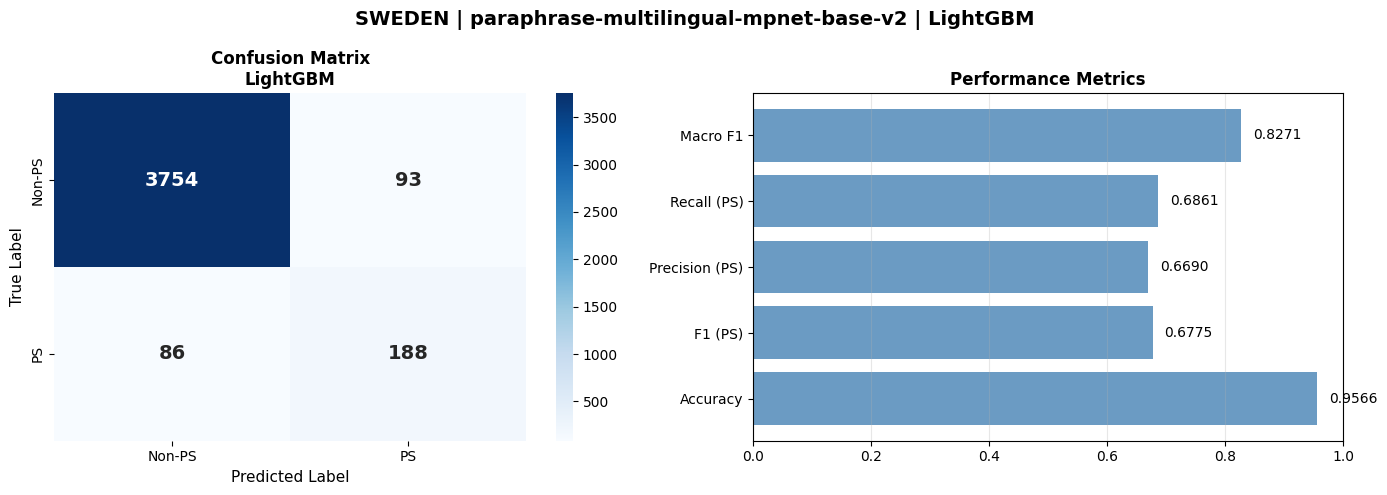


################################################################################
Loading: germany_paraphrase-multilingual-mpnet-base-v2_embeddings.pkl
################################################################################
Dataset: GERMANY
Model: paraphrase-multilingual-mpnet-base-v2
Training samples: 27356
Test samples: 4568
Embedding dim: 768

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: GERMANY | paraphrase-multilingual-mpnet-base-v2 | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,341                682
Actual: PS                          159                386
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric           

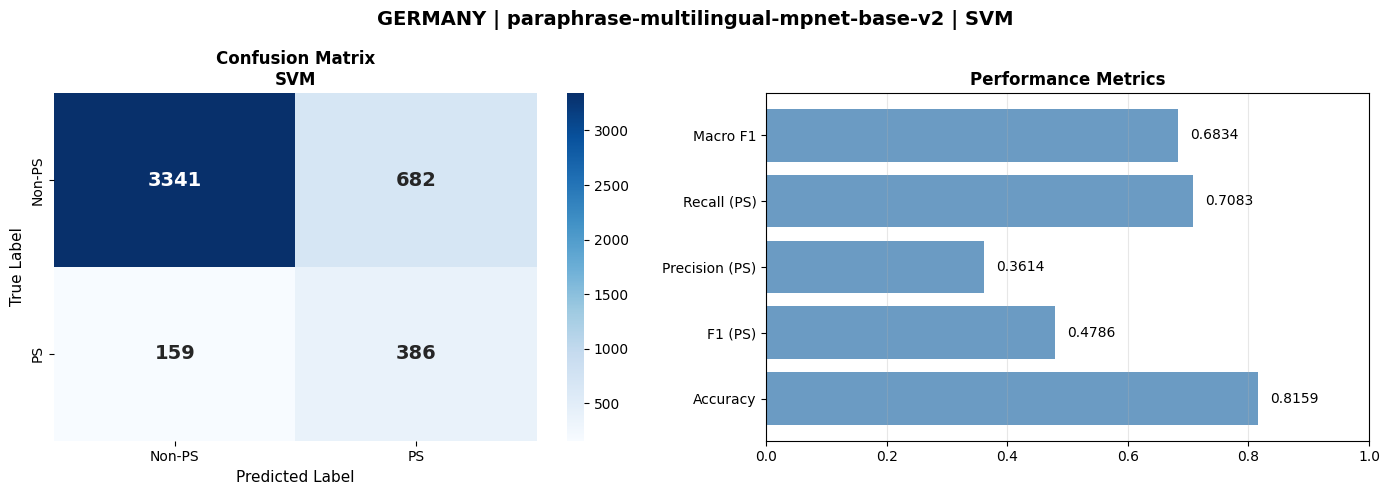


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: GERMANY | paraphrase-multilingual-mpnet-base-v2 | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,942                 81
Actual: PS                          133                412
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9674          0.8357       0.9015
Recall                     0.9799          0.7560       0.8679
F1-Score                   0.9736          0.7938       0.8837
-----------------------------------------

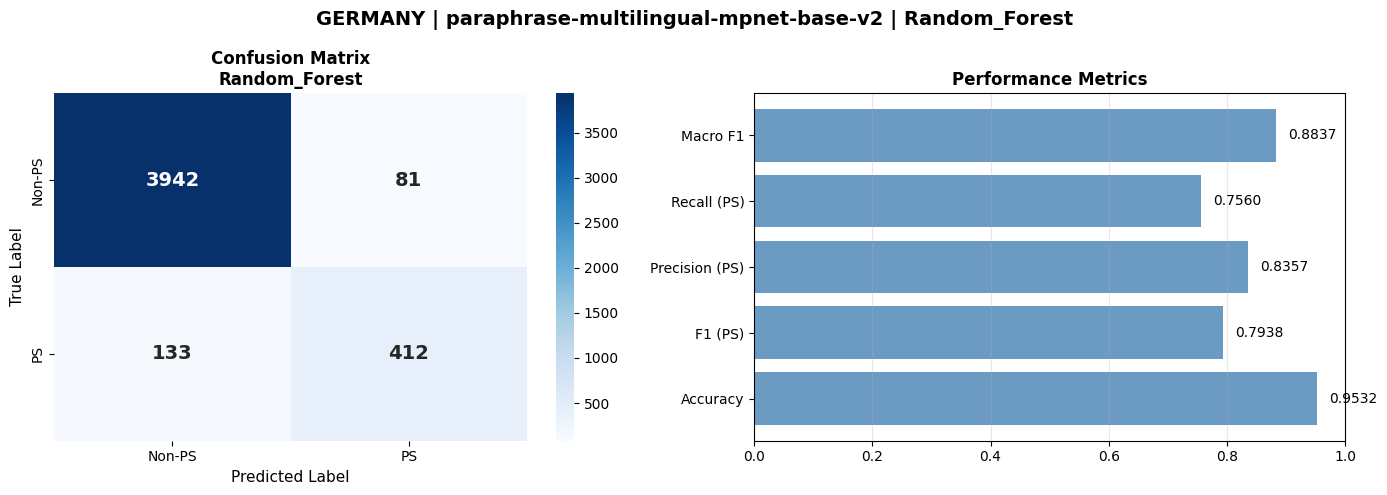


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: GERMANY | paraphrase-multilingual-mpnet-base-v2 | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,916                107
Actual: PS                          108                437
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9732          0.8033       0.8882
Recall                     0.9734          0.8018       0.8876
F1-Score                   0.9733          0.8026       0.8879
-----------------------------------------------------

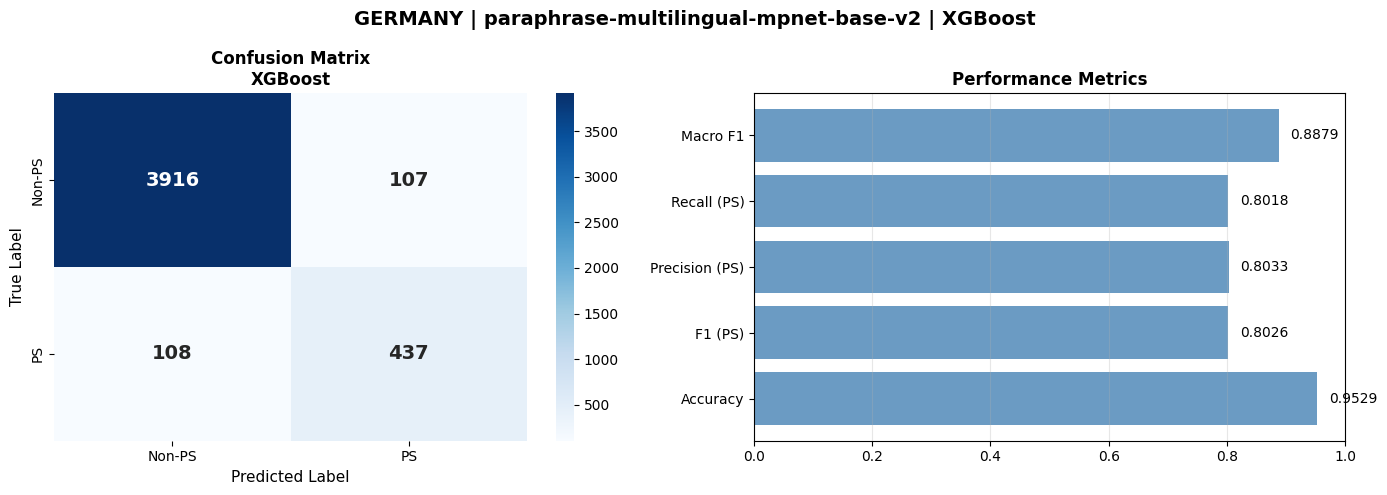


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: GERMANY | paraphrase-multilingual-mpnet-base-v2 | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                    3,902                121
Actual: PS                          110                435
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9726          0.7824       0.8775
Recall                     0.9699          0.7982       0.8840
F1-Score                   0.9713          0.7902       0.8807
---------------------------------------------------

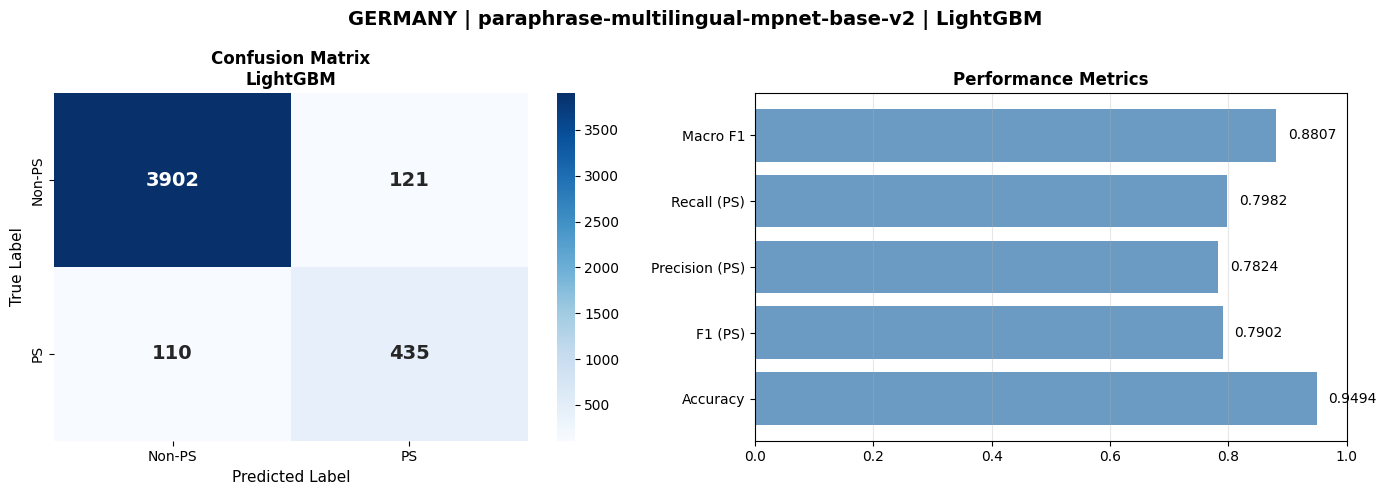


################################################################################
Loading: uk_paraphrase-multilingual-mpnet-base-v2_embeddings.pkl
################################################################################
Dataset: UK
Model: paraphrase-multilingual-mpnet-base-v2
Training samples: 6582
Test samples: 1407
Embedding dim: 768

────────────────────────────────────────────────────────────
Training SVM...

RESULTS: UK | paraphrase-multilingual-mpnet-base-v2 | SVM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      780                189
Actual: PS                           88                350
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS

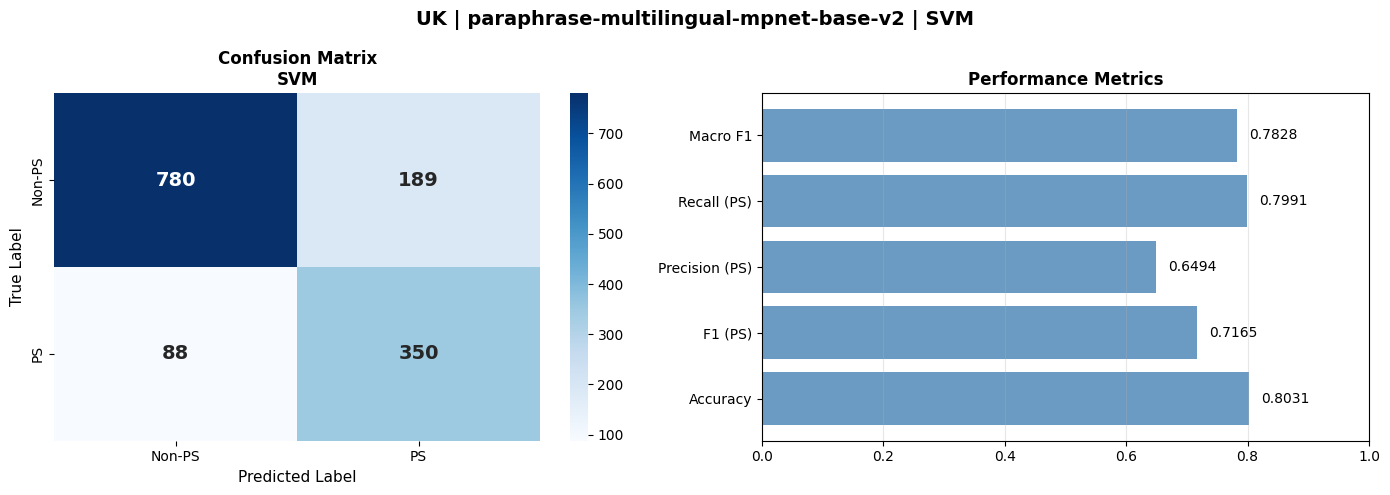


────────────────────────────────────────────────────────────
Training Random_Forest...

RESULTS: UK | paraphrase-multilingual-mpnet-base-v2 | Random_Forest

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      910                 59
Actual: PS                           84                354
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9155          0.8571       0.8863
Recall                     0.9391          0.8082       0.8737
F1-Score                   0.9272          0.8320       0.8796
----------------------------------------------

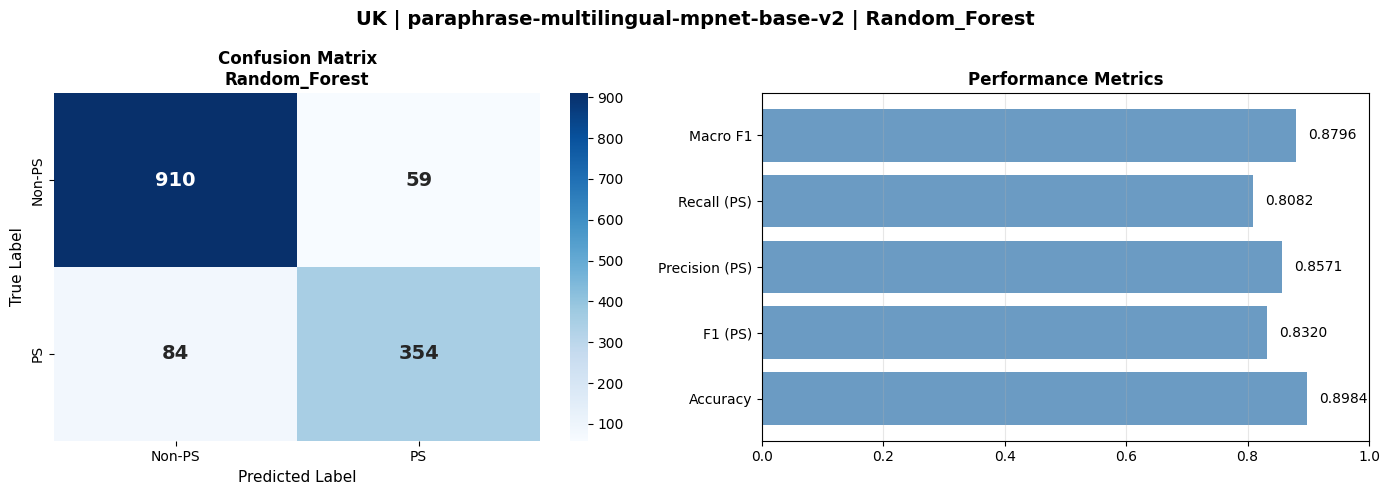


────────────────────────────────────────────────────────────
Training XGBoost...

RESULTS: UK | paraphrase-multilingual-mpnet-base-v2 | XGBoost

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      905                 64
Actual: PS                           76                362
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9225          0.8498       0.8861
Recall                     0.9340          0.8265       0.8802
F1-Score                   0.9282          0.8380       0.8831
----------------------------------------------------------

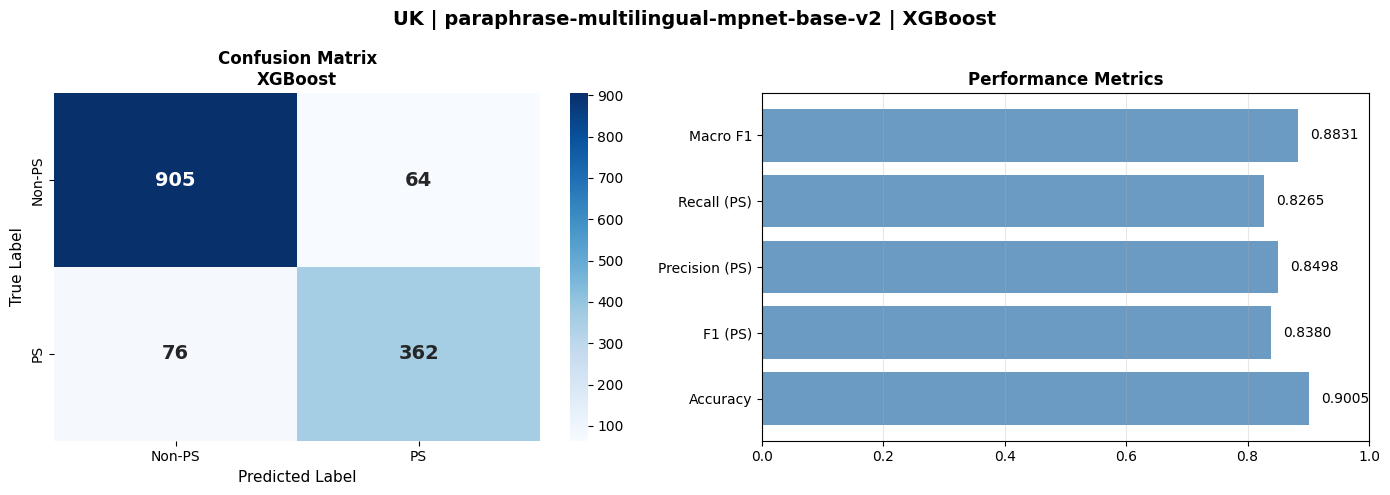


────────────────────────────────────────────────────────────
Training LightGBM...

RESULTS: UK | paraphrase-multilingual-mpnet-base-v2 | LightGBM

                      CONFUSION MATRIX                      
------------------------------------------------------------
                           Pred: Non-PS           Pred: PS
Actual: Non-PS                      909                 60
Actual: PS                           74                364
------------------------------------------------------------

                    PERFORMANCE METRICS                     
------------------------------------------------------------
Metric                     Non-PS  Process Safety    Macro Avg
------------------------------------------------------------
Precision                  0.9247          0.8585       0.8916
Recall                     0.9381          0.8311       0.8846
F1-Score                   0.9314          0.8445       0.8880
--------------------------------------------------------

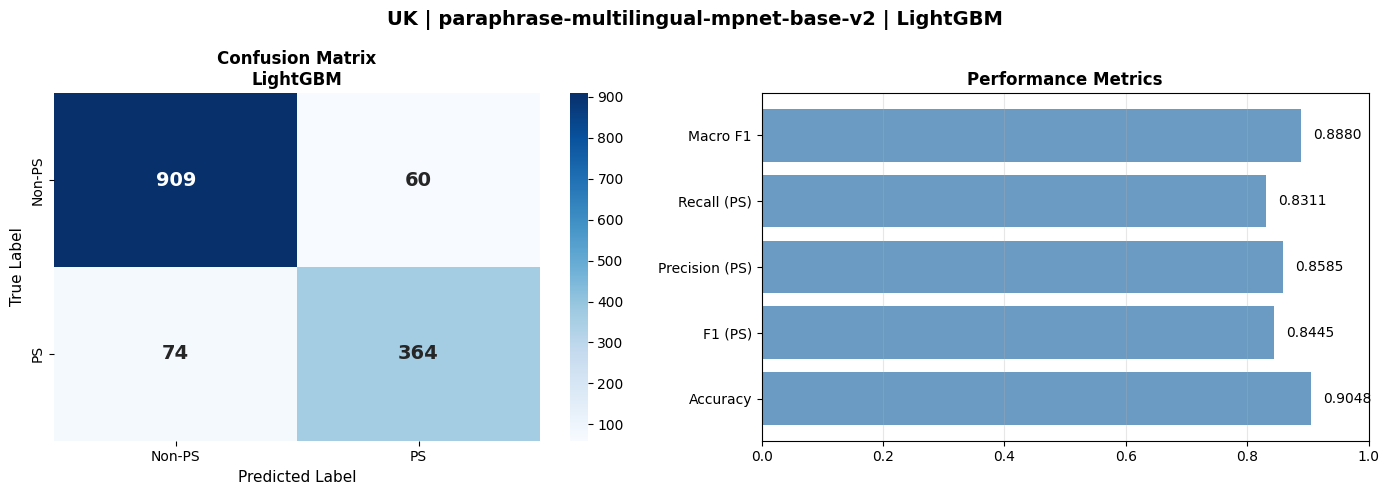


 Results saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/iteration_4_comprehensive_results.csv


####################################################################################################
                                ITERATION 4 - COMPREHENSIVE SUMMARY                                 
####################################################################################################

CONFUSION MATRIX SUMMARY BY MODEL-DATASET-CLASSIFIER
Dataset      Model                               Classifier            TN       FP       FN       TP      Acc    F1_PS
----------------------------------------------------------------------------------------------------
netherlands  efederici/e5-base-multilingual-40   SVM                  394       49       40      155   0.8605   0.7769
netherlands  efederici/e5-base-multilingual-40   Random_Forest        410       33       57      138   0.8589   0.7541
netherlands  efederici/e5-base-multilingual-4

In [4]:
# ============================================================
# RESULTS OF ITERATION 4
# ============================================================

import pandas as pd
import numpy as np
import os
import pickle
import glob
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, 
    f1_score, precision_recall_fscore_support,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import time

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False


print(f"Using paths from Cell 2:")
print(f"  EMBEDDINGS_BASE_DIR: {EMBEDDINGS_BASE_DIR}")
print(f"  RESULTS_DIR: {RESULTS_DIR}")
os.makedirs(RESULTS_DIR, exist_ok=True)

def calculate_detailed_metrics(y_test, y_pred):
    """Calculate comprehensive evaluation metrics"""
    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
    total = TN + FP + FN + TP
    
    accuracy = (TP + TN) / total
    precision_ps = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall_ps = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_ps = 2 * (precision_ps * recall_ps) / (precision_ps + recall_ps) if (precision_ps + recall_ps) > 0 else 0
    
    precision_nps = TN / (TN + FN) if (TN + FN) > 0 else 0
    recall_nps = TN / (TN + FP) if (TN + FP) > 0 else 0
    f1_nps = 2 * (precision_nps * recall_nps) / (precision_nps + recall_nps) if (precision_nps + recall_nps) > 0 else 0
    
    macro_f1 = (f1_ps + f1_nps) / 2
    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
    fnr = FN / (FN + TP) if (FN + TP) > 0 else 0
    
    return {
        'confusion_matrix': cm,
        'TN': TN, 'FP': FP, 'FN': FN, 'TP': TP,
        'total': total, 'accuracy': accuracy,
        'precision_ps': precision_ps, 'recall_ps': recall_ps, 'f1_ps': f1_ps,
        'precision_nps': precision_nps, 'recall_nps': recall_nps, 'f1_nps': f1_nps,
        'macro_f1': macro_f1, 'fpr': fpr, 'fnr': fnr
    }

def print_detailed_results(dataset_name, model_key, classifier_name, metrics, cm):
    """Print formatted evaluation results with confusion matrix"""
    print(f"\n{'='*80}")
    print(f"RESULTS: {dataset_name.upper()} | {model_key} | {classifier_name}")
    print(f"{'='*80}")
    
    # Confusion Matrix Text
    print(f"\n{'CONFUSION MATRIX':^60}")
    print(f"{'-'*60}")
    print(f"{'':20} {'Pred: Non-PS':>18} {'Pred: PS':>18}")
    print(f"{'Actual: Non-PS':<20} {metrics['TN']:>18,} {metrics['FP']:>18,}")
    print(f"{'Actual: PS':<20} {metrics['FN']:>18,} {metrics['TP']:>18,}")
    print(f"{'-'*60}")
    
    # Performance Metrics
    print(f"\n{'PERFORMANCE METRICS':^60}")
    print(f"{'-'*60}")
    print(f"{'Metric':<20} {'Non-PS':>12} {'Process Safety':>15} {'Macro Avg':>12}")
    print(f"{'-'*60}")
    print(f"{'Precision':<20} {metrics['precision_nps']:>12.4f} {metrics['precision_ps']:>15.4f} {(metrics['precision_nps']+metrics['precision_ps'])/2:>12.4f}")
    print(f"{'Recall':<20} {metrics['recall_nps']:>12.4f} {metrics['recall_ps']:>15.4f} {(metrics['recall_nps']+metrics['recall_ps'])/2:>12.4f}")
    print(f"{'F1-Score':<20} {metrics['f1_nps']:>12.4f} {metrics['f1_ps']:>15.4f} {metrics['macro_f1']:>12.4f}")
    print(f"{'-'*60}")
    print(f"{'Accuracy':<20} {'':<27} {metrics['accuracy']:>12.4f}")
    print(f"{'FPR':<20} {'':<27} {metrics['fpr']:>12.4f}")
    print(f"{'FNR':<20} {'':<27} {metrics['fnr']:>12.4f}")
    print(f"{'='*60}\n")

def generate_results_from_embeddings(pkl_file, show_plots=True, save_plots=True):
    """Load embeddings and generate results with confusion matrices"""
    
    print(f"\n{'#'*80}")
    print(f"Loading: {os.path.basename(pkl_file)}")
    print(f"{'#'*80}")
    
    # Load embeddings
    with open(pkl_file, 'rb') as f:
        embeddings_data = pickle.load(f)
    
    X_train = embeddings_data['X_train_subset']
    y_train = embeddings_data['y_train_subset']
    X_test = embeddings_data['X_test_scaled']
    y_test = embeddings_data['y_test']
    metadata = embeddings_data['metadata']
    
    dataset_name = metadata['dataset']
    model_key = metadata['model_key']
    
    print(f"Dataset: {dataset_name.upper()}")
    print(f"Model: {model_key}")
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Test samples: {X_test.shape[0]}")
    print(f"Embedding dim: {X_train.shape[1]}")
    
    all_results = []
    
    # Define classifiers
    classifiers = {
        'SVM': LinearSVC(class_weight='balanced', max_iter=10000, dual=False, random_state=42),
        'Random_Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', 
                                                 random_state=42, n_jobs=-1, max_depth=20),
    }
    
    if XGBOOST_AVAILABLE:
        pos_weight = sum(y_train == 0) / sum(y_train == 1) if sum(y_train == 1) > 0 else 1
        classifiers['XGBoost'] = XGBClassifier(n_estimators=200, scale_pos_weight=pos_weight,
                                                random_state=42, n_jobs=-1, max_depth=6, learning_rate=0.1)
    
    if LIGHTGBM_AVAILABLE:
        classifiers['LightGBM'] = LGBMClassifier(n_estimators=200, class_weight='balanced',
                                                  random_state=42, n_jobs=-1, max_depth=6, 
                                                  learning_rate=0.1, verbose=-1)
    
    # Train and evaluate each classifier
    for clf_name, clf in classifiers.items():
        print(f"\n{'─'*60}")
        print(f"Training {clf_name}...")
        
        start_time = time.time()
        clf.fit(X_train, y_train)
        training_time = time.time() - start_time
        
        y_pred = clf.predict(X_test)
        
        # Calculate metrics
        metrics = calculate_detailed_metrics(y_test, y_pred)
        cm = metrics['confusion_matrix']
        
        # Print detailed results
        print_detailed_results(dataset_name, model_key, clf_name, metrics, cm)
        
        # Print sklearn classification report
        print("Classification Report:")
        print(classification_report(y_test, y_pred, 
                                   target_names=['Non-Process Safety', 'Process Safety'],
                                   digits=4))
        
        # Create confusion matrix visualization
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Confusion Matrix Heatmap
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Non-PS', 'PS'],
                   yticklabels=['Non-PS', 'PS'],
                   ax=axes[0],
                   annot_kws={'size': 14, 'fontweight': 'bold'})
        axes[0].set_title(f'Confusion Matrix\n{clf_name}', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('True Label', fontsize=11)
        axes[0].set_xlabel('Predicted Label', fontsize=11)
        
        # Metrics bar chart
        metrics_data = {
            'Accuracy': metrics['accuracy'],
            'F1 (PS)': metrics['f1_ps'],
            'Precision (PS)': metrics['precision_ps'],
            'Recall (PS)': metrics['recall_ps'],
            'Macro F1': metrics['macro_f1'],
        }
        bars = axes[1].barh(list(metrics_data.keys()), list(metrics_data.values()), 
                           color='steelblue', alpha=0.8)
        axes[1].set_xlim([0, 1])
        axes[1].set_title('Performance Metrics', fontsize=12, fontweight='bold')
        axes[1].grid(axis='x', alpha=0.3)
        for i, (k, v) in enumerate(metrics_data.items()):
            axes[1].text(v + 0.02, i, f'{v:.4f}', va='center', fontsize=10)
        
        plt.suptitle(f'{dataset_name.upper()} | {model_key} | {clf_name}', 
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        
        if save_plots:
            plot_filename = f'cm_{dataset_name}_{model_key.replace("/", "_")}_{clf_name}.png'
            plot_path = os.path.join(RESULTS_DIR, plot_filename)
            plt.savefig(plot_path, dpi=300, bbox_inches='tight')
            print(f" Plot saved: {plot_path}")
        
        if show_plots:
            plt.show()
        plt.close()
        
        # Get probability scores if available
        try:
            if hasattr(clf, 'predict_proba'):
                y_proba = clf.predict_proba(X_test)[:, 1]
                roc_auc = roc_auc_score(y_test, y_proba)
            elif hasattr(clf, 'decision_function'):
                y_proba = clf.decision_function(X_test)
                roc_auc = roc_auc_score(y_test, y_proba)
            else:
                roc_auc = None
        except:
            roc_auc = None
        
        # Store results
        all_results.append({
            'dataset': dataset_name,
            'model': model_key,
            'classifier': clf_name,
            'accuracy': metrics['accuracy'],
            'f1_ps': metrics['f1_ps'],
            'f1_nps': metrics['f1_nps'],
            'macro_f1': metrics['macro_f1'],
            'precision_ps': metrics['precision_ps'],
            'recall_ps': metrics['recall_ps'],
            'precision_nps': metrics['precision_nps'],
            'recall_nps': metrics['recall_nps'],
            'TN': metrics['TN'],
            'FP': metrics['FP'],
            'FN': metrics['FN'],
            'TP': metrics['TP'],
            'fpr': metrics['fpr'],
            'fnr': metrics['fnr'],
            'roc_auc': roc_auc,
            'training_time': training_time,
        })
    
    return all_results

def generate_all_results(show_plots=True, save_plots=True):
    """Generate results for all saved embeddings"""
    
    # Find all embedding files
    pkl_files = glob.glob(os.path.join(EMBEDDINGS_BASE_DIR, '**', '*.pkl'), recursive=True)
    
    print(f"\n{'#'*80}")
    print(f"GENERATING RESULTS FROM SAVED EMBEDDINGS")
    print(f"{'#'*80}")
    print(f"Found {len(pkl_files)} embedding files")
    
    if len(pkl_files) == 0:
        print(" No embedding files found! Run the main pipeline first.")
        return None
    
    all_results = []
    
    for pkl_file in pkl_files:
        try:
            results = generate_results_from_embeddings(pkl_file, show_plots, save_plots)
            all_results.extend(results)
        except Exception as e:
            print(f" Error processing {pkl_file}: {str(e)}")
            import traceback
            traceback.print_exc()
            continue
    
    if all_results:
        # Create summary DataFrame
        results_df = pd.DataFrame(all_results)
        
        # Save to CSV
        summary_file = os.path.join(RESULTS_DIR, 'iteration_4_comprehensive_results.csv')
        results_df.to_csv(summary_file, index=False)
        print(f"\n Results saved to: {summary_file}")
        
        # Print summary tables
        print(f"\n\n{'#'*100}")
        print(f"{'ITERATION 4 - COMPREHENSIVE SUMMARY':^100}")
        print(f"{'#'*100}\n")
        
        # Confusion Matrix Summary
        print(f"{'='*100}")
        print(f"CONFUSION MATRIX SUMMARY BY MODEL-DATASET-CLASSIFIER")
        print(f"{'='*100}")
        print(f"{'Dataset':<12} {'Model':<35} {'Classifier':<15} {'TN':>8} {'FP':>8} {'FN':>8} {'TP':>8} {'Acc':>8} {'F1_PS':>8}")
        print(f"{'-'*100}")
        for _, row in results_df.iterrows():
            print(f"{row['dataset']:<12} {row['model'][:33]:<35} {row['classifier']:<15} {int(row['TN']):>8} {int(row['FP']):>8} {int(row['FN']):>8} {int(row['TP']):>8} {row['accuracy']:>8.4f} {row['f1_ps']:>8.4f}")
        print(f"{'='*100}\n")
        
        # Best performers
        print(f"\n{'='*80}")
        print(f"TOP 5 BEST PERFORMERS (by Process Safety F1)")
        print(f"{'='*80}")
        top5 = results_df.nlargest(5, 'f1_ps')
        for i, (_, row) in enumerate(top5.iterrows(), 1):
            print(f"\n{i}. {row['dataset'].upper()} | {row['model']} | {row['classifier']}")
            print(f"   F1 (PS): {row['f1_ps']:.4f} | Precision: {row['precision_ps']:.4f} | Recall: {row['recall_ps']:.4f}")
            print(f"   Accuracy: {row['accuracy']:.4f} | FNR: {row['fnr']:.4f}")
        
        # By classifier
        print(f"\n\n{'='*80}")
        print(f"AVERAGE PERFORMANCE BY CLASSIFIER")
        print(f"{'='*80}")
        clf_stats = results_df.groupby('classifier')[['accuracy', 'f1_ps', 'precision_ps', 'recall_ps', 'fnr']].mean()
        print(clf_stats.round(4).to_string())
        
        # By model
        print(f"\n\n{'='*80}")
        print(f"AVERAGE PERFORMANCE BY MODEL")
        print(f"{'='*80}")
        model_stats = results_df.groupby('model')[['accuracy', 'f1_ps', 'precision_ps', 'recall_ps', 'fnr']].mean()
        print(model_stats.round(4).to_string())
        
        return results_df
    
    return None

# ============================================================
# RUN THE RESULTS GENERATOR
# ============================================================

# Generate results for all saved embeddings
results_df = generate_all_results(show_plots=True, save_plots=True)

if results_df is not None:
    print(f"\n Successfully generated results for {len(results_df)} model-dataset-classifier combinations")
else:
    print("\n No results generated - check that embeddings exist")

In [ ]:
# =============================================================================
# ITERATION 4 SUMMARY — Save iteration_4_summary.json
# =============================================================================
# Consistent with Iteration 0's summary output format.

import json as _json
import pandas as pd
import os

_results_csv = os.path.join(RESULTS_DIR, 'iteration_4_all_results.csv')

if os.path.exists(_results_csv):
    _results_df = pd.read_csv(_results_csv)
    _best = _results_df.loc[_results_df['f1_ps'].idxmax()]
    _RQ1_TARGET = 0.85

    _summary = {
        'iteration': 4,
        'model': '10+ advanced embedding models + 7 classifiers (GridSearchCV, ensemble) + SMOTE',
        'best_dataset':  str(_best['dataset']),
        'best_model':    str(_best['model']),
        'best_classifier': str(_best['classifier']),
        'datasets': {},
        'gap_analysis': {}
    }

    for _, row in _results_df.iterrows():
        key = f"{row['dataset']}__{row['model']}__{row['classifier']}"
        _summary['datasets'][key] = {
            'total_samples': int(row.get('total_samples', 0)),
            'results': {
                'accuracy':     round(float(row['accuracy']), 4),
                'f1_ps':        round(float(row['f1_ps']), 4),
                'precision_ps': round(float(row['precision_ps']), 4),
                'recall_ps':    round(float(row['recall_ps']), 4),
            },
            'confusion_matrix': {
                'tn': int(row['TN']), 'fp': int(row['FP']),
                'fn': int(row['FN']), 'tp': int(row['TP']),
            }
        }
        _summary['gap_analysis'][key] = {
            'current_f1_ps': round(float(row['f1_ps']), 4),
            'rq1_target': _RQ1_TARGET,
            'gap': round(float(_RQ1_TARGET - row['f1_ps']), 4)
        }

    _out_path = os.path.join(RESULTS_DIR, 'iteration_4_summary.json')
    with open(_out_path, 'w', encoding='utf-8') as _f:
        _json.dump(_summary, _f, indent=2, ensure_ascii=False)
    print(f"[OK] Saved: {_out_path}")
    print(f"Best: {_best['dataset']} | {_best['model']} | {_best['classifier']} | F1_PS={_best['f1_ps']:.4f}")
else:
    print(f"[INFO] Results CSV not found yet: {_results_csv}")
    print("       Run the pipeline first, then re-run this cell.")